In [ ]:
!git clone https://github.com/sinhasagar507/NLP_Project_d1_reasoning.git

Cloning into 'NLP_Project_d1_reasoning'...
remote: Enumerating objects: 313, done.
remote: Counting objects: 100% (313/313), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 313 (delta 153), reused 310 (delta 150), pack-reused 0 (from 0)
Receiving objects: 100% (313/313), 11.98 MiB | 8.57 MiB/s, done.
Resolving deltas: 100% (153/153), done.


In [ ]:
# 2. Install core libraries (only if not already installed)
!pip install -q "transformers>=4.40.0" accelerate bitsandbytes peft datasets sentencepiece einops

In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import login
login()  # this will prompt you to paste your HF token

In [ ]:
file_path = '/content/NLP_Project_d1_reasoning/objective3/README_attention_maps.md'
content_to_add = """
# Objective 3 — Attention Map Study (LLaDA vs LLaMA)

This sub-folder contains code to study **attention dynamics** in diffusion-based LLaDA
vs autoregressive LLaMA.

We build directly on the mechanistic probing probes already implemented for diffusion
trajectories (entropy, flips, FLI, stability, flip heatmaps). Those probes operate on
token trajectories x^(s); here we add probes that operate on **attention maps** A^(s).

## Goals

1. Inspect the model architectures for:
   - LLaDA-8B-Instruct (bidirectional diffusion)
   - LLaMA-3(.1)-8B-Instruct (causal autoregressive)

2. Define lightweight attention probes:
   - Bidirectionality Index (BI): how much attention flows to future tokens.
   - Attention entropy: how focused vs diffuse attention is over positions.
   - Attention Localization Index (ALI): how spatially localized attention mass is over
     the generated answer region (FLI-analogue).

3. Add a `generate_with_attention_probes` sampler that:
   - Reuses the existing diffusion sampler logic (`eval/generate.py`).
   - At each diffusion step, calls the model with `output_attentions=True`.
   - Computes BI / entropy / ALI on one or more layers.
   - Logs trajectories over diffusion steps: [S, B] tensors.

Later steps (not implemented yet here) will:
- Add dataset-level evaluation scripts for LLaDA and LLaMA.
- Plot trajectories, heatmaps, and compare BASE vs SFT models.
"""

import os

# Append content again
with open(file_path, 'a') as f:
    # Add a newline before if the file is not empty and doesn't end with one
    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
         with open(file_path, 'r') as r:
             if not r.read().endswith('\n'):
                 f.write('\n')
    f.write(content_to_add)

print(f"Appended content to {file_path} again.")
print("-" * 20)
with open(file_path, 'r') as f:
    print(f.read())

Appended content to /content/NLP_Project_d1_reasoning/objective3/README_attention_maps.md again.
--------------------

# Objective 3 — Attention Map Study (LLaDA vs LLaMA)

This sub-folder contains code to study **attention dynamics** in diffusion-based LLaDA
vs autoregressive LLaMA.

We build directly on the mechanistic probing probes already implemented for diffusion
trajectories (entropy, flips, FLI, stability, flip heatmaps). Those probes operate on
token trajectories x^(s); here we add probes that operate on **attention maps** A^(s).

## Goals

1. Inspect the model architectures for:
   - LLaDA-8B-Instruct (bidirectional diffusion)
   - LLaMA-3(.1)-8B-Instruct (causal autoregressive)

2. Define lightweight attention probes:
   - Bidirectionality Index (BI): how much attention flows to future tokens.
   - Attention entropy: how focused vs diffuse attention is over positions.
   - Attention Localization Index (ALI): how spatially localized attention mass is over
     the generated a

## Sanity Check attention outputs on both models

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# LLaDA
tok_llada = AutoTokenizer.from_pretrained("GSAI-ML/LLaDA-8B-Instruct", trust_remote_code=True)
mdl_llada = AutoModelForCausalLM.from_pretrained(
    "GSAI-ML/LLaDA-8B-Instruct",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
).to(device)
mdl_llada.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

LLaDAModelLM(
  (model): LLaDAModel(
    (transformer): ModuleDict(
      (wte): Embedding(126464, 4096)
      (emb_drop): Dropout(p=0.0, inplace=False)
      (ln_f): RMSLayerNorm()
      (blocks): ModuleList(
        (0-31): 32 x LLaDALlamaBlock(
          (dropout): Dropout(p=0.0, inplace=False)
          (act): SiLU()
          (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
          (rotary_emb): RotaryEmbedding()
          (attn_norm): RMSLayerNorm()
          (ff_norm): RMSLayerNorm()
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
        )
      )
    

In [ ]:
import math

In [ ]:
def get_llada_layer_attn(mdl_llada, input_ids, layer_idx: int):
    """
    Returns attention weights for a single LLaDA layer.
    Shape: [batch, n_heads, seq_len, seq_len]
    """
    with torch.no_grad():
        out = mdl_llada(
            input_ids=input_ids,
            output_hidden_states=True,
            use_cache=False,
            return_dict=True,
        )

    # Depending on how HF wrapper stacks hidden_states, this may be:
    #   hidden_states[0]  = embedding
    #   hidden_states[1]  = after layer 0
    #   ...
    # For attention we want the *input* to layer_idx.
    hidden_states = out.hidden_states
    # If you see off-by-one, change to hidden_states[layer_idx]
    x = hidden_states[layer_idx]   # [B, T, C]

    model_core = mdl_llada.model               # LLaDAModel
    block = model_core.transformer.blocks[layer_idx]
    cfg = model_core.config

    B, T, C = x.shape
    n_heads = cfg.n_heads
    kv_heads = cfg.effective_n_kv_heads
    head_dim = C // n_heads

    # 1) norm + projections
    x_norm = block.attn_norm(x)
    q = block.q_proj(x_norm)  # [B, T, C]
    k = block.k_proj(x_norm)
    v = block.v_proj(x_norm)

    # 2) reshape to [B, H, T, head_dim]
    q = q.view(B, T, n_heads, head_dim).transpose(1, 2)         # [B, H, T, d]
    k = k.view(B, T, kv_heads, head_dim).transpose(1, 2)        # [B, Kv, T, d]
    v = v.view(B, T, kv_heads, head_dim).transpose(1, 2)

    # 3) expand KV heads if MQA/GQA
    if kv_heads != n_heads:
        repeat = n_heads // kv_heads
        k = k.repeat_interleave(repeat, dim=1)
        v = v.repeat_interleave(repeat, dim=1)

    # 4) rotary (if enabled)
    if cfg.rope:
        q, k = block.rotary_emb(q, k)

    # 5) raw attention scores [B, H, T, T]
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)

    # (We ignore attention_bias + padding mask here and assume no padding.)
    attn_weights = scores.softmax(dim=-1)

    return attn_weights  # [B, H, T, T]

In [ ]:
# enc = tok_llada("Test question?", return_tensors="pt").to(device)
# attn_layer16 = get_llada_layer_attn(mdl_llada, enc["input_ids"], layer_idx=16)
# print(attn_layer16.shape)  # expect: [1, n_heads, seq_len, seq_len]

In [ ]:
print("Allocated GB:", torch.cuda.memory_allocated() / 1e9)
print("Reserved  GB:", torch.cuda.memory_reserved() / 1e9)

Allocated GB: 0.0
Reserved  GB: 0.0


In [ ]:
# ids = enc["input_ids"][0].tolist()
# print("Token IDs:", ids)
# print("Tokens:", tok_llada.convert_ids_to_tokens(ids))

In [ ]:
text = "Solve step by step: If there are 12 apples and you eat 3, how many are left?"
enc_long = tok_llada(text, return_tensors="pt").to(device)

attn_l16_long = get_llada_layer_attn(mdl_llada, enc_long["input_ids"], layer_idx=16)
print(attn_l16_long.shape)  # expect: [1, 32, T, T] with T > 3

torch.Size([1, 32, 23, 23])


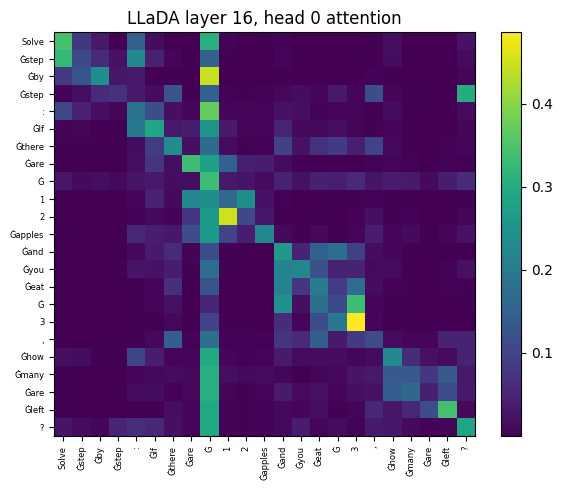

In [ ]:
import matplotlib.pyplot as plt

attn = attn_l16_long[0, 0].to(torch.float32).detach().cpu().numpy()  # [T, T]
tokens = tok_llada.convert_ids_to_tokens(enc_long["input_ids"][0])

plt.figure(figsize=(6, 5))
plt.imshow(attn, aspect="auto")
plt.colorbar()
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=6)
plt.yticks(range(len(tokens)), tokens, fontsize=6)
plt.title("LLaDA layer 16, head 0 attention")
plt.tight_layout()
plt.show()

In [ ]:
import os, sys

project_root = "/content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning"  # change if your folder name differs
os.chdir(project_root)
print("CWD:", os.getcwd())

CWD: /content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning


In [ ]:
import sys, os

project_root = "/content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning"  # same as above
if project_root not in sys.path:
    sys.path.append(project_root)

print("In sys.path?", project_root in sys.path)

In sys.path? True


In [ ]:
from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
)

In [ ]:
B, H, T, _ = attn_l16_long.shape
prompt_len = 0          # everything is "generated"
gen_length = T

bi = compute_bidirectionality_index(attn_l16_long, prompt_len, gen_length)
ent = compute_attention_entropy(attn_l16_long, prompt_len, gen_length)
ali = compute_attention_localization_index(attn_l16_long, prompt_len, gen_length)

print("BI:", bi)        # [B]
print("Entropy:", ent)  # [B]
print("ALI:", ali)      # [B]

BI: tensor([0.3875], device='cuda:0')
Entropy: tensor([2.0704], device='cuda:0')
ALI: tensor([0.2975], device='cuda:0')


In [ ]:
layers_to_probe = [4, 16, 24, 31]
bi_vals = []
ent_vals = []
ali_vals = []

for l in layers_to_probe:
    attn_l = get_llada_layer_attn(mdl_llada, enc_long["input_ids"], layer_idx=l)
    B, H, T, _ = attn_l.shape
    prompt_len = 0
    gen_length = T

    bi_l = compute_bidirectionality_index(attn_l, prompt_len, gen_length).mean().item()
    ent_l = compute_attention_entropy(attn_l, prompt_len, gen_length).mean().item()
    ali_l = compute_attention_localization_index(attn_l, prompt_len, gen_length).mean().item()

    bi_vals.append(bi_l)
    ent_vals.append(ent_l)
    ali_vals.append(ali_l)

for l, bi_l, ent_l, ali_l in zip(layers_to_probe, bi_vals, ent_vals, ali_vals):
    print(f"Layer {l:2d} | BI={bi_l:.3f} | Entropy={ent_l:.3f} | ALI={ali_l:.3f}")

Layer  4 | BI=0.424 | Entropy=3.006 | ALI=0.015
Layer 16 | BI=0.387 | Entropy=2.070 | ALI=0.298
Layer 24 | BI=0.356 | Entropy=2.331 | ALI=0.170
Layer 31 | BI=0.349 | Entropy=2.639 | ALI=0.065


2.1 Helper: tokenize Q + A and get prompt/answer split

In [ ]:
import torch

def tokenize_qa_and_get_spans(tokenizer, question: str, answer: str, device):
    """
    Tokenize question and (question + answer) consistently,
    and return:
      - input_ids_full: [1, L_total]
      - prompt_len: length of question tokens
      - gen_length: length of answer tokens
    """
    # Work WITHOUT extra special tokens to make the boundary clean
    q_ids = tokenizer(question, add_special_tokens=False)["input_ids"]
    qa_ids = tokenizer(question + " " + answer, add_special_tokens=False)["input_ids"]

    prompt_len = len(q_ids)
    gen_length = len(qa_ids) - prompt_len

    # Now create the actual model input (same tokenization settings)
    enc_full = tokenizer(
        question + " " + answer,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(device)

    input_ids_full = enc_full["input_ids"]  # [1, L_total]

    assert input_ids_full.shape[1] == len(qa_ids), "Length mismatch – sanity check failed."

    return input_ids_full, prompt_len, gen_length

2.2 Wrapper: run LLaDA attention probes for Q + A on chosen layers

In [ ]:
def llada_attention_probes_for_qa(
    model,
    tokenizer,
    question: str,
    answer: str,
    layers_to_probe,
    device,
):
    """
    Compute BI / Entropy / ALI for LLaDA on a (question, answer) pair,
    restricted to the answer region (generative region G).

    Returns:
      metrics: dict[layer_idx] = {"bi": float, "entropy": float, "ali": float}
    """
    input_ids, prompt_len, gen_length = tokenize_qa_and_get_spans(
        tokenizer, question, answer, device
    )

    metrics = {}

    for layer_idx in layers_to_probe:
        attn_layer = get_llada_layer_attn(model, input_ids, layer_idx=layer_idx)
        bi = compute_bidirectionality_index(attn_layer, prompt_len, gen_length).mean().item()
        ent = compute_attention_entropy(attn_layer, prompt_len, gen_length).mean().item()
        ali = compute_attention_localization_index(attn_layer, prompt_len, gen_length).mean().item()

        metrics[layer_idx] = {
            "bi": bi,
            "entropy": ent,
            "ali": ali,
        }

    return metrics

2.3 Test it on a simple QA example

In [ ]:
# q = "Solve step by step: If there are 12 apples and you eat 3, how many are left?"
# a = "There are 9 apples left."

# layers_to_probe = [4, 16, 24, 31]

# metrics = llada_attention_probes_for_qa(
#     mdl_llada,
#     tok_llada,
#     q,
#     a,
#     layers_to_probe=layers_to_probe,
#     device=device,
# )

# for layer_idx in layers_to_probe:
#     m = metrics[layer_idx]
#     print(
#         f"Layer {layer_idx:2d} | BI={m['bi']:.3f} | "
#         f"Entropy={m['entropy']:.3f} | ALI={m['ali']:.3f}"
#     )

In [ ]:
def llada_attention_probes_on_examples(
    model,
    tokenizer,
    qa_pairs,
    layers_to_probe,
    device,
):
    """
    qa_pairs: list of dicts like {"q": "...", "a": "..."}
    Returns:
      results: list of dicts, each with:
        {
          "q": ...,
          "a": ...,
          "metrics": {layer_idx: {"bi": float, "entropy": float, "ali": float}}
        }
    """
    results = []
    for ex in qa_pairs:
        q = ex["q"]
        a = ex["a"]
        metrics = llada_attention_probes_for_qa(
            model,
            tokenizer,
            q,
            a,
            layers_to_probe=layers_to_probe,
            device=device,
        )
        results.append({
            "q": q,
            "a": a,
            "metrics": metrics,
        })
    return results

In [ ]:
%%writefile objective3/probes/llada_attention_utils.py
import math
import torch


@torch.no_grad()
def get_llada_layer_attn(model, input_ids: torch.LongTensor, layer_idx: int):
    """
    Compute full attention matrix [B, n_heads, T, T] for a given LLaDA layer.

    - model: AutoModelForCausalLM (LLaDAModelLM)
    - input_ids: [B, T]
    - layer_idx: 0-based index in [0, n_layers-1]
    """
    base = model.model           # LLaDAModel
    cfg = base.config

    assert 0 <= layer_idx < cfg.n_layers, f"layer_idx must be in [0, {cfg.n_layers-1}]"

    out = model(
        input_ids=input_ids,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

    hidden_states = out.hidden_states  # tuple length n_layers + 1
    x = hidden_states[layer_idx]       # [B, T, d_model]

    block = base.transformer.blocks[layer_idx]
    B, T, C = x.shape

    # 1) Norm + QKV projections
    x_normed = block.attn_norm(x)
    q = block.q_proj(x_normed)
    k = block.k_proj(x_normed)
    v = block.v_proj(x_normed)

    # 2) Reshape to heads
    n_heads = cfg.n_heads
    head_dim = cfg.d_model // n_heads

    q = q.view(B, T, n_heads, head_dim).transpose(1, 2)  # [B, H, T, d]

    kv_heads = k.shape[-1] // head_dim
    k = k.view(B, T, kv_heads, head_dim).transpose(1, 2)
    v = v.view(B, T, kv_heads, head_dim).transpose(1, 2)

    # 3) Expand KV heads (GQA/MQA)
    if kv_heads != n_heads:
        assert n_heads % kv_heads == 0
        repeat = n_heads // kv_heads
        k = k.repeat_interleave(repeat, dim=1, output_size=n_heads)
        v = v.repeat_interleave(repeat, dim=1, output_size=n_heads)

    # 4) RoPE
    if getattr(cfg, "rope", True):
        q, k = block.rotary_emb(q, k)

    # 5) Attention scores + softmax
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(head_dim)  # [B, H, T, T]
    attn_probs = torch.softmax(scores, dim=-1)

    return attn_probs


def build_full_input_from_ids_and_answer(
    tokenizer,
    prompt_ids: torch.Tensor,
    answer,
    device,
):
    """
    Construct [prompt | answer] token sequence.

    - prompt_ids: [L_prompt] (1D LongTensor)
    - answer: raw ground-truth answer (string or numeric)
    Returns:
      input_ids_full: [1, L_total]
      prompt_len:     int
      gen_length:     int (length of answer segment)
    """
    if not isinstance(answer, str):
        answer = str(answer)

    # You *can* prepend "The answer is " here if you want more context:
    # answer = "The answer is " + answer

    ans_ids = tokenizer(answer, add_special_tokens=False)["input_ids"]

    prompt_ids_list = prompt_ids.tolist()
    full_ids_list = prompt_ids_list + ans_ids

    input_ids_full = torch.tensor(
        full_ids_list, dtype=torch.long, device=device
    ).unsqueeze(0)  # [1, L_total]

    prompt_len = len(prompt_ids_list)
    gen_length = len(ans_ids)

    return input_ids_full, prompt_len, gen_length

Writing objective3/probes/llada_attention_utils.py


In [ ]:
%%writefile objective3/probes/__init__.py
from .attention_metrics import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
)
from .llada_attention_utils import (
    get_llada_layer_attn,
    build_full_input_from_ids_and_answer,
)

Overwriting objective3/probes/__init__.py


In [ ]:
%%writefile objective3/scripts/llada_attention_eval_base.py
import argparse
import json
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
    get_llada_layer_attn,
    build_full_input_from_ids_and_answer,
)

# TODO: plug your actual dataset classes here.
# These names are placeholders – replace them with the real ones from your repo.
from gsm8k_test_dataset import GSM8KTestDataset          # <-- you define/import this
from logiqa_extended_dataset import LogiQAExtendedDataset
from gpqa_test_dataset import GPQATestDataset
from aime2025_dataset import AIME2025Dataset

DATASET_MAP = {
    "gsm8k_test": GSM8KTestDataset,
    "logiqa_ext": LogiQAExtendedDataset,
    "gpqa_test":  GPQATestDataset,
    "aime2025":   AIME2025Dataset,
}


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model_path", required=True,
                    help="Base LLaDA model (e.g., GSAI-ML/LLaDA-8B-Instruct)")
    ap.add_argument("--checkpoint_path", default="",
                    help="Optional SFT/LoRA checkpoint; leave empty for base")
    ap.add_argument("--dataset", required=True, choices=list(DATASET_MAP.keys()))
    ap.add_argument("--layers", type=str, default="4,16,24,31",
                    help="Comma-separated layer indices, e.g. '4,16,24,31'")
    ap.add_argument("--batch_size", type=int, default=1)
    ap.add_argument("--max_examples", type=int, default=128,
                    help="Subsample up to this many examples")
    ap.add_argument("--output_path", type=str, default="llada_attn_base.json")
    args = ap.parse_args()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[info] device: {device}")

    # ----- Tokenizer + model -----
    tok = AutoTokenizer.from_pretrained(args.model_path, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        args.model_path,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16,
    )
    if args.checkpoint_path:
        model = PeftModel.from_pretrained(model, args.checkpoint_path, torch_dtype=torch.bfloat16)
    model.to(device)
    model.eval()

    # ----- Dataset -----
    DatasetCls = DATASET_MAP[args.dataset]
    # Match *your* dataset constructor – this is a typical pattern:
    dataset = DatasetCls(tok, split="test", subsample=args.max_examples)
    dl = DataLoader(dataset, batch_size=args.batch_size, shuffle=False, collate_fn=dataset.collate_fn)

    layers = [int(x) for x in args.layers.split(",") if x.strip() != ""]
    print(f"[info] probing layers: {layers}")

    # accumulators
    bi_per_layer = {l: [] for l in layers}
    ent_per_layer = {l: [] for l in layers}
    ali_per_layer = {l: [] for l in layers}

    n_examples = 0

    with torch.no_grad():
        for batch in dl:
            input_ids = batch["input_ids"].to(device)  # [B, L_prompt]
            answers = batch["answers"]                # list of GT answers (str or other)
            B = input_ids.size(0)

            for b in range(B):
                prompt_ids = input_ids[b]
                gt_answer = answers[b]

                full_ids, prompt_len, gen_length = build_full_input_from_ids_and_answer(
                    tok, prompt_ids, gt_answer, device
                )

                for l in layers:
                    attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=l)

                    bi  = compute_bidirectionality_index(attn_layer, prompt_len, gen_length).mean().item()
                    ent = compute_attention_entropy(attn_layer, prompt_len, gen_length).mean().item()
                    ali = compute_attention_localization_index(attn_layer, prompt_len, gen_length).mean().item()

                    bi_per_layer[l].append(bi)
                    ent_per_layer[l].append(ent)
                    ali_per_layer[l].append(ali)

                n_examples += 1
                if n_examples >= args.max_examples:
                    break

            if n_examples >= args.max_examples:
                break

    # ----- aggregate -----
    stats = {}
    for l in layers:
        bi_arr = np.array(bi_per_layer[l], dtype=float)
        ent_arr = np.array(ent_per_layer[l], dtype=float)
        ali_arr = np.array(ali_per_layer[l], dtype=float)

        stats[l] = {
            "bi_mean": float(bi_arr.mean()) if bi_arr.size else 0.0,
            "bi_std":  float(bi_arr.std())  if bi_arr.size else 0.0,
            "ent_mean": float(ent_arr.mean()) if ent_arr.size else 0.0,
            "ent_std":  float(ent_arr.std())  if ent_arr.size else 0.0,
            "ali_mean": float(ali_arr.mean()) if ali_arr.size else 0.0,
            "ali_std":  float(ali_arr.std())  if ali_arr.size else 0.0,
            "num_examples": int(bi_arr.size),
        }

    out = {
        "model_path": args.model_path,
        "checkpoint_path": args.checkpoint_path,
        "dataset": args.dataset,
        "layers": layers,
        "stats": stats,
        "max_examples": args.max_examples,
    }

    with open(args.output_path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"[saved] {args.output_path}")
    print(f"[info] total examples: {n_examples}")


if __name__ == "__main__":
    main()

Writing objective3/scripts/llada_attention_eval_base.py


In [ ]:
import os
os.chdir("/content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning")

# Make sure the directory exists
os.makedirs("objective3", exist_ok=True)

# Create (or overwrite) __init__.py to mark it as a package
with open("objective3/__init__.py", "w") as f:
    f.write("# objective3 package\n")

In [ ]:
!python -c "import objective3; print('objective3 imported OK:', objective3)"

objective3 imported OK: <module 'objective3' from '/content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning/objective3/__init__.py'>


## Generate on a bunch of test examples from all the 4 datasets under study

In [ ]:
import os, json, math, time, sys
import numpy as np
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# --- load your LLaDA tokenizer + model (already in your notebook previously) ---
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# DATASETS_INFO = {
#     # GSM8K: official HF, "main" config, use test split for evaluation
#     "gsm8k_test": {
#         "hf": "openai/gsm8k",
#         "config": "main",
#         "split": "test",
#     },

#     # LogiQA: HF card says train/validation/test splits.
#     # In *principle*, you’d want the "test" split for evaluation.
#     # In practice, your current environment is blocking script-based datasets.
#     # So this entry is "logically correct" but may still error in Colab
#     # unless you work around the script restriction or use a local copy.
#     "logiqa_test": {
#         "hf": "lucasmccabe/logiqa",  # or "EleutherAI/logiqa"
#         "config": None,              # single config
#         "split": "test",             # per HF dataset card
#     },

#     # GPQA: Idavidrein/gpqa has NO 'test' split, only 'train' per config.
#     # The benchmark is evaluation-only; you just use the train split.
#     "gpqa_main": {
#         "hf": "Idavidrein/gpqa",
#         "config": "gpqa_main",       # or "gpqa_diamond", etc.
#         "split": "train",            # only split available
#     },

#     # AIME 2025: you successfully loaded MathArena/aime_2025 with split 'train'.
#     # That train split *is* the 30 AIME 2025 problems; you can treat it as test.
#     "aime2025": {
#         "hf": "MathArena/aime_2025",
#         "config": None,              # no subset/config
#         "split": "train",            # single available split
#     },
# }

In [ ]:
from datasets import load_dataset
import torch

# Correct HF configs/splits for our four benchmarks
DATASETS_INFO = {
    # GSM8K: official HF, "main" config, test split
    "gsm8k_test": {
        "hf": "openai/gsm8k",
        "config": "main",
        "split": "test",
    },

    # LogiQA (English): lucasmccabe/logiqa, has train/validation/test splits.
    # NOTE: in your current Colab environment you may still hit the
    # "dataset scripts are no longer supported" error, but this is the
    # logically correct config/split.
    "logiqa_test": {
        "hf": "lucasmccabe/logiqa",
        "config": None,   # single default config
        "split": "test",
    },

    # GPQA: Idavidrein/gpqa – evaluation-only benchmark; uses "train" as the split.
    "gpqa_main": {
        "hf": "Idavidrein/gpqa",
        "config": "gpqa_main",   # or "gpqa_diamond", etc.
        "split": "train",        # only split available
    },

    # AIME2025: MathArena/aime_2025 – 30 problems in train split
    "aime2025": {
        "hf": "MathArena/aime_2025",
        "config": None,
        "split": "train",
    },
}


# HF dataset loader that handles config + split
def load_hf_dataset(ds_key):
    info = DATASETS_INFO[ds_key]
    hf_id = info["hf"]
    cfg   = info.get("config", None)
    split = info["split"]

    print(f"[load] {ds_key} <- {hf_id} (config={cfg}, split={split})")
    if cfg is None:
        ds = load_dataset(hf_id, split=split)
    else:
        ds = load_dataset(hf_id, cfg, split=split)

    print(f"  -> {len(ds)} examples, fields: {list(ds.features.keys())}")
    return ds


# Field extraction helpers (dataset-aware)
def extract_qa_from_example(ds_name, ex):
    """
    Return (question_text, answer_text) for different benchmarks.
    """

    # ── GSM8K ───────────────────────────────────────────────
    # openai/gsm8k (main): fields: 'question', 'answer'
    if ds_name.startswith("gsm8k"):
        return ex["question"], ex["answer"]

    # ── LogiQA (lucasmccabe/logiqa) ───────────────────────
    # features: context (str), query (str), options (seq[str]), correct_option (str)
    if ds_name.startswith("logiqa"):
        q = ex.get("query") or ex.get("question")  # just in case
        ans = ex.get("correct_option") or ex.get("answer")
        if q is None:
            # fall back to context+query if something weird happens
            ctx = ex.get("context", "")
            q = (ctx + "\n\n" + str(ex)).strip()
        return str(q), str(ans)

    # ── GPQA (Idavidrein/gpqa) ────────────────────────────
    # dataset is gated; schema can vary a bit across mirrors.
    # We handle common patterns: 'question', 'answer', 'choices', 'label'.
    if ds_name.startswith("gpqa"):
        # question text
        q = (
            ex.get("question")
            or ex.get("stem")
            or ex.get("prompt")
            or ex.get("context")
        )
        # answers / labels
        if "answer" in ex:
            return str(q), str(ex["answer"])

        if "label" in ex:
            label = ex["label"]
            # choices pattern
            for choices_key in ("choices", "options", "answers"):
                if choices_key in ex and isinstance(ex[choices_key], (list, tuple)):
                    try:
                        return str(q), str(ex[choices_key][int(label)])
                    except Exception:
                        return str(q), str(label)
            return str(q), str(label)

        # fall back to any multiple-choice-like fields
        for choices_key in ("choices", "options", "answers"):
            if choices_key in ex:
                return str(q), " ".join(map(str, ex[choices_key]))

        return str(q), ""

    # ── AIME / others: 'problem' + 'answer' (MathArena/aime_2025) ──────
    if ds_name.startswith("aime") or ("problem" in ex and "answer" in ex):
        return ex["problem"], str(ex["answer"])

    # ── Generic fallback (for any unknown schema) ─────────
    if "question" in ex and "answer" in ex:
        return str(ex["question"]), str(ex["answer"])

    text = " ".join(str(ex.get(f, "")) for f in ["text", "prompt", "context"] if f in ex)
    return text, str(ex.get("answer", ""))


def tokenize_prompt_then_attach_answer(question_str, answer_str, tokenizer, device):
    """
    Produce prompt_ids_tensor [L_prompt] for the question (without special tokens),
    and return answer string (we'll tokenize it separately when building full_ids).
    """
    enc = tokenizer(question_str, add_special_tokens=False)
    input_ids_prompt = torch.tensor(enc["input_ids"], dtype=torch.long, device=device)
    return input_ids_prompt, str(answer_str)


# Quick sanity check on GSM8K
# ds_gsm = load_hf_dataset("gsm8k_test")
# print(extract_qa_from_example("gsm8k_test", ds_gsm[0]))

In [ ]:
import os, importlib, objective3.probes as probes

os.chdir("/content/drive/MyDrive/CSE_576/NLP_Project_d1_reasoning")
importlib.reload(probes)

from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
    get_llada_layer_attn,
    build_full_input_from_ids_and_answer,
)

print("Imported from objective3.probes OK.")

Imported from objective3.probes OK.


In [ ]:
import numpy as np

def run_probes_on_hf_dataset(
    model, tokenizer, hf_dataset, ds_name,
    layers_to_probe=[4,16,24,31], max_examples=128, device="cuda"
):
    stats_raw = {l: {"bi": [], "ent": [], "ali": []} for l in layers_to_probe}
    n = 0

    model.eval()
    with torch.no_grad():
        for ex in hf_dataset:
            q_str, a_str = extract_qa_from_example(ds_name, ex)
            if not q_str or str(q_str).strip() == "":
                continue

            # prompt ids
            prompt_ids, answer_str = tokenize_prompt_then_attach_answer(
                q_str, a_str, tokenizer, device
            )
            ans_ids = tokenizer(answer_str, add_special_tokens=False)["input_ids"]
            if len(ans_ids) == 0:
                continue

            full_ids_list = prompt_ids.tolist() + ans_ids
            full_ids = torch.tensor([full_ids_list], dtype=torch.long, device=device)
            prompt_len = len(prompt_ids)
            gen_len = len(ans_ids)

            for l in layers_to_probe:
                attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=l)
                bi  = compute_bidirectionality_index(attn_layer, prompt_len, gen_len).item()
                ent = compute_attention_entropy(attn_layer, prompt_len, gen_len).item()
                ali = compute_attention_localization_index(attn_layer, prompt_len, gen_len).item()

                stats_raw[l]["bi"].append(bi)
                stats_raw[l]["ent"].append(ent)
                stats_raw[l]["ali"].append(ali)

            n += 1
            if n % 10 == 0:
                print(f"[{ds_name}] processed {n} examples...", end="\r")
            if n >= max_examples:
                break

    # aggregate
    stats = {}
    for l in layers_to_probe:
        bi_arr  = np.array(stats_raw[l]["bi"], dtype=float)
        ent_arr = np.array(stats_raw[l]["ent"], dtype=float)
        ali_arr = np.array(stats_raw[l]["ali"], dtype=float)
        stats[l] = {
            "bi_mean":  float(bi_arr.mean())  if bi_arr.size else 0.0,
            "bi_std":   float(bi_arr.std())   if bi_arr.size else 0.0,
            "ent_mean": float(ent_arr.mean()) if ent_arr.size else 0.0,
            "ent_std":  float(ent_arr.std())  if ent_arr.size else 0.0,
            "ali_mean": float(ali_arr.mean()) if ali_arr.size else 0.0,
            "ali_std":  float(ali_arr.std())  if ali_arr.size else 0.0,
            "num_examples": int(bi_arr.size),
        }

    print(f"\n[{ds_name}] finished {stats[layers_to_probe[0]]['num_examples']} examples.")
    return stats

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
layers_to_probe = [4,16,24,31]
max_examples = 128  # adjust up/down as GPU allows

# LLaDA model + tokenizer should already be loaded as mdl_llada, tok_llada

all_stats = {}

# GSM8K
ds_gsm = load_hf_dataset("gsm8k_test")
all_stats["GSM8K"] = run_probes_on_hf_dataset(
    mdl_llada, tok_llada, ds_gsm, "gsm8k_test",
    layers_to_probe=layers_to_probe, max_examples=max_examples, device=device,
)

[load] gsm8k_test <- openai/gsm8k (config=main, split=test)
  -> 1319 examples, fields: ['question', 'answer']


NameError: name 'max_examples' is not defined

In [ ]:
# AIME2025 (MathArena)
ds_aime = load_hf_dataset("aime2025")
all_stats["AIME2025"] = run_probes_on_hf_dataset(
    mdl_llada, tok_llada, ds_aime, "aime2025",
    layers_to_probe=layers_to_probe, max_examples=max_examples, device=device,
)

[load] aime2025 <- MathArena/aime_2025 (config=None, split=train)
  -> 30 examples, fields: ['problem_idx', 'problem', 'answer', 'problem_type']


NameError: name 'max_examples' is not defined

In [ ]:
import matplotlib.pyplot as plt

def plot_three_metrics(all_stats_map, layers):
    plt.figure(figsize=(15,4))

    # BI
    plt.subplot(1,3,1)
    for name, stats in all_stats_map.items():
        bi = [stats[l]["bi_mean"] for l in layers]
        plt.plot(layers, bi, marker="o", label=name)
    plt.title("Bidirectionality Index (answer region)")
    plt.xlabel("Layer"); plt.ylabel("BI"); plt.grid(True); plt.legend()

    # Entropy
    plt.subplot(1,3,2)
    for name, stats in all_stats_map.items():
        ent = [stats[l]["ent_mean"] for l in layers]
        plt.plot(layers, ent, marker="o", label=name)
    plt.title("Attention entropy"); plt.xlabel("Layer"); plt.grid(True); plt.legend()

    # ALI
    plt.subplot(1,3,3)
    for name, stats in all_stats_map.items():
        ali = [stats[l]["ali_mean"] for l in layers]
        plt.plot(layers, ali, marker="o", label=name)
    plt.title("Attention Localization Index (answer region)")
    plt.xlabel("Layer"); plt.grid(True); plt.legend()

    plt.tight_layout()
    plt.show()

plot_three_metrics(all_stats, layers_to_probe)

NameError: name 'all_stats' is not defined

## Plots

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
    get_llada_layer_attn,
    build_full_input_from_ids_and_answer,  # if you already have this
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Re-load datasets (cheap, uses cache)
ds_gsm = load_hf_dataset("gsm8k_test")
ds_aime = load_hf_dataset("aime2025")


device: cuda
[load] gsm8k_test <- openai/gsm8k (config=main, split=test)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  -> 1319 examples, fields: ['question', 'answer']
[load] aime2025 <- MathArena/aime_2025 (config=None, split=train)
  -> 30 examples, fields: ['problem_idx', 'problem', 'answer', 'problem_type']


In [ ]:
def build_full_ids_from_example(ds_name, dataset, index, tokenizer, device):
    """
    Returns:
      full_ids: [1, T]
      prompt_len: int
      gen_len: int
      tokens: list[str]
      q: question string
      a: answer string
    """
    ex = dataset[index]
    q, a = extract_qa_from_example(ds_name, ex)
    prompt_ids, ans_str = tokenize_prompt_then_attach_answer(q, a, tokenizer, device)
    ans_ids = tokenizer(ans_str, add_special_tokens=False)["input_ids"]
    if len(ans_ids) == 0:
        raise ValueError("Answer tokenized to empty sequence.")

    full_ids_list = prompt_ids.tolist() + ans_ids
    full_ids = torch.tensor([full_ids_list], dtype=torch.long, device=device)
    prompt_len = len(prompt_ids)
    gen_len = len(ans_ids)
    tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())
    return full_ids, prompt_len, gen_len, tokens, q, ans_str


def plot_attn_heatmap(attn_layer, tokens, layer, head=0, title_prefix=""):
    """
    attn_layer: [1, H, T, T]
    """
    arr = attn_layer[0, head].to(torch.float32).cpu().numpy()
    T = len(tokens)

    plt.figure(figsize=(8, 6))
    plt.imshow(arr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(T), tokens, rotation=90, fontsize=6)
    plt.yticks(range(T), tokens, fontsize=6)
    title = f"{title_prefix} layer {layer}, head {head} attention"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_incoming_bar(attn_layer, tokens, prompt_len, gen_len, title_prefix=""):
    """
    Sum attention *from answer tokens* into each position (averaged over heads).
    """
    # attn_layer: [1, H, T, T]
    attn_mean = attn_layer.mean(dim=1)[0]          # [T, T]
    answer_rows = attn_mean[prompt_len:prompt_len+gen_len, :]  # [G, T]
    incoming = answer_rows.sum(dim=0)              # [T]

    vals = incoming.to(torch.float32).cpu().numpy()
    T = len(tokens)

    plt.figure(figsize=(8, 3))
    plt.bar(range(T), vals)
    plt.xticks(range(T), tokens, rotation=90, fontsize=6)
    title = f"{title_prefix} incoming mass from answer tokens"
    plt.title(title)
    plt.tight_layout()
    plt.show()


GSM8K example 0
QUESTION:
 Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
ANSWER:
 Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18
Tokens:
 ['Janet', 'âĢĻs', 'Ġducks', 'Ġlay', 'Ġ', '1', '6', 'Ġeggs', 'Ġper', 'Ġday', '.', 'ĠShe', 'Ġeats', 'Ġthree', 'Ġfor', 'Ġbreakfast', 'Ġevery', 'Ġmorning', 'Ġand', 'Ġb', 'akes', 'Ġmuffins', 'Ġfor', 'Ġher', 'Ġfriends', 'Ġevery', 'Ġday', 'Ġwith', 'Ġfour', '.', 'ĠShe', 'Ġsells', 'Ġthe', 'Ġremainder', 'Ġat', 'Ġthe', 'Ġfarmers', "'", 'Ġmarket', 'Ġdaily', 'Ġfor', 'Ġ$', '2', 'Ġper', 'Ġfresh', 'Ġduck', 'Ġegg', '.', 'ĠHow', 'Ġmuch', 'Ġin', 'Ġdollars', 'Ġdoes', 'Ġshe', 'Ġmake', 'Ġevery', 'Ġday', 'Ġat', 'Ġthe', 'Ġfarmers', "'", 'Ġmarket', '?', 'Janet', 

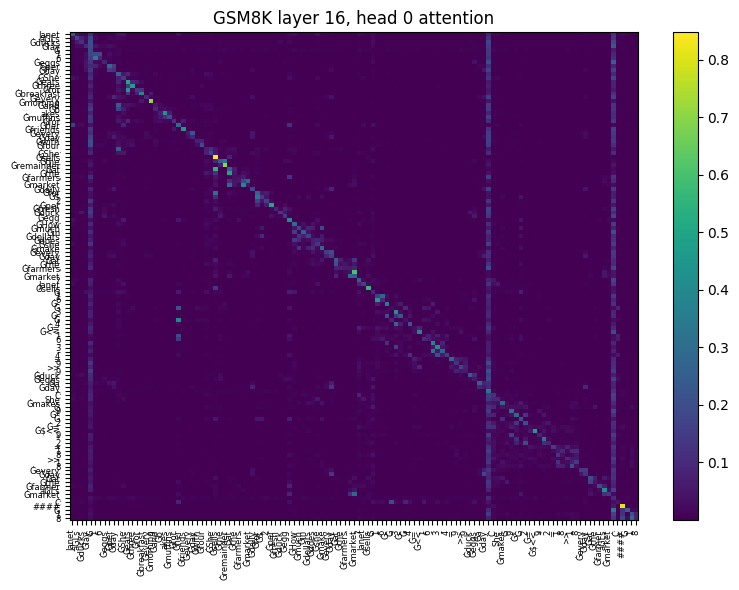

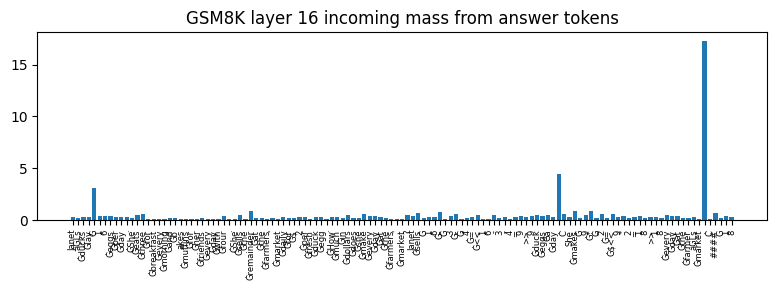

In [ ]:
# Pick a GSM8K example (0 is Janet's ducks in your printout)
gsm_idx = 0

full_ids_gsm, pl_gsm, gl_gsm, toks_gsm, q_gsm, a_gsm = build_full_ids_from_example(
    "gsm8k_test", ds_gsm, gsm_idx, tok_llada, device
)

print("GSM8K example", gsm_idx)
print("QUESTION:\n", q_gsm)
print("ANSWER:\n", a_gsm)
print("Tokens:\n", toks_gsm)

# ---- Layer 16 attention ----
layer_mid = 16
attn_gsm_l16 = get_llada_layer_attn(mdl_llada, full_ids_gsm, layer_idx=layer_mid)

# Heatmap
plot_attn_heatmap(attn_gsm_l16, toks_gsm, layer=layer_mid, head=0, title_prefix="GSM8K")

# Incoming-mass bar chart
plot_incoming_bar(attn_gsm_l16, toks_gsm, pl_gsm, gl_gsm,
                  title_prefix=f"GSM8K layer {layer_mid}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_attn_heatmap_clean(attn_layer, tokens, prompt_len, gen_len,
                            layer, head=0, topk_cols=25, title_prefix=""):
    """
    Show a readable heatmap:
      - rows = answer tokens only
      - columns = top-K tokens that receive the most mass from answers
    """
    # attn_layer: [1, H, T, T]
    arr = attn_layer[0, head].to(torch.float32).cpu().numpy()   # [T, T]
    T = len(tokens)

    # Restrict rows to answer tokens
    row_start = prompt_len
    row_end = prompt_len + gen_len
    sub_rows = arr[row_start:row_end, :]                        # [G, T]

    # Pick top-K columns by total incoming mass from answer rows
    col_scores = sub_rows.sum(axis=0)                           # [T]
    top_idx = np.argsort(-col_scores)[:topk_cols]
    top_idx = np.sort(top_idx)                                  # keep chronological order

    sub = sub_rows[:, top_idx]                                  # [G, K]
    row_labels = [tokens[i] for i in range(row_start, row_end)]
    col_labels = [tokens[i] for i in top_idx]

    plt.figure(figsize=(max(6, 0.4*len(col_labels)), max(3, 0.4*len(row_labels))))
    plt.imshow(sub, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(row_labels)), row_labels, fontsize=8)
    title = f"{title_prefix} layer {layer}, head {head} (answer rows, top-{topk_cols} cols)"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_incoming_bar_topk(attn_layer, tokens, prompt_len, gen_len,
                           topk=15, title_prefix=""):
    """
    Horizontal bar plot of top-K tokens by incoming mass from answer tokens.
    Much more readable than plotting all tokens.
    """
    attn_mean = attn_layer.mean(dim=1)[0]                        # [T, T]
    answer_rows = attn_mean[prompt_len:prompt_len+gen_len, :]    # [G, T]
    incoming = answer_rows.sum(dim=0).to(torch.float32).cpu().numpy()  # [T]

    T = len(tokens)
    top_idx = np.argsort(-incoming)[:topk]
    top_vals = incoming[top_idx]
    labels = [tokens[i] for i in top_idx]

    # Normalize if you want (optional)
    # top_vals = top_vals / top_vals.sum()

    plt.figure(figsize=(8, max(3, 0.4*topk)))
    y = np.arange(len(top_idx))
    plt.barh(y, top_vals)
    plt.yticks(y, labels, fontsize=8)
    plt.gca().invert_yaxis()
    plt.xlabel("Total attention from answer tokens")
    title = f"{title_prefix} top-{topk} tokens by incoming mass"
    plt.title(title)
    plt.tight_layout()
    plt.show()

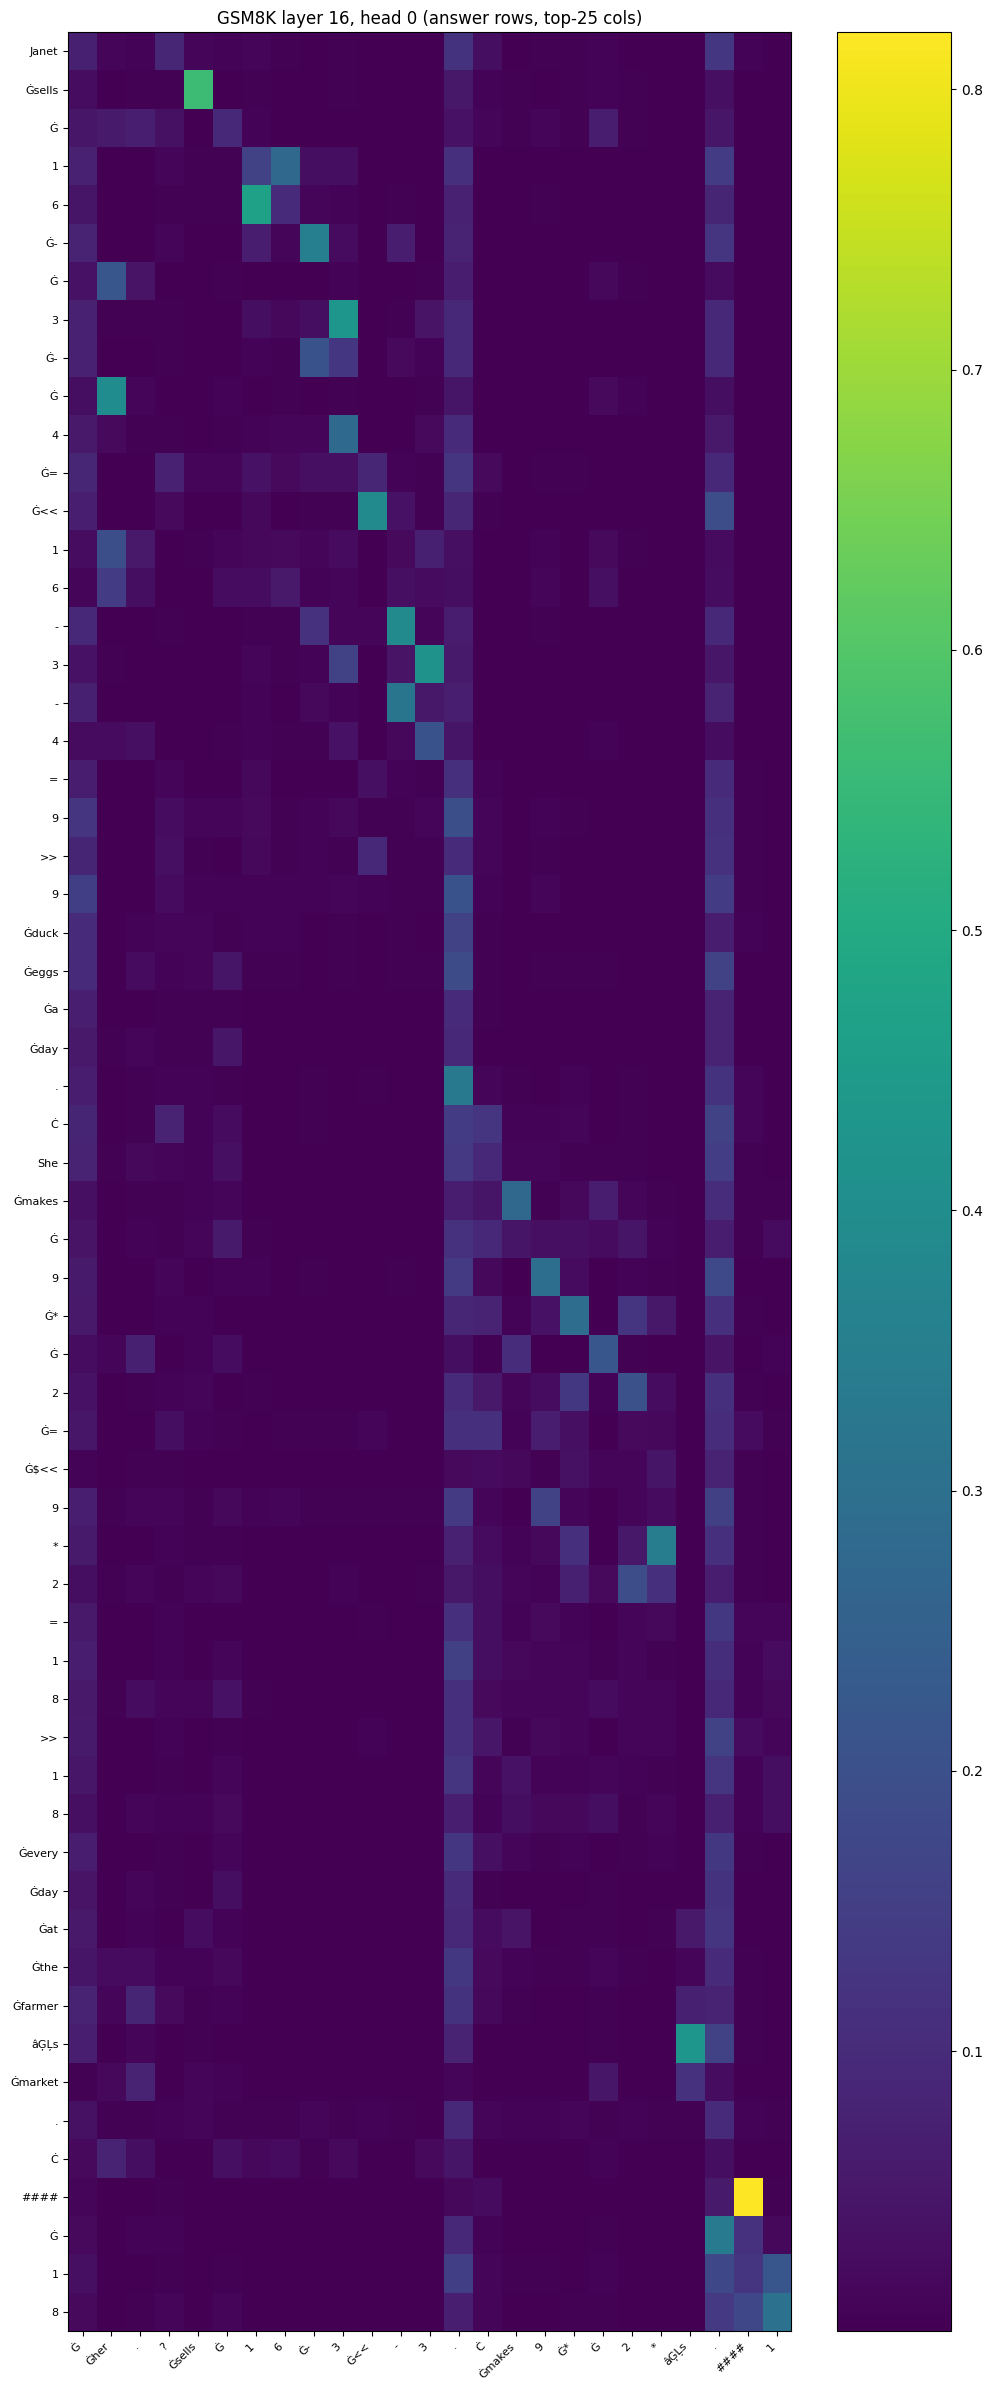

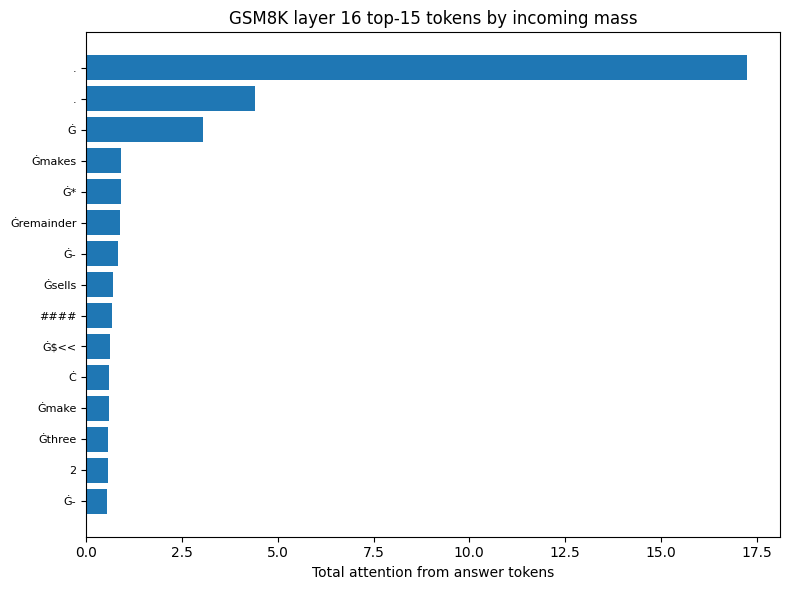

In [ ]:
layer_mid = 16

# Clean heatmap
plot_attn_heatmap_clean(
    attn_gsm_l16,
    toks_gsm,
    prompt_len=pl_gsm,
    gen_len=gl_gsm,
    layer=layer_mid,
    head=0,
    topk_cols=25,
    title_prefix="GSM8K"
)

# Clean bar chart
plot_incoming_bar_topk(
    attn_gsm_l16,
    toks_gsm,
    prompt_len=pl_gsm,
    gen_len=gl_gsm,
    topk=15,
    title_prefix=f"GSM8K layer {layer_mid}"
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def find_subsequence_indices(seq, subseq):
    """Return list of indices where subseq appears inside seq (first match)."""
    L, Ls = len(seq), len(subseq)
    for i in range(L - Ls + 1):
        if seq[i:i+Ls] == subseq:
            return list(range(i, i+Ls))
    return None

def get_final_answer_token_indices(answer_str, tokenizer, full_ids):
    """
    GSM8K-style answer with '#### final_answer'.
    Returns:
      final_idx: list[int] positions in full_ids for final answer tokens
      final_text: the final answer text
      final_ids: list[int] token ids for final answer
    """
    # split "explanation ... #### 18"
    parts = answer_str.split("####")
    final_text = parts[-1].strip() if len(parts) > 1 else answer_str.strip()
    final_ids = tokenizer(final_text, add_special_tokens=False)["input_ids"]

    seq = full_ids[0].tolist()
    final_idx = find_subsequence_indices(seq, final_ids)
    if final_idx is None:
        print("Warning: could not locate final answer subsequence; falling back to last tokens.")
        final_idx = list(range(len(seq) - len(final_ids), len(seq)))

    return final_idx, final_text, final_ids


def plot_final_answer_heatmap(attn_layer, tokens, answer_row_idx,
                              topk_cols=15, layer=16, head=0, title_prefix=""):
    """
    - Rows = final answer tokens only
    - Cols = top-K tokens they attend to most (by total mass)
    """
    arr = attn_layer[0, head].to(torch.float32).cpu().numpy()   # [T, T]
    T = len(tokens)

    # rows: only the final answer tokens
    rows = arr[answer_row_idx, :]                                # [G_final, T]

    # choose top-K columns by total mass from these rows
    col_scores = rows.sum(axis=0)
    top_idx = np.argsort(-col_scores)[:topk_cols]
    top_idx = np.sort(top_idx)

    sub = rows[:, top_idx]                                      # [G_final, K]
    row_labels = [tokens[i] for i in answer_row_idx]
    col_labels = [tokens[i] for i in top_idx]

    plt.figure(figsize=(max(6, 0.5*len(col_labels)), max(3, 0.5*len(row_labels))))
    plt.imshow(sub, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=9)
    plt.yticks(range(len(row_labels)), row_labels, fontsize=9)
    title = f"{title_prefix} layer {layer}, head {head} (final answer → top-{topk_cols})"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_final_answer_bar(attn_layer, tokens, answer_row_idx,
                          topk=10, title_prefix=""):
    """
    Horizontal bar: top-K tokens by total incoming attention from final answer tokens.
    """
    attn_mean = attn_layer.mean(dim=1)[0]                        # [T, T]
    rows = attn_mean[answer_row_idx, :]                          # [G_final, T]
    incoming = rows.sum(dim=0).to(torch.float32).cpu().numpy()   # [T]

    top_idx = np.argsort(-incoming)[:topk]
    top_vals = incoming[top_idx]
    labels = [tokens[i] for i in top_idx]

    plt.figure(figsize=(8, max(3, 0.5*topk)))
    y = np.arange(len(top_idx))
    plt.barh(y, top_vals)
    plt.yticks(y, labels, fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Total attention from final answer tokens")
    title = f"{title_prefix} top-{topk} positions"
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# pick the same GSM8K example as before (0 is Janet's ducks)
gsm_idx = 0
ex_gsm = ds_gsm[gsm_idx]
q_gsm, a_gsm = extract_qa_from_example("gsm8k_test", ex_gsm)

prompt_ids, ans_str = tokenize_prompt_then_attach_answer(q_gsm, a_gsm, tok_llada, device)
ans_ids = tok_llada(ans_str, add_special_tokens=False)["input_ids"]
full_ids_list = prompt_ids.tolist() + ans_ids
full_ids_gsm = torch.tensor([full_ids_list], dtype=torch.long, device=device)
toks_gsm = tok_llada.convert_ids_to_tokens(full_ids_gsm[0].tolist())

layer_mid = 16
attn_gsm_l16 = get_llada_layer_attn(mdl_llada, full_ids_gsm, layer_idx=layer_mid)


Final answer text: 18
Final answer token indices: [105, 106]
Final answer tokens: ['1', '8']


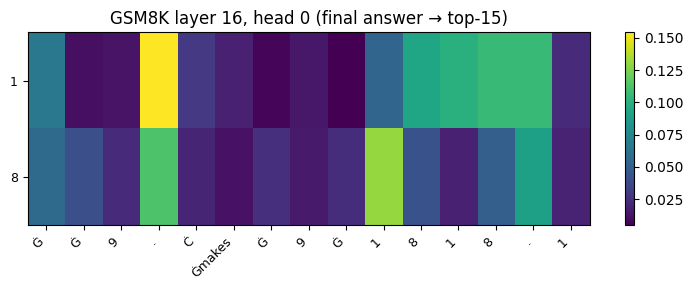

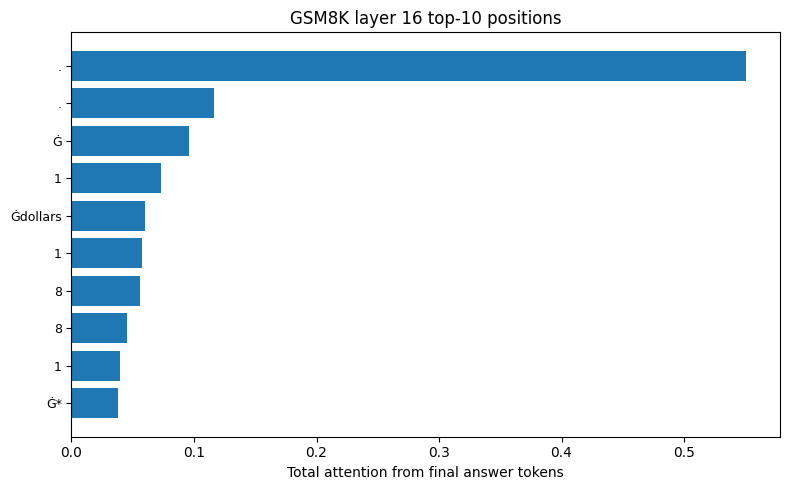

In [ ]:
# Find indices of final numeric answer tokens
ans_row_idx, final_text, final_ids = get_final_answer_token_indices(
    a_gsm, tok_llada, full_ids_gsm
)
print("Final answer text:", final_text)
print("Final answer token indices:", ans_row_idx)
print("Final answer tokens:", [toks_gsm[i] for i in ans_row_idx])

# Heatmap: final answer rows → top attended tokens
plot_final_answer_heatmap(
    attn_gsm_l16,
    toks_gsm,
    answer_row_idx=ans_row_idx,
    topk_cols=15,
    layer=layer_mid,
    head=0,
    title_prefix="GSM8K"
)

# Bar chart: which tokens receive the most mass from final answer tokens
plot_final_answer_bar(
    attn_gsm_l16,
    toks_gsm,
    answer_row_idx=ans_row_idx,
    topk=10,
    title_prefix=f"GSM8K layer {layer_mid}"
)


**Things to Do**
- Report mein kya kya daalna hai -> decide that first
- Module 1 ka kya hai -> corresponding chizein daaldo -> AND what are your observations
- Decide the type of analysis you must be doing after reading the chats
- Pick a few examples from each of the four datasets (objective 3)
- Clean the generation (objective 3)
- Progress (objective 3)

## Dec 5 2025

In [ ]:
from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
    get_llada_layer_attn,
)

1.1 Helper: generate with LLaDA for a given number of steps

In [ ]:
def generate_llada_with_steps(model, tokenizer, question_str,
                              diffusion_steps, max_new_tokens=64,
                              device="cuda"):
    """
    Run LLaDA generation for a single question with a given diffusion_steps.

    Returns:
      full_ids: [1, T] LongTensor (prompt + generated answer)
      prompt_len: int
      gen_len: int
      tokens: list[str] for full_ids
    """
    enc = tokenizer(question_str, return_tensors="pt").to(device)
    prompt_len = enc["input_ids"].shape[1]

    # LLaDA usually accepts diffusion-specific kwargs in generate(...)
    gen_ids = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        diffusion_steps=diffusion_steps,
        do_sample=False,
        use_cache=False,
    )
    full_ids = gen_ids
    gen_len = full_ids.shape[1] - prompt_len

    tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())

    return full_ids, prompt_len, gen_len, tokens

1.2 Collect metrics over steps × layers for one example

In [ ]:
import numpy as np

def collect_step_layer_metrics_for_example(
    model,
    tokenizer,
    question_str,
    steps_list,
    layers_list,
    max_new_tokens=64,
    device="cuda",
):
    """
    For a single question, generate an answer with each diffusion_steps in steps_list,
    then compute BI / Entropy / ALI on the generated answer region for each layer in layers_list.

    Returns:
      bi   : [S, L] numpy
      ent  : [S, L] numpy
      ali  : [S, L] numpy
      meta : dict with full_ids, tokens per step
    """
    S = len(steps_list)
    L = len(layers_list)

    bi  = np.zeros((S, L), dtype=float)
    ent = np.zeros((S, L), dtype=float)
    ali = np.zeros((S, L), dtype=float)

    meta = {}  # store prompt_len, gen_len, full_ids, tokens per step
    model.eval()

    with torch.no_grad():
        for si, steps in enumerate(steps_list):
            print(f"[steps={steps}] generating...")
            full_ids, prompt_len, gen_len, tokens = generate_llada_with_steps(
                model, tokenizer, question_str, diffusion_steps=steps,
                max_new_tokens=max_new_tokens, device=device
            )

            meta[steps] = {
                "full_ids": full_ids,
                "prompt_len": prompt_len,
                "gen_len": gen_len,
                "tokens": tokens,
            }

            for li, layer_idx in enumerate(layers_list):
                attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)

                bi_val  = compute_bidirectionality_index(attn_layer, prompt_len, gen_len).item()
                ent_val = compute_attention_entropy(attn_layer, prompt_len, gen_len).item()
                ali_val = compute_attention_localization_index(attn_layer, prompt_len, gen_len).item()

                bi[si, li]  = bi_val
                ent[si, li] = ent_val
                ali[si, li] = ali_val

                print(f"  layer {layer_idx:2d} | BI={bi_val:.3f} Ent={ent_val:.3f} ALI={ali_val:.3f}")

    return bi, ent, ali, meta

1.3 Run this for one GSM8K example and one AIME example

1. Define helpers (no diffusion_steps in .generate())

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from objective3.probes import (
    compute_bidirectionality_index,
    compute_attention_entropy,
    compute_attention_localization_index,
    get_llada_layer_attn,
)

In [ ]:
def generate_llada_once(model, tokenizer, question_str,
                        max_new_tokens=64, device="cuda"):
    """
    Single generation from the HF LLaDA model (no diffusion_steps kwarg).
    """
    enc = tokenizer(question_str, return_tensors="pt").to(device)
    prompt_len = enc["input_ids"].shape[1]

    gen_ids = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=False,
    )
    full_ids = gen_ids
    gen_len = full_ids.shape[1] - prompt_len
    tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())

    print(f"[generate] prompt_len={prompt_len}, gen_len={gen_len}, total_len={full_ids.shape[1]}")
    return full_ids, prompt_len, gen_len, tokens

2. Overwrite collect_step_layer_metrics_for_example

In [ ]:
def collect_step_layer_metrics_for_example(
    model,
    tokenizer,
    question_str,
    steps_list,        # [16,32,64,256] – treated as fractions of full_steps
    layers_list,       # e.g. [4,8,12,16,20,24,28,31]
    max_new_tokens=64,
    full_steps=256,    # reference so that 16/32/64/256 → 0.25/0.5/0.75/1.0
    device="cuda",
):
    """
    NEW VERSION (overwrites old one).

    1) Generate ONCE with the HF LLaDA model.
    2) For each 'step' in steps_list, take the first fraction of answer tokens:
          frac = min(1.0, step / full_steps)
          gen_len = round(frac * gen_len_full)
    3) For that answer prefix, compute BI / Entropy / ALI at each layer in layers_list.

    Returns:
      bi   : [S, L] numpy
      ent  : [S, L] numpy
      ali  : [S, L] numpy
      meta : dict with full_ids, tokens, prompt_len, gen_len_full, prefix_lengths
    """
    S = len(steps_list)
    L = len(layers_list)

    # --- 1) generate once ---
    full_ids, prompt_len, gen_len_full, tokens = generate_llada_once(
        model, tokenizer, question_str,
        max_new_tokens=max_new_tokens, device=device
    )

    # --- 2) map step labels → answer prefix lengths ---
    fractions = [min(1.0, s / float(full_steps)) for s in steps_list]
    prefix_lengths = []
    for frac in fractions:
        pl = int(round(frac * gen_len_full))
        pl = max(1, min(gen_len_full, pl))  # clamp to [1, gen_len_full]
        prefix_lengths.append(pl)

    print("gen_len_full:", gen_len_full)
    print("steps_list:", steps_list)
    print("prefix_lengths (in answer tokens):", prefix_lengths)

    bi  = np.zeros((S, L), dtype=float)
    ent = np.zeros((S, L), dtype=float)
    ali = np.zeros((S, L), dtype=float)

    model.eval()
    with torch.no_grad():
        for si, gen_len in enumerate(prefix_lengths):
            step_label = steps_list[si]
            print(f"[phase for step={step_label}] using first {gen_len} answer tokens")

            for li, layer_idx in enumerate(layers_list):
                # full_ids is the same, only gen_len changes
                attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)

                bi_val  = compute_bidirectionality_index(attn_layer, prompt_len, gen_len).item()
                ent_val = compute_attention_entropy(attn_layer, prompt_len, gen_len).item()
                ali_val = compute_attention_localization_index(attn_layer, prompt_len, gen_len).item()

                bi[si, li]  = bi_val
                ent[si, li] = ent_val
                ali[si, li] = ali_val

                print(f"  step={step_label:3d}, layer={layer_idx:2d} "
                      f"| BI={bi_val:.3f} Ent={ent_val:.3f} ALI={ali_val:.3f}")

    meta = {
        "full_ids": full_ids,
        "prompt_len": prompt_len,
        "gen_len_full": gen_len_full,
        "tokens": tokens,
        "prefix_lengths": prefix_lengths,
        "steps_list": steps_list,
        "layers_list": layers_list,
    }
    return bi, ent, ali, meta

3. Re-run your GSM8K & AIME block (unchanged)

In [ ]:
steps_list  = [16, 32, 64, 256]
layers_list = [4, 8, 12, 16, 20, 24, 28, 31]

# --- GSM8K example ---
gsm_idx = 0
q_gsm, a_gsm = extract_qa_from_example("gsm8k_test", ds_gsm[gsm_idx])
print("GSM8K question:", q_gsm)

bi_gsm, ent_gsm, ali_gsm, meta_gsm = collect_step_layer_metrics_for_example(
    mdl_llada,
    tok_llada,
    q_gsm,
    steps_list,
    layers_list,
    max_new_tokens=64,
    device=device,
)

# --- AIME example ---
aime_idx = 0
q_aime, a_aime = extract_qa_from_example("aime2025", ds_aime[aime_idx])
print("AIME question:", q_aime)

bi_aime, ent_aime, ali_aime, meta_aime = collect_step_layer_metrics_for_example(
    mdl_llada,
    tok_llada,
    q_aime,
    steps_list,
    layers_list,
    max_new_tokens=32,
    device=device,
)

Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


GSM8K question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
[generate] prompt_len=63, gen_len=8, total_len=71
gen_len_full: 8
steps_list: [16, 32, 64, 256]
prefix_lengths (in answer tokens): [1, 1, 2, 8]
[phase for step=16] using first 1 answer tokens
  step= 16, layer= 4 | BI=0.324 Ent=3.726 ALI=0.000
  step= 16, layer= 8 | BI=0.221 Ent=3.159 ALI=0.000
  step= 16, layer=12 | BI=0.054 Ent=2.090 ALI=0.000
  step= 16, layer=16 | BI=0.016 Ent=1.435 ALI=0.000
  step= 16, layer=20 | BI=0.039 Ent=2.116 ALI=0.000
  step= 16, layer=24 | BI=0.020 Ent=1.664 ALI=0.000
  step= 16, layer=28 | BI=0.040 Ent=1.647 ALI=0.000
  step= 16, layer=31 | BI=0.180 Ent=3.794 ALI=0.000
[phase for step=32] using first 1 answer tokens
  step= 32, layer= 4 | BI=0.324 Ent=3.726 ALI=0

Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


  step=256, layer=20 | BI=0.080 Ent=2.885 ALI=0.288
  step=256, layer=24 | BI=0.090 Ent=2.542 ALI=0.325
  step=256, layer=28 | BI=0.065 Ent=2.001 ALI=0.520
  step=256, layer=31 | BI=0.196 Ent=3.132 ALI=0.107
AIME question: Find the sum of all integer bases $b>9$ for which $17_b$ is a divisor of $97_b.$
[generate] prompt_len=28, gen_len=3, total_len=31
gen_len_full: 3
steps_list: [16, 32, 64, 256]
prefix_lengths (in answer tokens): [1, 1, 1, 3]
[phase for step=16] using first 1 answer tokens
  step= 16, layer= 4 | BI=0.198 Ent=3.215 ALI=0.000
  step= 16, layer= 8 | BI=0.488 Ent=2.574 ALI=0.000
  step= 16, layer=12 | BI=0.517 Ent=2.449 ALI=0.000
  step= 16, layer=16 | BI=0.592 Ent=2.011 ALI=0.000
  step= 16, layer=20 | BI=0.487 Ent=2.328 ALI=0.000
  step= 16, layer=24 | BI=0.559 Ent=2.228 ALI=0.000
  step= 16, layer=28 | BI=0.615 Ent=1.952 ALI=0.000
  step= 16, layer=31 | BI=0.238 Ent=2.513 ALI=0.000
[phase for step=32] using first 1 answer tokens
  step= 32, layer= 4 | BI=0.198 Ent=3.21

## Steps × Layers heatmaps (BI / Entropy / ALI)

Cell A – helper to plot one metric

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_step_layer_heatmap(matrix, steps_list, layers_list, title, cmap="viridis"):
    """
    matrix: [S, L]  (S = #steps, L = #layers)
    rows   = steps_list   (e.g., [16,32,64,256])
    cols   = layers_list  (e.g., [4,8,12,16,20,24,28,31])
    """
    mat = np.asarray(matrix)
    plt.figure(figsize=(6, 4))
    im = plt.imshow(mat, aspect="auto", origin="lower", cmap=cmap)
    plt.colorbar(im)
    plt.xticks(range(len(layers_list)), layers_list)
    plt.yticks(range(len(steps_list)), steps_list)
    plt.xlabel("Layer")
    plt.ylabel("Step label (≈ answer prefix phase)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Cell B – combined 3-panel plot per dataset (optional but nice)

In [ ]:
def plot_all_metrics_step_layer(bi, ent, ali, steps_list, layers_list, dataset_name):
    bi = np.asarray(bi); ent = np.asarray(ent); ali = np.asarray(ali)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    ims = []
    for ax, mat, ttl in zip(
        axes,
        [bi, ent, ali],
        ["Bidirectionality Index (BI)", "Entropy", "Attention Localization Index (ALI)"],
    ):
        im = ax.imshow(mat, aspect="auto", origin="lower", cmap="viridis")
        ims.append(im)
        ax.set_xticks(range(len(layers_list)))
        ax.set_xticklabels(layers_list)
        ax.set_yticks(range(len(steps_list)))
        ax.set_yticklabels(steps_list)
        ax.set_xlabel("Layer")
        ax.set_title(ttl)

    axes[0].set_ylabel("Step label (16/32/64/256 ≈ phases)")
    fig.suptitle(f"{dataset_name}: metrics over steps × layers", y=1.05, fontsize=14)

    # single colorbar on the right for all
    cbar = fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.8)
    cbar.ax.set_ylabel("Value", rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

Cell C – actually plot for GSM8K and AIME

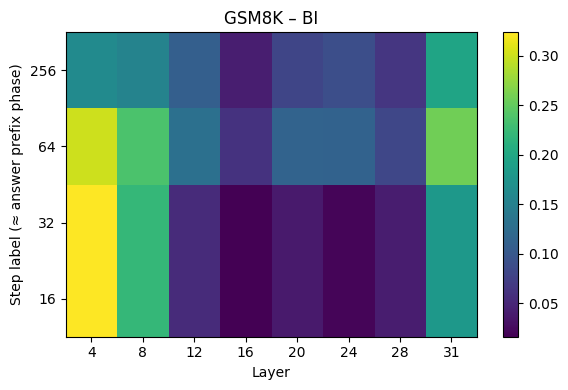

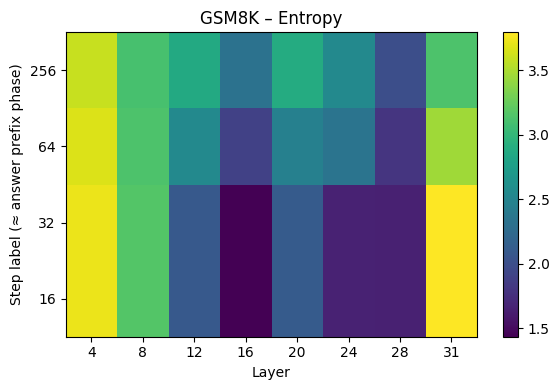

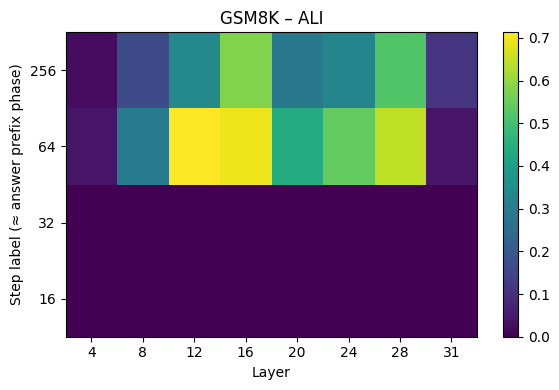

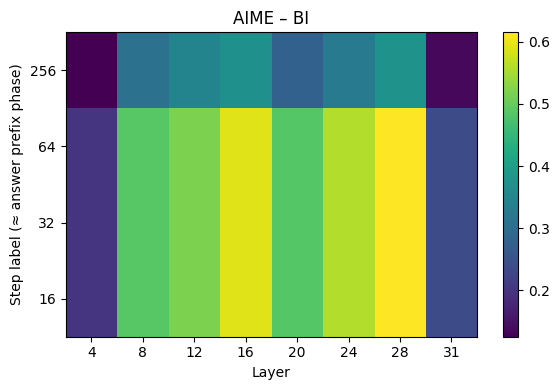

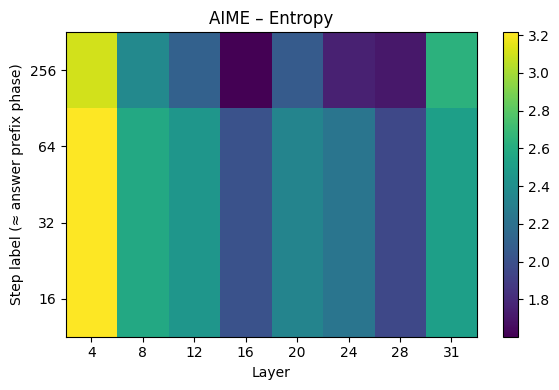

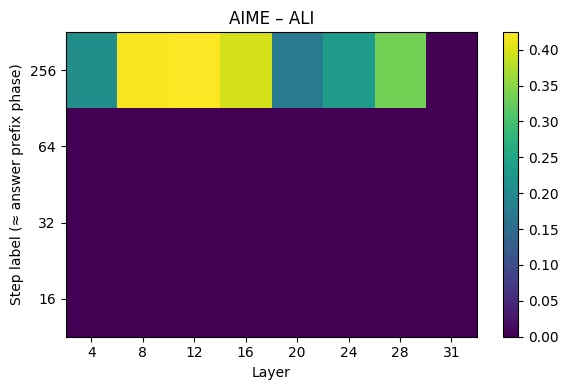

/tmp/ipython-input-1283807170.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


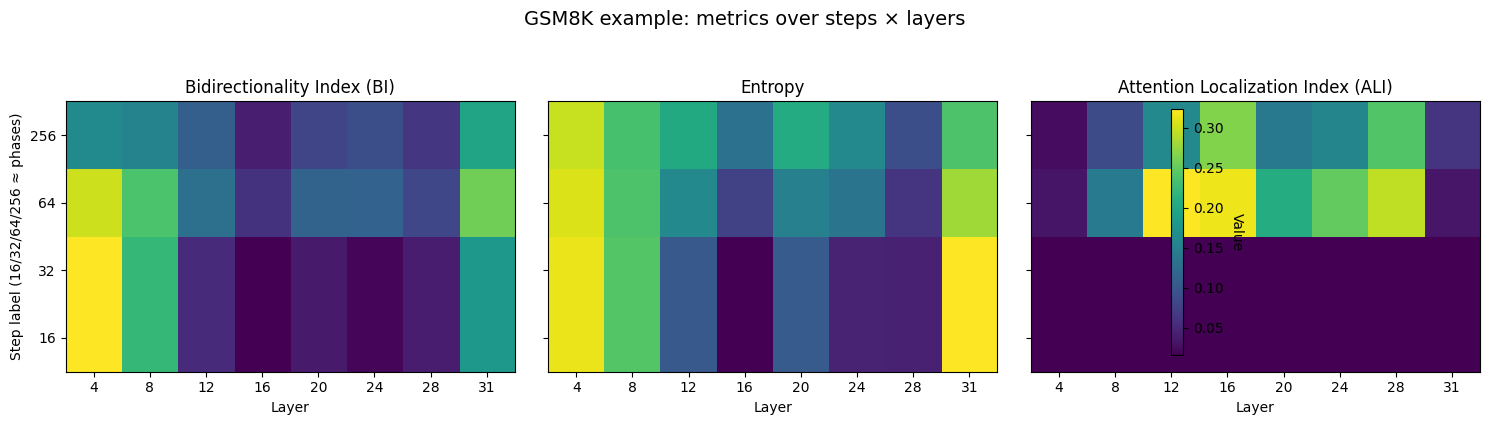

/tmp/ipython-input-1283807170.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


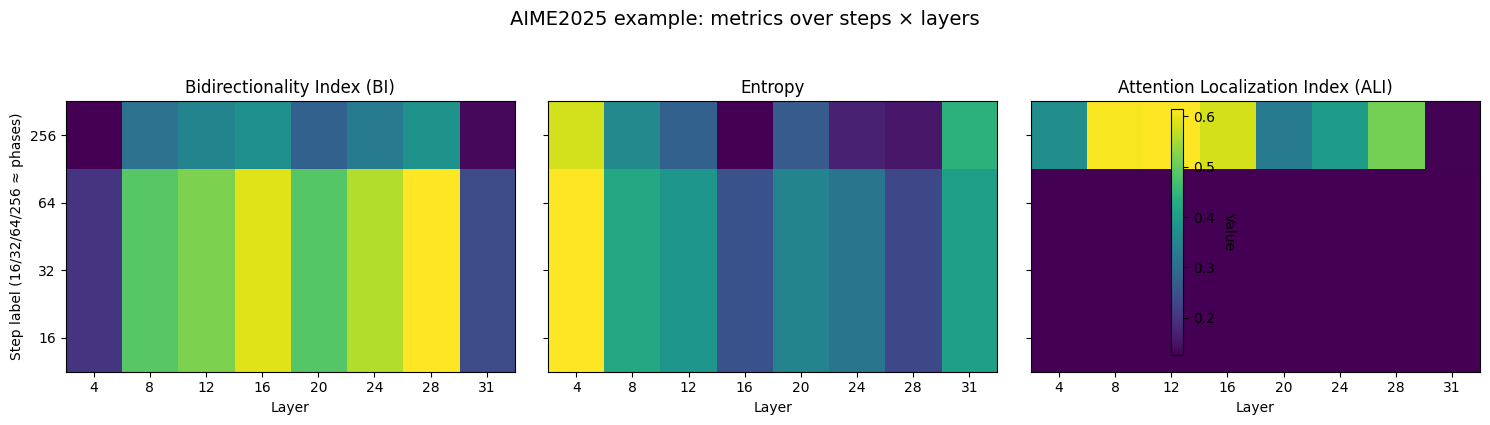

In [ ]:
# Single-metric heatmaps (if you want separate figures)
plot_step_layer_heatmap(bi_gsm,  steps_list, layers_list, "GSM8K – BI")
plot_step_layer_heatmap(ent_gsm, steps_list, layers_list, "GSM8K – Entropy")
plot_step_layer_heatmap(ali_gsm, steps_list, layers_list, "GSM8K – ALI")

plot_step_layer_heatmap(bi_aime,  steps_list, layers_list, "AIME – BI")
plot_step_layer_heatmap(ent_aime, steps_list, layers_list, "AIME – Entropy")
plot_step_layer_heatmap(ali_aime, steps_list, layers_list, "AIME – ALI")

# Or the nicer 3-panel per dataset:
plot_all_metrics_step_layer(bi_gsm, ent_gsm, ali_gsm, steps_list, layers_list, "GSM8K example")
plot_all_metrics_step_layer(bi_aime, ent_aime, ali_aime, steps_list, layers_list, "AIME2025 example")

Word-level attention heatmap (no subword noise)

In [ ]:
def tokens_to_words(tokens):
    """
    Merge subword tokens into whole words using leading-space markers.
    Returns:
      words: list[str]
      spans: list[list[int]] of token indices per word.
    """
    words = []
    spans = []
    current = ""
    current_idxs = []

    for i, tok in enumerate(tokens):
        new_word = False
        clean = tok

        if tok.startswith("Ġ") or tok.startswith("▁"):
            new_word = True
            clean = tok[1:]
        elif tok.startswith("G") and len(tok) > 1 and tok[1].isalpha():
            # crude heuristic for some LLaDA vocab variants
            new_word = True
            clean = tok[1:]

        if new_word or i == 0:
            if current_idxs:
                words.append(current)
                spans.append(current_idxs)
            current = clean
            current_idxs = [i]
        else:
            current += tok
            current_idxs.append(i)

    if current_idxs:
        words.append(current)
        spans.append(current_idxs)

    return words, spans


def word_level_attention(attn_mean, spans):
    """
    attn_mean: [T, T] (avg over heads)
    spans: list[list[int]]  token indices per word
    Returns:
      W_attn: [W, W]
    """
    if isinstance(attn_mean, torch.Tensor):
        A = attn_mean.to(torch.float32).cpu().numpy()
    else:
        A = np.asarray(attn_mean)

    W = len(spans)
    W_attn = np.zeros((W, W), dtype=float)
    for i, idx_i in enumerate(spans):
        for j, idx_j in enumerate(spans):
            W_attn[i, j] = A[np.ix_(idx_i, idx_j)].mean()
    return W_attn

Cell E – plot word-level heatmap for a layer

In [ ]:
def plot_word_level_for_layer(meta, model, layer_idx,
                              topk_cols=20, dataset_name="", title_suffix=""):
    """
    Word-level attention heatmap for a given layer.
    Columns = top-K words by total incoming mass.
    """
    full_ids = meta["full_ids"]
    tokens   = meta["tokens"]

    attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)  # [1,H,T,T]
    attn_mean  = attn_layer.mean(dim=1)[0]  # [T,T]

    words, spans = tokens_to_words(tokens)
    W_attn = word_level_attention(attn_mean, spans)  # [W,W]

    # pick top-K columns by incoming mass
    col_scores = W_attn.sum(axis=0)
    top_idx = np.argsort(-col_scores)[:topk_cols]
    top_idx = np.sort(top_idx)

    sub = W_attn[:, top_idx]
    col_labels = [words[j] for j in top_idx]

    plt.figure(figsize=(max(6, 0.4*len(col_labels)), max(4, 0.4*len(words))))
    plt.imshow(sub, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(words)), words, fontsize=8)
    title = f"{dataset_name} layer {layer_idx} word-level attention"
    if title_suffix:
        title += f" ({title_suffix})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

Cell F – example calls (GSM8K & AIME, layer 16)

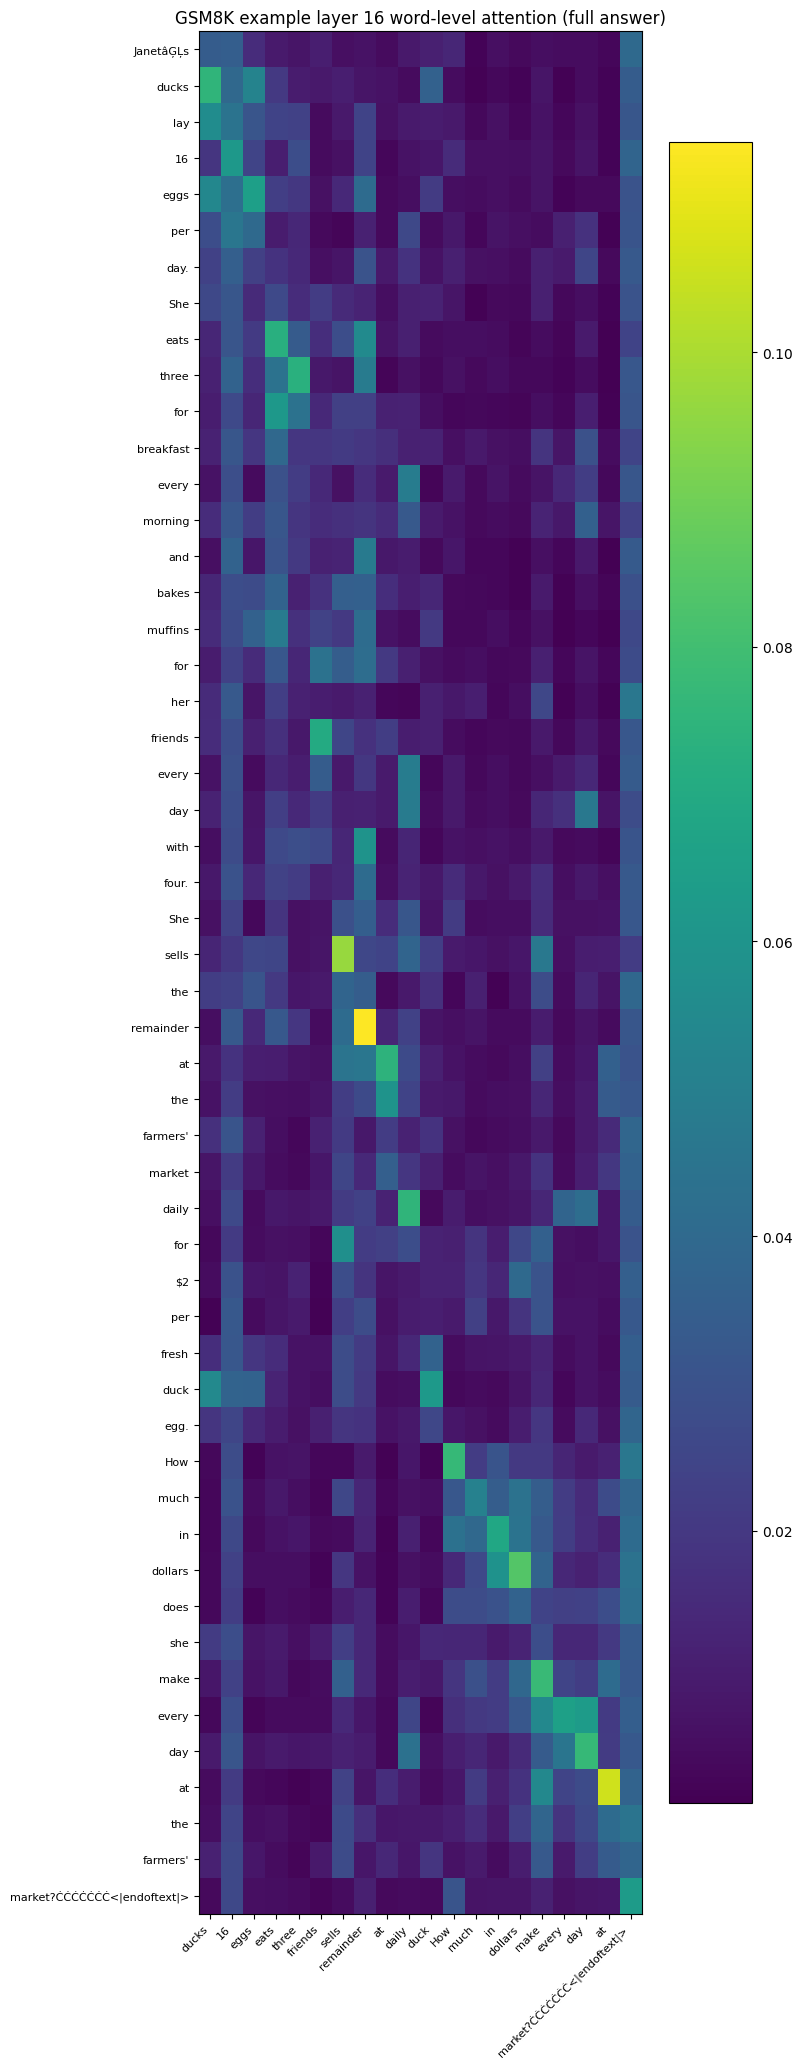

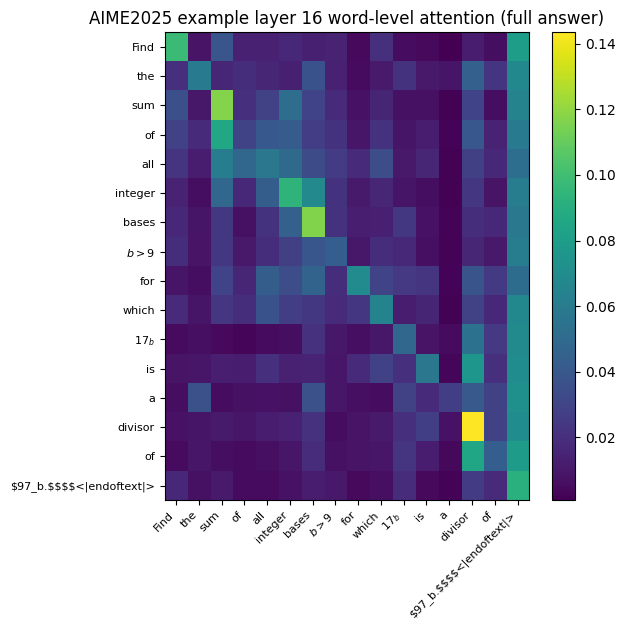

In [ ]:
# GSM8K word-level attention at layer 16
plot_word_level_for_layer(
    meta_gsm,
    mdl_llada,
    layer_idx=16,
    topk_cols=20,
    dataset_name="GSM8K example",
    title_suffix="full answer"
)

# AIME word-level attention at layer 16
plot_word_level_for_layer(
    meta_aime,
    mdl_llada,
    layer_idx=16,
    topk_cols=20,
    dataset_name="AIME2025 example",
    title_suffix="full answer"
)

New function: answer-only word-level attention

In [ ]:
def plot_word_level_answer_only(meta, model, layer_idx,
                                topk_cols=20, dataset_name="", title_suffix=""):
    """
    Word-level attention focused on the GENERATION:

    - Rows  = answer words only (words whose tokens lie in the answer segment).
    - Cols  = top-K words (question or answer) that receive the most attention
              from those answer words.

    meta must come from collect_step_layer_metrics_for_example and contain:
      - full_ids
      - tokens
      - prompt_len
      - gen_len_full
    """
    full_ids    = meta["full_ids"]
    tokens      = meta["tokens"]
    prompt_len  = meta["prompt_len"]
    gen_len_full = meta["gen_len_full"]

    # 1) Get layer attention and average over heads
    attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)  # [1,H,T,T]
    attn_mean  = attn_layer.mean(dim=1)[0]  # [T,T]

    # 2) Build words and spans over the whole sequence
    words, spans = tokens_to_words(tokens)
    W_attn = word_level_attention(attn_mean, spans)  # [W,W]

    # 3) Figure out which words belong to the generated answer
    answer_start = prompt_len
    answer_end   = prompt_len + gen_len_full

    answer_word_idx = []
    for wi, span in enumerate(spans):
        # If ANY token in this word lies in the answer token range, treat it as an answer word
        if any(answer_start <= ti < answer_end for ti in span):
            answer_word_idx.append(wi)

    if not answer_word_idx:
        print("No answer words detected; nothing to plot.")
        return

    # Rows = answer words only
    rows = answer_word_idx
    row_labels = [words[i] for i in rows]

    # 4) Columns: top-K words by incoming mass from these answer rows
    col_scores = W_attn[rows, :].sum(axis=0)  # [W]
    top_idx = np.argsort(-col_scores)[:topk_cols]
    top_idx = np.sort(top_idx)

    sub = W_attn[np.ix_(rows, top_idx)]
    col_labels = [words[j] for j in top_idx]

    # 5) Plot
    plt.figure(figsize=(max(6, 0.4*len(col_labels)), max(3, 0.4*len(rows))))
    plt.imshow(sub, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(row_labels)), row_labels, fontsize=8)
    title = f"{dataset_name} layer {layer_idx} – answer words → top-{topk_cols} words"
    if title_suffix:
        title += f" ({title_suffix})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_word_level_answer_only(meta, model, layer_idx,
                                topk_cols=20, dataset_name="", title_suffix=""):
    """
    Word-level attention focused on the GENERATION:

    - Rows  = answer words only (words whose tokens lie in the answer segment).
    - Cols  = top-K words (question or answer) that receive the most attention
              from those answer words.

    meta must come from collect_step_layer_metrics_for_example and contain:
      - full_ids
      - tokens
      - prompt_len
      - gen_len_full
    """
    full_ids    = meta["full_ids"]
    tokens      = meta["tokens"]
    prompt_len  = meta["prompt_len"]
    gen_len_full = meta["gen_len_full"]

    # 1) Get layer attention and average over heads
    attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)  # [1,H,T,T]
    attn_mean  = attn_layer.mean(dim=1)[0]  # [T,T]

    # 2) Build words and spans over the whole sequence
    words, spans = tokens_to_words(tokens)
    W_attn = word_level_attention(attn_mean, spans)  # [W,W]

    # 3) Figure out which words belong to the generated answer
    answer_start = prompt_len
    answer_end   = prompt_len + gen_len_full

    answer_word_idx = []
    for wi, span in enumerate(spans):
        # If ANY token in this word lies in the answer token range, treat it as an answer word
        if any(answer_start <= ti < answer_end for ti in span):
            answer_word_idx.append(wi)

    if not answer_word_idx:
        print("No answer words detected; nothing to plot.")
        return

    # Rows = answer words only
    rows = answer_word_idx
    row_labels = [words[i] for i in rows]

    # 4) Columns: top-K words by incoming mass from these answer rows
    col_scores = W_attn[rows, :].sum(axis=0)  # [W]
    top_idx = np.argsort(-col_scores)[:topk_cols]
    top_idx = np.sort(top_idx)

    sub = W_attn[np.ix_(rows, top_idx)]
    col_labels = [words[j] for j in top_idx]

    # 5) Plot
    plt.figure(figsize=(max(6, 0.4*len(col_labels)), max(3, 0.4*len(rows))))
    plt.imshow(sub, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(row_labels)), row_labels, fontsize=8)
    title = f"{dataset_name} layer {layer_idx} – answer words → top-{topk_cols} words"
    if title_suffix:
        title += f" ({title_suffix})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

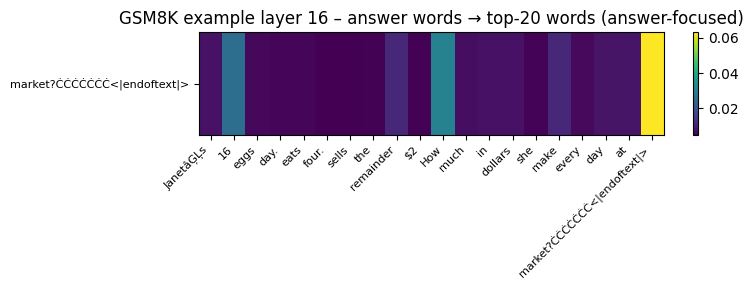

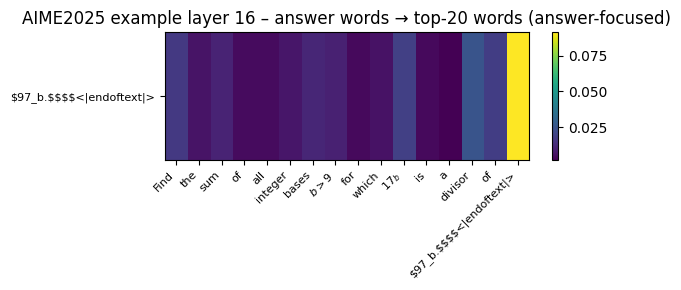

In [ ]:
# GSM8K example, layer 16, answer-focused view
plot_word_level_answer_only(
    meta_gsm,
    mdl_llada,
    layer_idx=16,
    topk_cols=20,
    dataset_name="GSM8K example",
    title_suffix="answer-focused"
)

# AIME example, layer 16, answer-focused view
plot_word_level_answer_only(
    meta_aime,
    mdl_llada,
    layer_idx=16,
    topk_cols=20,
    dataset_name="AIME2025 example",
    title_suffix="answer-focused"
)

## Answer only generation

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Pick a GSM8K example
gsm_idx = 0
q_gsm, a_gsm = extract_qa_from_example("gsm8k_test", ds_gsm[gsm_idx])
print("GSM8K question:\n", q_gsm)

# Encode and generate up to 256 new tokens
enc = tok_llada(q_gsm, return_tensors="pt").to(device)
prompt_len = enc["input_ids"].shape[1]

with torch.no_grad():
    gen_ids = mdl_llada.generate(
        **enc,
        max_new_tokens=256,  # "256 generation length"
        do_sample=False,
        use_cache=False,
    )

full_ids = gen_ids  # [1, T]
gen_len = full_ids.shape[1] - prompt_len
tokens = tok_llada.convert_ids_to_tokens(full_ids[0].tolist())

print(f"prompt_len={prompt_len}, gen_len={gen_len}, total_len={full_ids.shape[1]}")
print("First 50 tokens:\n", tokens[:])

Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


GSM8K question:
 Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
prompt_len=63, gen_len=8, total_len=71
First 50 tokens:
 ['Janet', 'âĢĻs', 'Ġducks', 'Ġlay', 'Ġ', '1', '6', 'Ġeggs', 'Ġper', 'Ġday', '.', 'ĠShe', 'Ġeats', 'Ġthree', 'Ġfor', 'Ġbreakfast', 'Ġevery', 'Ġmorning', 'Ġand', 'Ġb', 'akes', 'Ġmuffins', 'Ġfor', 'Ġher', 'Ġfriends', 'Ġevery', 'Ġday', 'Ġwith', 'Ġfour', '.', 'ĠShe', 'Ġsells', 'Ġthe', 'Ġremainder', 'Ġat', 'Ġthe', 'Ġfarmers', "'", 'Ġmarket', 'Ġdaily', 'Ġfor', 'Ġ$', '2', 'Ġper', 'Ġfresh', 'Ġduck', 'Ġegg', '.', 'ĠHow', 'Ġmuch']


1. Placeholder: diffusion-based generation for one question

In [ ]:
def generate_llada_diffusion(model, tokenizer, question_str,
                             diffusion_steps, max_new_tokens=256, device="cuda"):
    """
    TODO: IMPLEMENT using your d1 diffusion sampler.

    Should:
      - Take a QUESTION string
      - Run LLaDA diffusion sampling with the given `diffusion_steps`
      - Generate up to `max_new_tokens` new tokens
      - Return:
          full_ids: [1, T] tensor with prompt + generated tokens
          prompt_len: int
          gen_len: int
          tokens: list[str] for the full sequence
    """
    # --- Example structure (you must replace this with your actual code) ---

    # 1) Encode prompt
    enc = tokenizer(question_str, return_tensors="pt").to(device)
    prompt_len = enc["input_ids"].shape[1]

    # 2) Call your diffusion sampler
    #    This part is project-specific — adapt from eval/colab_eval.py
    #
    #    Something like:
    #    full_ids = run_diffusion_generate(
    #         model=model,
    #         tokenizer=tokenizer,
    #         input_ids=enc["input_ids"],
    #         attention_mask=enc["attention_mask"],
    #         diffusion_steps=diffusion_steps,
    #         max_new_tokens=max_new_tokens,
    #         device=device,
    #    )
    #
    #    For now, I'll fake it with normal generate (replace this!):
    full_ids = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=False,
    )

    # 3) Build outputs
    gen_len = full_ids.shape[1] - prompt_len
    tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())

    return full_ids, prompt_len, gen_len, tokens

2. Helpers: tokens → words and word-level attention

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def tokens_to_words(tokens):
    """
    Merge subword tokens into whole words using leading-space markers.
    Returns:
      words: list[str]
      spans: list[list[int]] of token indices per word.
    """
    words = []
    spans = []
    current = ""
    current_idxs = []

    for i, tok in enumerate(tokens):
        new_word = False
        clean = tok

        if tok.startswith("Ġ") or tok.startswith("▁"):
            new_word = True
            clean = tok[1:]
        elif tok.startswith("G") and len(tok) > 1 and tok[1].isalpha():
            # crude heuristic for some vocab variants
            new_word = True
            clean = tok[1:]

        if new_word or i == 0:
            if current_idxs:
                words.append(current)
                spans.append(current_idxs)
            current = clean
            current_idxs = [i]
        else:
            current += tok
            current_idxs.append(i)

    if current_idxs:
        words.append(current)
        spans.append(current_idxs)

    return words, spans


def word_level_attention(attn_mean, spans):
    """
    attn_mean: [T, T] (avg over heads)
    spans: list[list[int]]  token indices per word
    Returns:
      W_attn: [W, W]
    """
    if isinstance(attn_mean, torch.Tensor):
        A = attn_mean.to(torch.float32).cpu().numpy()
    else:
        A = np.asarray(attn_mean)

    W = len(spans)
    W_attn = np.zeros((W, W), dtype=float)
    for i, idx_i in enumerate(spans):
        for j, idx_j in enumerate(spans):
            W_attn[i, j] = A[np.ix_(idx_i, idx_j)].mean()
    return W_attn

3. Build generation-only word index list

In [ ]:
def get_generated_word_indices(tokens, prompt_len, gen_len):
    """
    Given full tokens and the prompt/gen split:
      - tokens: list of token strings for full sequence
      - prompt_len: number of prompt tokens
      - gen_len: number of generated tokens

    Returns:
      words: list[str]
      spans: list[list[int]] per word (whole sequence)
      gen_word_idxs: sorted list[int] – indices of words that belong to the generation
    """
    words, spans = tokens_to_words(tokens)

    # Map token index -> word index
    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    answer_start = prompt_len
    answer_end   = prompt_len + gen_len

    gen_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(answer_start, answer_end)
        if ti in token_to_word
    })

    return words, spans, gen_word_idxs

4. Loop over diffusion steps and collect generation self-attention per layer

In [ ]:
from objective3.probes import get_llada_layer_attn  # you already used this earlier

# 1) Pick GSM8K question
gsm_idx = 0
q_gsm, a_gsm = extract_qa_from_example("gsm8k_test", ds_gsm[gsm_idx])
print("GSM8K question:\n", q_gsm)

# 2) Define steps and layer to probe
diff_steps_list = [16, 32, 128, 256]
layer_idx = 16   # you can change this to 4/24/31 later

# 3) Collect word-level generation self-attention per step
gen_word_attn = {}   # step -> (gen_words, submatrix)

for steps in diff_steps_list:
    print(f"\n[diffusion_steps={steps}] generating...")
    full_ids, prompt_len, gen_len, tokens = generate_llada_diffusion(
        mdl_llada,
        tok_llada,
        q_gsm,
        diffusion_steps=steps,
        max_new_tokens=256,
        device=device,
    )
    print(f"  prompt_len={prompt_len}, gen_len={gen_len}, total_len={full_ids.shape[1]}")

    # Get words & which words belong to generation
    words, spans, gen_word_idxs = get_generated_word_indices(tokens, prompt_len, gen_len)
    print(f"  #generated words: {len(gen_word_idxs)}")

    # Get layer attention: [1,H,T,T] -> avg heads -> [T,T]
    with torch.no_grad():
        attn_layer = get_llada_layer_attn(mdl_llada, full_ids, layer_idx=layer_idx)
    attn_mean = attn_layer.mean(dim=1)[0]  # [T,T]

    # Word-level [W,W]
    W_attn = word_level_attention(attn_mean, spans)

    # Restrict to generation words only (rows & cols)
    idx = np.array(gen_word_idxs)
    sub = W_attn[np.ix_(idx, idx)]  # [W_gen, W_gen]
    gen_words = [words[i] for i in idx]

    gen_word_attn[steps] = (gen_words, sub)

Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


GSM8K question:
 Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

[diffusion_steps=16] generating...


Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


  prompt_len=63, gen_len=8, total_len=71
  #generated words: 1

[diffusion_steps=32] generating...


Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


  prompt_len=63, gen_len=8, total_len=71
  #generated words: 1

[diffusion_steps=128] generating...


Setting `pad_token_id` to `eos_token_id`:126081 for open-end generation.


  prompt_len=63, gen_len=8, total_len=71
  #generated words: 1

[diffusion_steps=256] generating...
  prompt_len=63, gen_len=8, total_len=71
  #generated words: 1


## Generation

In [ ]:
device = "cuda"
from transformers import AutoTokenizer, AutoModelForCausalLM

tok_llada = AutoTokenizer.from_pretrained("GSAI-ML/LLaDA-8B-Instruct", trust_remote_code=True)
mdl_llada = AutoModelForCausalLM.from_pretrained(
    "GSAI-ML/LLaDA-8B-Instruct",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16
).to(device)

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
import torch
import random
import re
from datasets import load_dataset

# ---------- 1. System prompt (same as in your GSM8KDataset) ----------

GSM_SYSTEM_PROMPT = """You are a math expert. You will be given a question to solve. Solve it step by step. Wrap the final answer in a \\boxed{}.
Respond in the following format:
<reasoning>
Your reasoning here
</reasoning>
<answer>
\\boxed{...}
</answer>"""

# ---------- 2. Answer extractor (approx Parser.extract_answer_gsm8k) ----------

def extract_answer_gsm8k(raw_answer: str) -> str:
    """
    Approximate Parser.extract_answer_gsm8k:
    GSM8K answers typically end with '#### 18'.
    We extract the part after '####'.
    """
    m = re.search(r"####\s*(.*)", raw_answer)
    if m:
        return m.group(1).strip()
    return raw_answer.strip()

# ---------- 3. Few-shot helper (only used if NUM_FEW_SHOT > 0) ----------

def build_few_shot_prompt(train_ds, num_examples: int) -> str:
    """
    Recreates GSM8KDataset.create_few_shot_prompt:
      "Question: ...\nAnswer:\n<full answer text>"
    joined with blank lines.
    """
    if num_examples <= 0:
        return ""

    indices = random.sample(range(len(train_ds)), num_examples)
    formatted = []
    for idx in indices:
        ex = train_ds[idx]
        q = ex["question"]
        a = ex["answer"]
        formatted.append(f"Question: {q}\nAnswer:\n{a}")
    return "\n\n".join(formatted)

# ---------- 4. Load GSM8K test set & (optionally) train for few-shot ----------

gsm_test = load_dataset("openai/gsm8k", "main", split="test")
# if you want few-shot examples, uncomment:
# gsm_train = load_dataset("openai/gsm8k", "main", split="train")

NUM_FEW_SHOT = 0        # set > 0 if you really want FS like original code
ADD_REASONING = True    # same as add_reasoning=True in GSM8KDataset

few_shot_prompt = ""    # default no few-shot
# if NUM_FEW_SHOT > 0:
#     few_shot_prompt = build_few_shot_prompt(gsm_train, NUM_FEW_SHOT)

# ---------- 5. Pick one example and build the prompt string ----------

idx = 0  # change this to select another test example
raw_q = gsm_test[idx]["question"]
raw_a = gsm_test[idx]["answer"]
clean_a = extract_answer_gsm8k(raw_a)

print("Question:\n", raw_q)
print("\nRaw answer (dataset):\n", raw_a)
print("\nParsed final answer:\n", clean_a)

if NUM_FEW_SHOT > 0:
    prompt_body = f"{few_shot_prompt}\n\nQuestion: {raw_q}\nAnswer:\n"
else:
    prompt_body = raw_q

# This matches GSM8KDataset.create_prompt: system prompt + user question
messages = [
    {
        "role": "user",
        "content": GSM_SYSTEM_PROMPT + "\n\n" + prompt_body,
    }
]

# Apply chat template exactly like in your dataset
tok_llada.padding_side = "left"
chat_prompt = tok_llada.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

if ADD_REASONING:
    full_prompt_str = chat_prompt + "<reasoning>"
else:
    full_prompt_str = chat_prompt

print("\nPrompt string (truncated):\n", full_prompt_str[:600], "...\n")

# ---------- 6. Tokenize to get prompt_ids and prompt_len ----------

enc = tok_llada(
    full_prompt_str,
    return_tensors="pt",
    padding="longest",
)

prompt_ids = enc["input_ids"].to(device)  # [1, T_prompt]
prompt_len = prompt_ids.shape[1]

print("prompt_ids shape:", prompt_ids.shape)
print("prompt_len:", prompt_len)

Question:
 Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Raw answer (dataset):
 Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18

Parsed final answer:
 18

Prompt string (truncated):
 <|startoftext|><|start_header_id|>user<|end_header_id|>

You are a math expert. You will be given a question to solve. Solve it step by step. Wrap the final answer in a \boxed{}. 
Respond in the following format:
<reasoning>
Your reasoning here
</reasoning>
<answer>
\boxed{...}
</answer>

Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck e

## gsm8k

Loading tokenizer & model...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Diffusion (len=256, steps=128):   0%|          | 0/8 [00:00<?, ?it/s]

  Generated token length: 256
  Generated text (first 300 chars):
 
To determine how much Janet makes every day at the farmers' market, we need to follow these steps:

1. Calculate the total number of eggs laid by Janet's ducks per day.
2. Subtract the number of eggs she eats for breakfast and bakes for her friends from the total number of eggs laid.
3. Multiply th ...


[diffusion_steps=256] generating (gen_length=256)...


Diffusion (len=256, steps=256):   0%|          | 0/8 [00:00<?, ?it/s]

  Generated token length: 256
  Generated text (first 300 chars):
 
To determine how much Janet makes every day at the farmers' market, we need to follow these steps:

1. Calculate the total number of eggs laid by Janet's ducks per day.
2. Subtract the number of eggs she eats for breakfast and bakes for her friends from the total number of eggs laid.
3. Determine t ...

[attn] steps=16: computing attention for layer 16...
  #generated words: 231
[attn] steps=32: computing attention for layer 16...
  #generated words: 178
[attn] steps=128: computing attention for layer 16...
  #generated words: 152
[attn] steps=256: computing attention for layer 16...
  #generated words: 154


/tmp/ipython-input-1901219818.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipython-input-1901219818.py:342: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


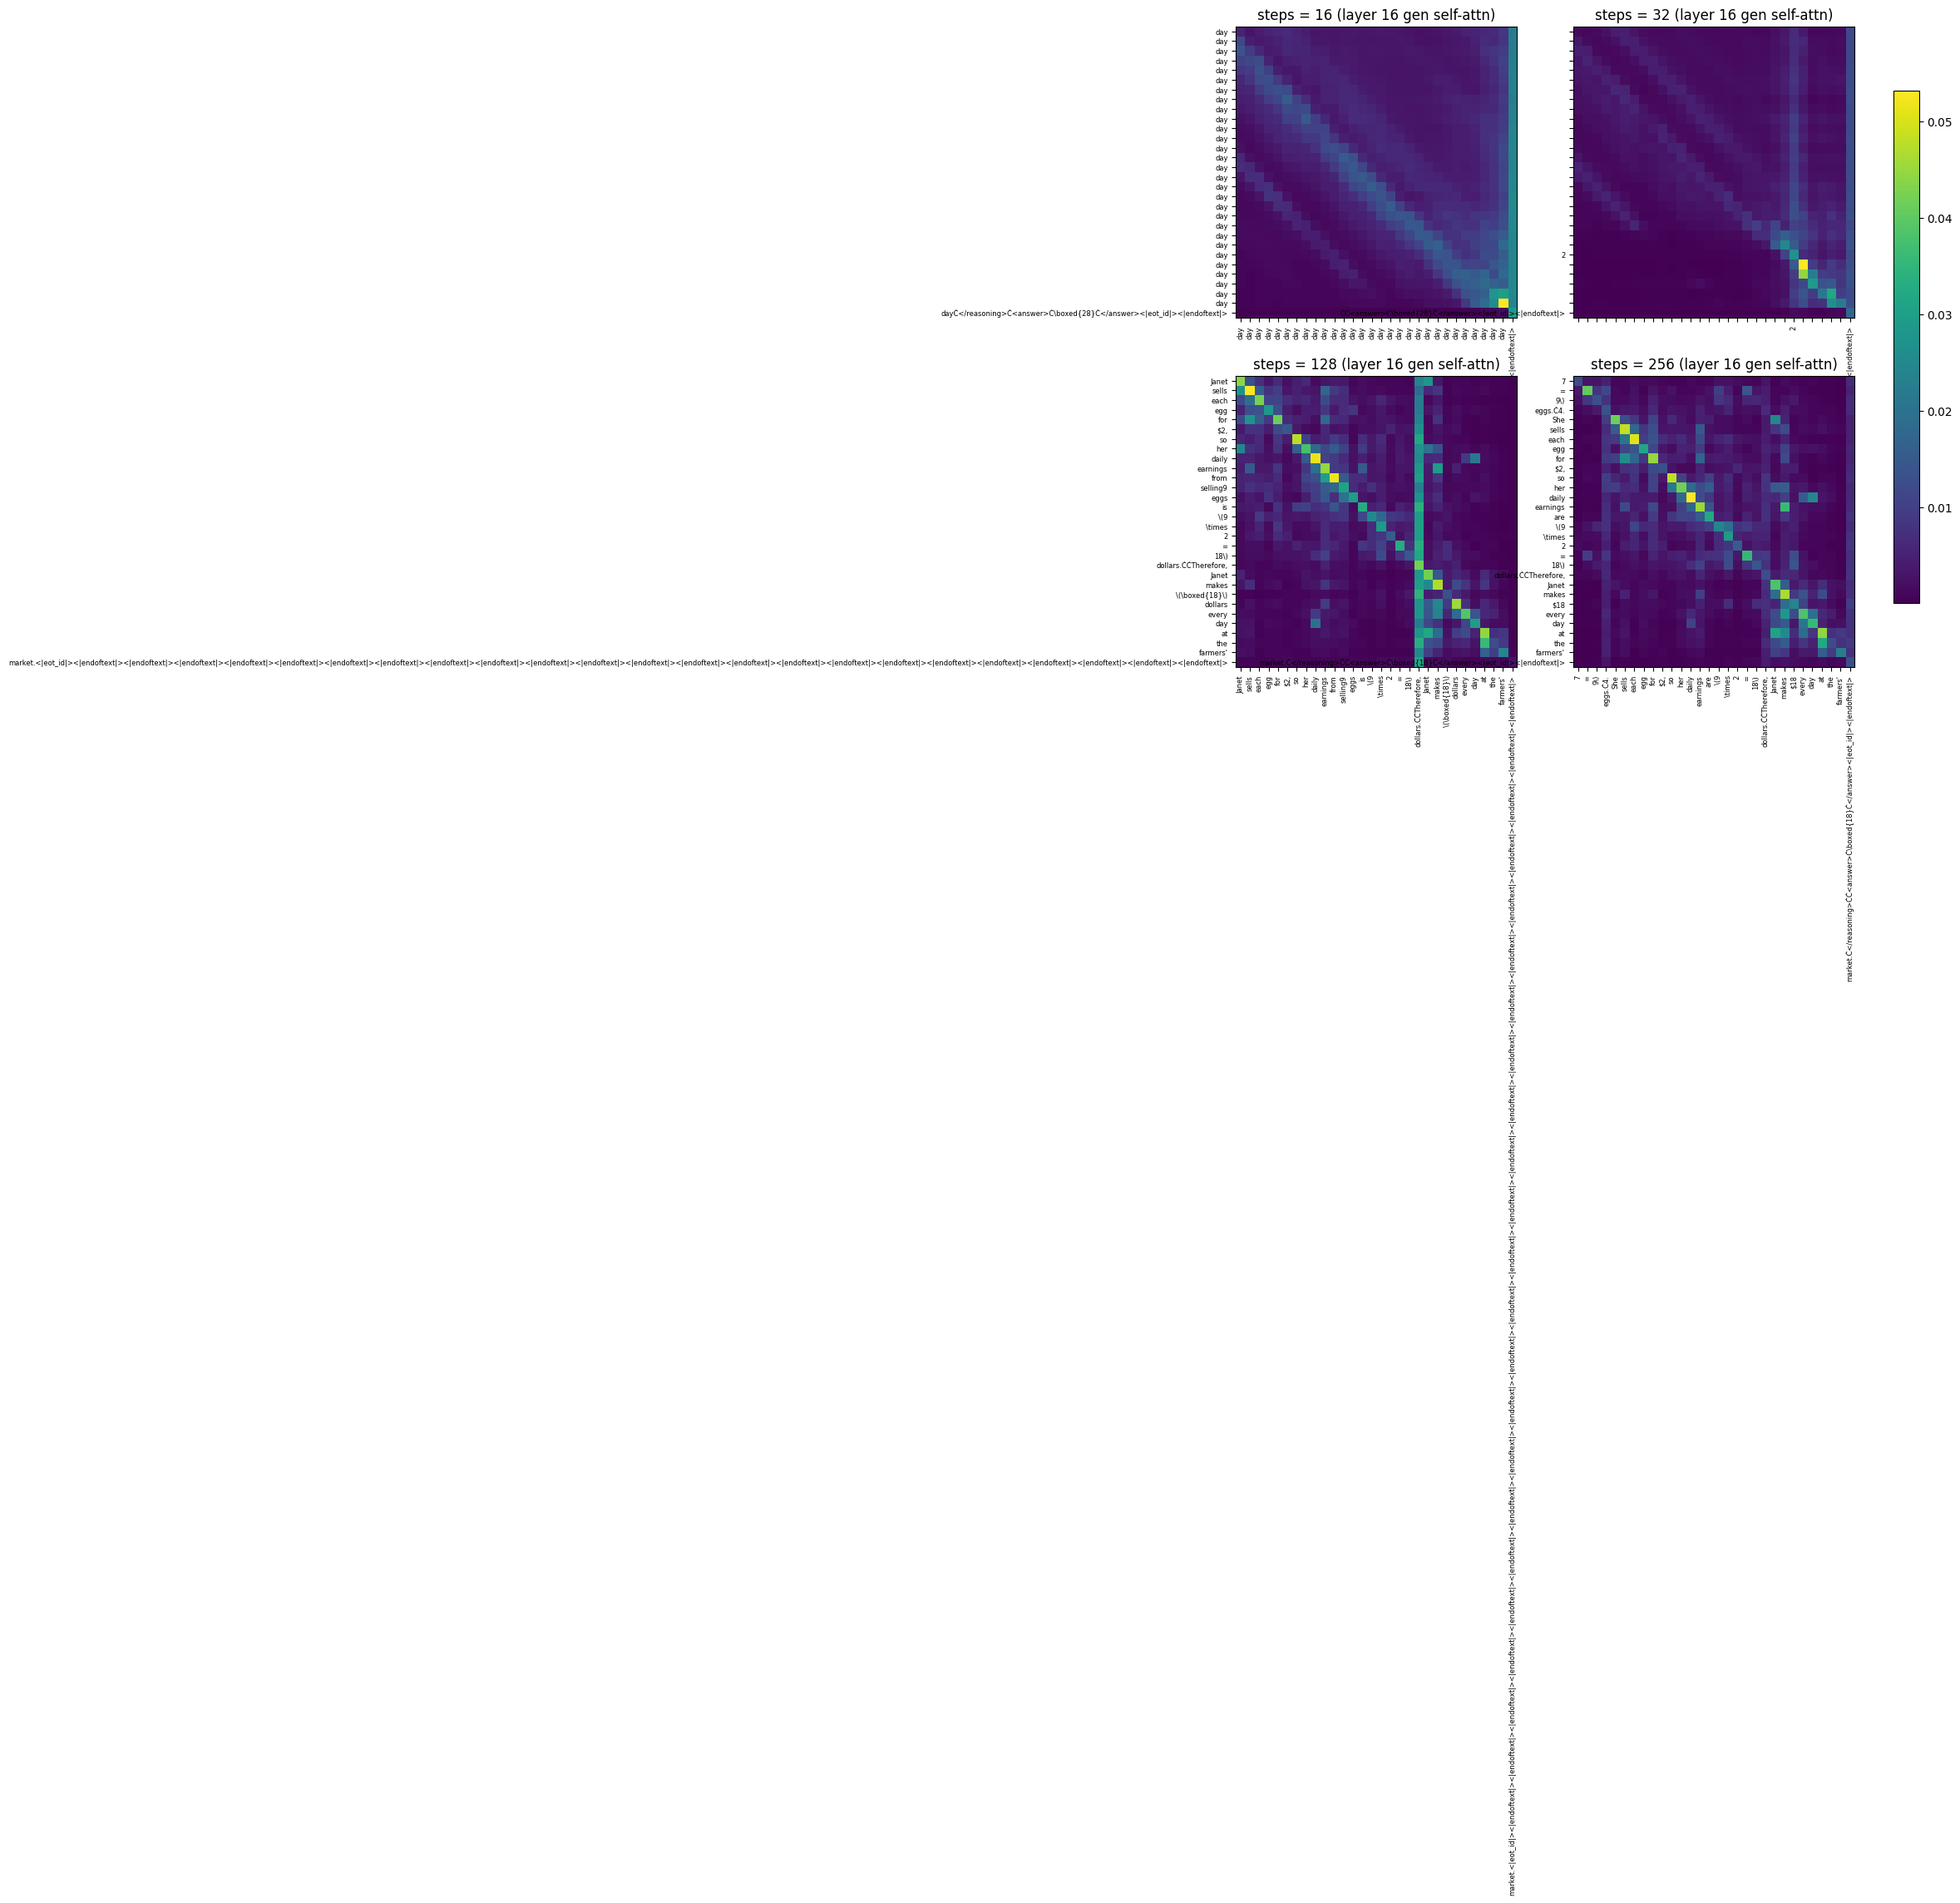

In [ ]:
import re
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

# If your repo root isn't in sys.path, add it:
import os, sys
REPO_ROOT = "/content/NLP_Project_d1_reasoning"
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

from objective3.probes import get_llada_layer_attn  # your existing helper

# ===================== CONFIG =====================

MODEL_NAME = "GSAI-ML/LLaDA-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Pick which GSM8K example and which layer to visualize
example_idx = 0          # <-- change this index to pick a different GSM8K test example
layer_idx   = 16         # layer to probe (you can try 4, 16, 24, 31)
steps_list  = [16, 32, 128, 256]
gen_length  = 256
block_length = 32        # as in your eval code
max_gen_words_to_show = 30  # truncate heatmap to last N generated words for readability

# ===================== 1. GSM8K prompt construction =====================

GSM_SYSTEM_PROMPT = """You are a math expert. You will be given a question to solve. Solve it step by step. Wrap the final answer in a \\boxed{}.
Respond in the following format:
<reasoning>
Your reasoning here
</reasoning>
<answer>
\\boxed{...}
</answer>"""

def extract_answer_gsm8k(raw_answer: str) -> str:
    """
    Approximate Parser.extract_answer_gsm8k:
    GSM8K answers end with something like '#### 18'.
    We extract the part after '####'.
    """
    m = re.search(r"####\s*(.*)", raw_answer)
    if m:
        return m.group(1).strip()
    return raw_answer.strip()

def build_gsm8k_prompt(question: str, tokenizer) -> str:
    """
    Build a prompt similar to your GSM8KDataset:
      - system prompt + question
      - wrapped in chat template
      - with <reasoning> appended at the end.
    """
    messages = [
        {
            "role": "user",
            "content": GSM_SYSTEM_PROMPT + "\n\n" + question,
        }
    ]
    chat_prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )
    full_prompt_str = chat_prompt + "<reasoning>"
    return full_prompt_str

# ===================== 2. Diffusion-style generation (from generate.py) =====================

def gumbel_max_sample(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    Correct Gumbel-Max sampling:
      argmax( (logits / T) + Gumbel(0,1) )
    If temperature == 0, returns greedy argmax(logits).
    """
    if temperature is None or temperature <= 0.0:
        return logits.argmax(dim=-1)

    logits = logits.float() / max(1e-6, float(temperature))
    u = torch.rand_like(logits, dtype=torch.float32).clamp_(1e-6, 1.0 - 1e-6)
    g = -torch.log(-torch.log(u))
    return (logits + g).argmax(dim=-1)

def apply_top_k_top_p(logits: torch.Tensor, top_k: int = 0, top_p: float = 0.0) -> torch.Tensor:
    """
    Filter logits with top-k and/or top-p. Returns filtered logits (float32).
    """
    logits = logits.float()
    if top_k and top_k > 0:
        v, _ = torch.topk(logits, top_k, dim=-1)
        cut = v[..., -1, None]
        logits = torch.where(logits < cut, torch.full_like(logits, -float("inf")), logits)

    if top_p and top_p > 0.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
        probs = torch.softmax(sorted_logits, dim=-1)
        cumprobs = probs.cumsum(dim=-1)
        cutoff = cumprobs > top_p
        cutoff[..., 0] = False
        sorted_logits[cutoff] = -float("inf")
        logits = torch.full_like(logits, -float("inf"))
        logits.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)

    return logits

def repetition_penalize_logits(logits: torch.Tensor, seq: torch.Tensor, penalty: float = 1.0) -> torch.Tensor:
    """
    Very light repetition penalty: >1.0 discourages re-using tokens already in seq.
    Implemented by dividing logits of seen tokens by penalty.
    """
    if penalty is None or penalty <= 1.0:
        return logits
    logits = logits.float()
    B, T = seq.shape
    V = logits.size(-1)
    seen = torch.zeros((B, V), device=seq.device, dtype=torch.bool)
    seen.scatter_(1, seq, True)
    seen = seen.unsqueeze(1).expand(-1, logits.size(1), -1)  # [B, T, V]
    logits = torch.where(seen, logits / penalty, logits)
    return logits

@torch.no_grad()
def diffusion_generate(
    model,
    prompt_ids: torch.Tensor,
    tokenizer,
    steps: int = 64,
    gen_length: int = 128,
    block_length: int = 32,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    remasking: str = "low_confidence",
    mask_id: int = 126336,  # LLaDA mask token id
    top_k: int = 0,
    top_p: float = 0.0,
    rep_penalty: float = 1.0,
):
    """
    Masked diffusion-style generation (blockwise), same logic as your generate.py:
      - Start with gen window masked with mask_id
      - Iteratively replace most-confident masked tokens
    """
    device = next(model.parameters()).device
    B = prompt_ids.shape[0]
    T_prompt = prompt_ids.shape[1]

    # x: [B, T_prompt + gen_length], init gen window to mask_id
    x = torch.full((B, T_prompt + gen_length), mask_id, dtype=torch.long, device=device)
    x[:, :T_prompt] = prompt_ids.clone()

    prompt_index = x != mask_id
    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length
    steps_per_block = max(1, steps // num_blocks)

    for b in tqdm(range(num_blocks), desc=f"Diffusion (len={gen_length}, steps={steps})"):
        start_idx = T_prompt + b * block_length
        end_idx   = T_prompt + (b + 1) * block_length

        # how many tokens to reveal each inner step per sequence
        block_mask_index = x[:, start_idx:end_idx] == mask_id
        mask_num = block_mask_index.sum(dim=1, keepdim=True)  # [B,1]
        base = mask_num // steps_per_block
        rem  = mask_num %  steps_per_block
        num_transfer_tokens = base.expand(-1, steps_per_block).clone()
        if (rem > 0).any():
            idx = torch.arange(steps_per_block, device=device).unsqueeze(0)
            add = (idx < rem).to(num_transfer_tokens.dtype)
            num_transfer_tokens += add

        for i in range(steps_per_block):
            mask_index = x == mask_id  # [B, T_prompt + gen_length]

            # classifier-free guidance (two passes in one forward)
            if cfg_scale and cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                outputs = model(x_)
                logits, un_logits = torch.chunk(outputs.logits, 2, dim=0)
                logits = (un_logits + (cfg_scale + 1.0) * (logits - un_logits)).float()
            else:
                outputs = model(x)
                logits = outputs.logits.float()  # [B, T, V]

            # repetition penalty
            logits = repetition_penalize_logits(logits, x, penalty=rep_penalty)
            # top-k / top-p
            logits = apply_top_k_top_p(logits, top_k=top_k, top_p=top_p)
            # sample ids
            x0 = gumbel_max_sample(logits, temperature=temperature)  # [B, T]

            # confidence scores
            if remasking == "low_confidence":
                smx = torch.softmax(logits, dim=-1)
                x0_p = torch.gather(smx, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)  # [B, T]
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float32)
            else:
                raise NotImplementedError(remasking)

            # do not transfer outside current block
            x0_p[:, end_idx:] = -float("inf")
            # only allow masked positions to be transferred
            x0 = torch.where(mask_index, x0, x)
            conf = torch.where(mask_index, x0_p, torch.full_like(x0_p, -float("inf")))

            # for each sequence, pick top-k masked positions
            for j in range(B):
                k = int(num_transfer_tokens[j, i].item())
                if k <= 0:
                    continue
                _, idxs = torch.topk(conf[j], k=k, dim=-1)
                x[j, idxs] = x0[j, idxs]

    return x  # [B, T_prompt + gen_length]

# ===================== 3. Token → word mapping + attention aggregation =====================

def tokens_to_words(tokens):
    """
    Merge subword tokens into whole words using leading-space markers.
    Returns:
      words: list[str]
      spans: list[list[int]] of token indices per word.
    """
    words = []
    spans = []
    current = ""
    current_idxs = []

    for i, tok in enumerate(tokens):
        new_word = False
        clean = tok

        if tok.startswith("Ġ") or tok.startswith("▁"):
            new_word = True
            clean = tok[1:]
        elif tok.startswith("G") and len(tok) > 1 and tok[1].isalpha():
            # crude heuristic for some vocab variants
            new_word = True
            clean = tok[1:]

        if new_word or i == 0:
            if current_idxs:
                words.append(current)
                spans.append(current_idxs)
            current = clean
            current_idxs = [i]
        else:
            current += tok
            current_idxs.append(i)

    if current_idxs:
        words.append(current)
        spans.append(current_idxs)

    return words, spans

def word_level_attention(attn_mean, spans):
    """
    attn_mean: [T, T] (avg over heads)
    spans: list[list[int]] token indices per word
    Returns:
      W_attn: [W, W]
    """
    if isinstance(attn_mean, torch.Tensor):
        A = attn_mean.to(torch.float32).cpu().numpy()
    else:
        A = np.asarray(attn_mean)

    W = len(spans)
    W_attn = np.zeros((W, W), dtype=float)
    for i, idx_i in enumerate(spans):
        for j, idx_j in enumerate(spans):
            W_attn[i, j] = A[np.ix_(idx_i, idx_j)].mean()
    return W_attn

def get_generated_word_indices(tokens, prompt_len, gen_len):
    """
    Given full tokens and prompt/gen split:
      - tokens: list[str] for full sequence
      - prompt_len: #prompt tokens
      - gen_len: #generated tokens
    Returns:
      words, spans, gen_word_idxs (indices of words that belong to generation)
    """
    words, spans = tokens_to_words(tokens)

    # Map token index -> word index
    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    answer_start = prompt_len
    answer_end   = prompt_len + gen_len

    gen_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(answer_start, answer_end)
        if ti in token_to_word
    })

    return words, spans, gen_word_idxs

def plot_generation_self_attention_grid(gen_word_attn, diff_steps_list,
                                        layer_idx,
                                        max_gen_words_to_show=30,
                                        figsize=(12, 10)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, steps in zip(axes, diff_steps_list):
        gen_words, sub = gen_word_attn[steps]

        if len(gen_words) > max_gen_words_to_show:
            start = len(gen_words) - max_gen_words_to_show
            gen_words_plot = gen_words[start:]
            sub_plot = sub[start:, start:]
        else:
            gen_words_plot = gen_words
            sub_plot = sub

        im = ax.imshow(sub_plot, aspect="auto")
        ax.set_title(f"steps = {steps} (layer {layer_idx} gen self-attn)")
        ax.set_xticks(range(len(gen_words_plot)))
        ax.set_xticklabels(gen_words_plot, rotation=90, fontsize=6)
        ax.set_yticks(range(len(gen_words_plot)))
        ax.set_yticklabels(gen_words_plot, fontsize=6)

    fig.colorbar(im, ax=axes.tolist(), shrink=0.8)
    plt.tight_layout()
    plt.show()

# ===================== 4. Load model, dataset, build prompt =====================

print("Loading tokenizer & model...")
tok_llada = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
mdl_llada = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
).to(DEVICE)
mdl_llada.eval()

print("Loading GSM8K test split...")
gsm_test = load_dataset("openai/gsm8k", "main", split="test")

raw_q = gsm_test[example_idx]["question"]
raw_a = gsm_test[example_idx]["answer"]
clean_a = extract_answer_gsm8k(raw_a)

print("\n=== GSM8K example index", example_idx, "===")
print("Question:\n", raw_q)
print("\nRaw answer (dataset):\n", raw_a)
print("\nParsed final answer:\n", clean_a)

prompt_str = build_gsm8k_prompt(raw_q, tok_llada)
print("\nPrompt string (truncated):\n", prompt_str[:600], "...\n")

tok_llada.padding_side = "left"
enc = tok_llada(
    prompt_str,
    return_tensors="pt",
    padding="longest",
)
prompt_ids = enc["input_ids"].to(DEVICE)
prompt_len = prompt_ids.shape[1]
print("prompt_ids shape:", prompt_ids.shape)
print("prompt_len:", prompt_len)

# ===================== 5. Generate for each diffusion step & collect attention =====================

generations = {}
for steps in steps_list:
    print(f"\n[diffusion_steps={steps}] generating (gen_length={gen_length})...")
    x = diffusion_generate(
        mdl_llada,
        prompt_ids,
        tok_llada,
        steps=steps,
        gen_length=gen_length,
        block_length=block_length,
        temperature=0.0,
        cfg_scale=0.0,
        remasking="low_confidence",
        top_k=0,
        top_p=0.0,
        rep_penalty=1.0,
    )

    full_ids = x  # [1, T_prompt + gen_length]
    gen_ids = full_ids[0, prompt_len:]
    gen_text = tok_llada.decode(gen_ids, skip_special_tokens=True)

    tokens = tok_llada.convert_ids_to_tokens(full_ids[0].tolist())
    print(f"  Generated token length: {gen_ids.shape[0]}")
    print("  Generated text (first 300 chars):\n", gen_text[:300], "...\n")

    generations[steps] = {
        "full_ids": full_ids,
        "gen_ids": gen_ids,
        "tokens": tokens,
    }

# Now compute generation self-attention per step for the chosen layer
gen_word_attn = {}

for steps in steps_list:
    data = generations[steps]
    full_ids = data["full_ids"]
    tokens   = data["tokens"]
    gen_len  = gen_length

    print(f"[attn] steps={steps}: computing attention for layer {layer_idx}...")
    words, spans, gen_word_idxs = get_generated_word_indices(tokens, prompt_len, gen_len)
    print("  #generated words:", len(gen_word_idxs))

    with torch.no_grad():
        attn_layer = get_llada_layer_attn(mdl_llada, full_ids, layer_idx=layer_idx)
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]

    W_attn = word_level_attention(attn_mean, spans)
    idx = np.array(gen_word_idxs)
    sub = W_attn[np.ix_(idx, idx)]
    gen_words = [words[i] for i in idx]

    gen_word_attn[steps] = (gen_words, sub)

# ===================== 6. Plot heatmaps (generation vs generation) =====================

plot_generation_self_attention_grid(
    gen_word_attn,
    steps_list,
    layer_idx=layer_idx,
    max_gen_words_to_show=max_gen_words_to_show,
    figsize=(12, 10),
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re

def _clean_label(w: str, max_len: int = 10) -> str:
    """Shorten / clean token strings for axis labels."""
    # Strip obvious tags / special tokens
    w = re.sub(r"<\|.*?\|>", "", w)          # <|eot_id|>, <|endoftext|>, etc.
    w = w.replace("<reasoning>", "").replace("</reasoning>", "")
    w = w.replace("<answer>", "").replace("</answer>", "")
    w = w.strip()
    if not w:
        return "·"
    if len(w) > max_len:
        return w[: max_len - 1] + "…"
    return w

def plot_generation_self_attention_grid_clean(
    gen_word_attn,
    diff_steps_list,
    layer_idx,
    max_gen_words_to_show: int = 20,
    figsize=(11, 6),
    annotate_values: bool = True,
    annotate_max_size: int = 20,
):
    """
    gen_word_attn: dict[steps] -> (gen_words, sub_attn)
        where gen_words is a list of word strings and
        sub_attn is a [W, W] numpy array of word-word attention
        restricted to generated tokens.
    diff_steps_list: list of diffusion step counts to plot, in order.
    layer_idx: which decoder layer these attentions come from (for title).
    """

    rows, cols = 2, 2
    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharex=False, sharey=False)
    axes = axes.ravel()

    # Shared color scale across all subplots
    vmin = float("inf")
    vmax = float("-inf")
    for _, sub in gen_word_attn.items():
        vmin = min(vmin, float(sub[1].min()))
        vmax = max(vmax, float(sub[1].max()))
    if not np.isfinite(vmin) or not np.isfinite(vmax):
        vmin, vmax = 0.0, 1.0  # fallback

    last_im = None

    for i, (ax, steps) in enumerate(zip(axes, diff_steps_list)):
        if steps not in gen_word_attn:
            ax.axis("off")
            continue

        gen_words, sub = gen_word_attn[steps]

        # Crop to last N generated words to keep plot readable
        if len(gen_words) > max_gen_words_to_show:
            start = len(gen_words) - max_gen_words_to_show
            gen_words_plot = gen_words[start:]
            sub_plot = sub[start:, start:]
        else:
            gen_words_plot = gen_words
            sub_plot = sub

        n_words = len(gen_words_plot)

        im = ax.imshow(sub_plot, aspect="auto", vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_title(f"Steps = {steps}", fontsize=10)

        ax.set_xticks(range(n_words))
        ax.set_yticks(range(n_words))

        # x-labels only on bottom row (to save space)
        if i // cols == rows - 1:
            ax.set_xticklabels(
                [_clean_label(w) for w in gen_words_plot],
                rotation=45,
                ha="right",
                fontsize=6,
            )
        else:
            ax.set_xticklabels([])

        # y-labels on all rows, left axis
        ax.set_yticklabels(
            [_clean_label(w) for w in gen_words_plot],
            fontsize=6,
        )

        # Optional numeric annotations inside cells
        if annotate_values and n_words <= annotate_max_size:
            for r in range(n_words):
                for c in range(n_words):
                    val = float(sub_plot[r, c])
                    txt = f"{val:.2f}"
                    color = "black" if val > 0.5 * vmax else "white"
                    ax.text(
                        c, r, txt,
                        ha="center", va="center",
                        fontsize=5,
                        color=color,
                    )

    # Arrange the 2×2 grid, leaving room on the right for colorbar
    fig.suptitle(
        f"GSM8K generation self-attention (word-level, layer {layer_idx})",
        fontsize=12,
        y=0.98,
    )
    fig.subplots_adjust(
        left=0.08,   # more room for y-labels
        right=0.9,   # leave space for colorbar axis
        bottom=0.22,
        top=0.9,
        wspace=0.25,
        hspace=0.4,
    )

    # Add a separate colorbar axis on the right
    if last_im is not None:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])  # [left, bottom, width, height]
        cbar = fig.colorbar(last_im, cax=cbar_ax)
        cbar.set_label("Attention weight", fontsize=9)

    plt.show()

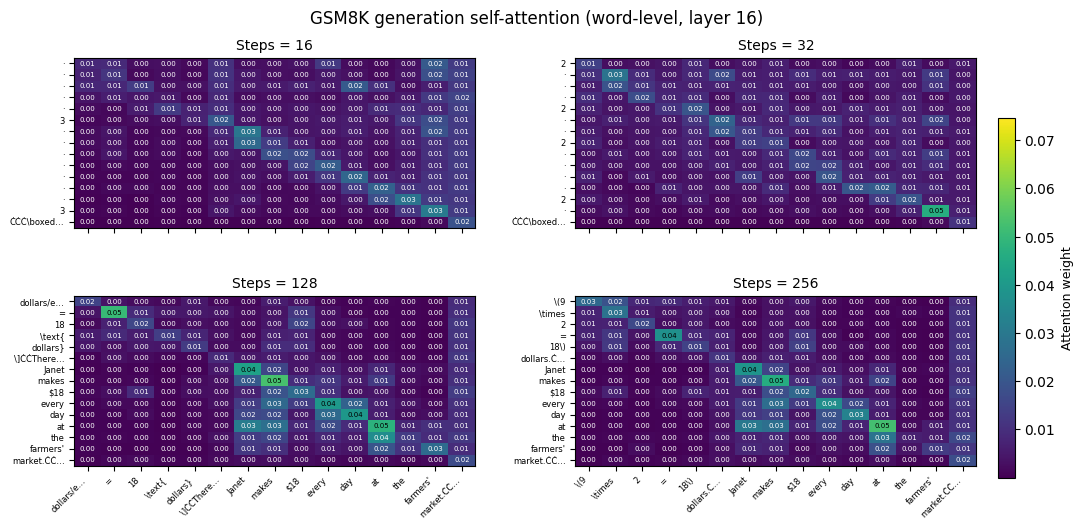

In [ ]:
plot_generation_self_attention_grid_clean(
    gen_word_attn,
    steps_list,
    layer_idx=layer_idx,      # e.g. 16
    max_gen_words_to_show=15, # keep small so numbers are readable
    figsize=(11, 6),
    annotate_values=True,
    annotate_max_size=20,
)

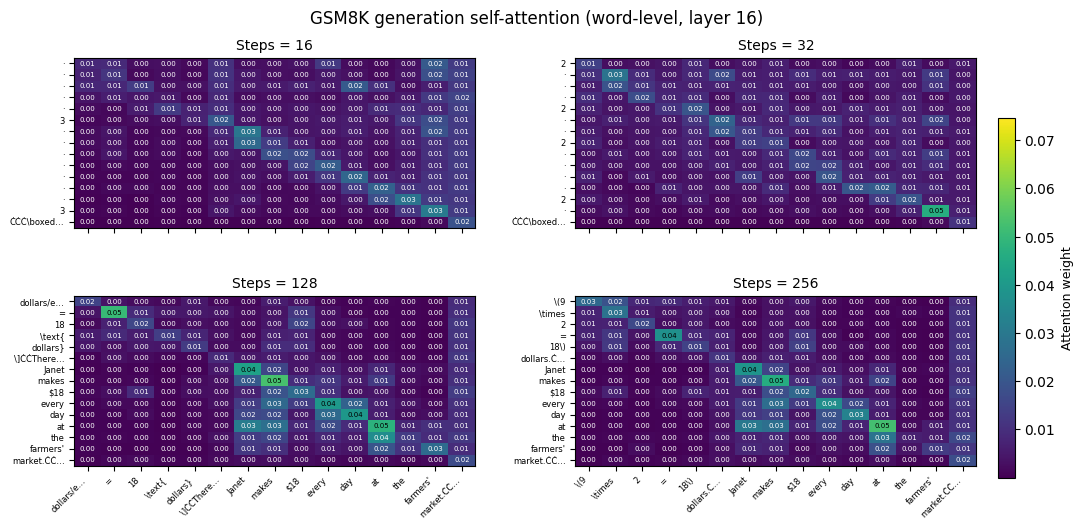

In [ ]:
plot_generation_self_attention_grid_clean(
    gen_word_attn,
    steps_list,
    layer_idx=16,      # e.g. 16
    max_gen_words_to_show=15, # keep small so numbers are readable
    figsize=(11, 6),
    annotate_values=True,
    annotate_max_size=20,
)

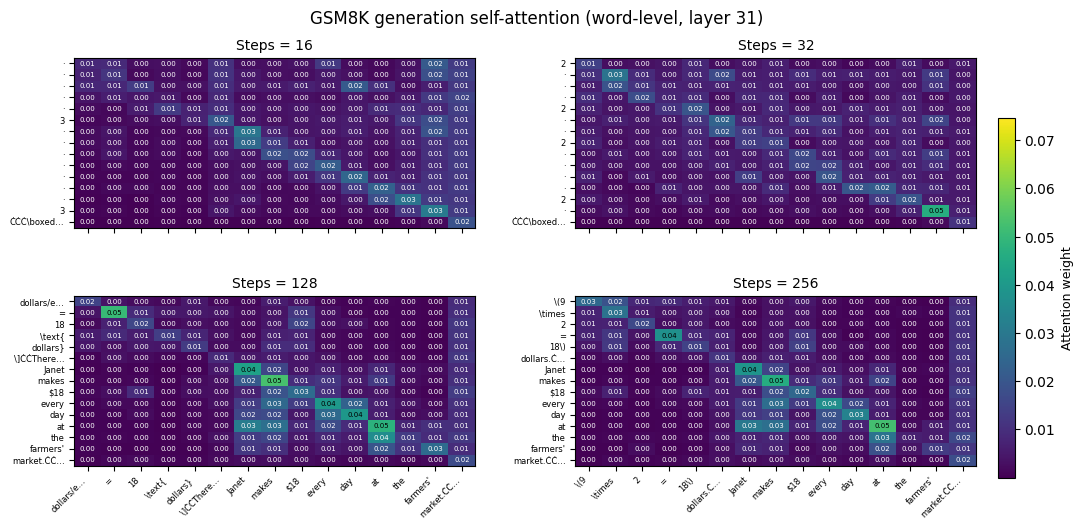

In [ ]:
plot_generation_self_attention_grid_clean(
    gen_word_attn,
    steps_list,
    layer_idx=31,      # e.g. 16
    max_gen_words_to_show=15, # keep small so numbers are readable
    figsize=(11, 6),
    annotate_values=True,
    annotate_max_size=20,
)

## Analysis for 4th metric

In [ ]:
from huggingface_hub import login

# This will open an input box; paste your HF token (starts with "hf_...")
login()

In [ ]:
from datasets import load_dataset
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# 1) Dataset registry for HF loading
# --------------------------------------------------
from datasets import load_dataset

DATASETS_INFO = {
    # GSM8K test split, "main" config
    "gsm8k_test": {
        "hf": "openai/gsm8k",
        "config": "main",
        "split": "test",
    },
    # AIME2025 – MathArena version
    "aime2025": {
        "hf": "MathArena/aime_2025",
        "config": None,
        "split": "train",
    },
    # GPQA extended (uses 'gpqa_extended' config, split is *train*)
    "gpqa_extended": {
        "hf": "Idavidrein/gpqa",
        "config": "gpqa_extended",
        "split": "train",   # correct: GPQA only has 'train' split
    },
}

def load_hf_dataset(ds_key: str):
    """
    Load a HF dataset by our short key, using DATASETS_INFO.

    Valid keys in this config:
      - 'gsm8k_test'
      - 'aime2025'
      - 'gpqa_extended'
    """
    info   = DATASETS_INFO[ds_key]
    hf_id  = info["hf"]
    config = info.get("config", None)
    split  = info["split"]   # <- fixed

    print(f"[load] {ds_key} <- {hf_id} (config={config}, split={split})")
    if config is None:
        ds = load_dataset(hf_id, split=split)
    else:
        ds = load_dataset(hf_id, config, split=split)

    print(f"  -> {len(ds)} examples, fields: {list(ds.features.keys())}")
    return ds

# --------------------------------------------------
# 2) QA extraction helpers (robust-ish)
# --------------------------------------------------

def extract_qa_from_example(ds_name: str, ex: dict):
    """
    Return (question_text, answer_text) from a raw HF example.
    Handles GSM8K, AIME2025 (MathArena), GPQA-main, plus some generic patterns.
    """

    # ---- Special case: GPQA main (Idavidrein/gpqa, config="gpqa_main") ----
    if ds_name.startswith("gpqa") or "Correct Answer" in ex:
        # Prefer revised version where available, fall back to pre-revision
        q = ex.get("Question", ex.get("Pre-Revision Question", ""))
        ans = ex.get("Correct Answer", ex.get("Pre-Revision Correct Answer", ""))
        return str(q), str(ans)

    # ---- GSM8K: 'question' + 'answer' ----
    if "question" in ex and "answer" in ex:
        return ex["question"], str(ex["answer"])

    # ---- AIME2025 (MathArena): 'problem' + 'answer' ----
    if "problem" in ex and "answer" in ex:
        return ex["problem"], str(ex["answer"])

    # ---- Generic capitalised QA (some mirrors) ----
    if "Question" in ex and "Answer" in ex:
        return str(ex["Question"]), str(ex["Answer"])

    # ---- Generic fallbacks ----
    # Question-like field
    if "question" in ex:
        q = ex["question"]
    elif "prompt" in ex:
        q = ex["prompt"]
    elif "problem" in ex:
        q = ex["problem"]
    elif "text" in ex:
        q = ex["text"]
    else:
        q = " ".join(str(ex.get(k, "")) for k in ["context", "instruction"])

    # Answer-like field
    if "answer" in ex:
        a = ex["answer"]
    elif "label" in ex:
        a = ex["label"]
    else:
        a = ""

    return str(q), str(a)


def tokenize_prompt_then_attach_answer(question_str, answer_str, tokenizer, device):
    """
    For the attention probes we build [prompt | answer] as:
      - prompt_ids: tokenized question only (no special tokens).
      - later we tokenize the answer separately and just concatenate ids.
    """
    q_enc = tokenizer(question_str, add_special_tokens=False)
    input_ids_prompt = torch.tensor(
        q_enc["input_ids"], dtype=torch.long, device=device
    )
    # Return prompt token ids and the raw answer string
    return input_ids_prompt, str(answer_str)

In [ ]:
# layers_to_probe = [4, 16, 24, 31]
# max_examples    = 128

# ds_gsm  = load_hf_dataset("gsm8k_test")
# ds_aime = load_hf_dataset("aime2025")
ds_gpqa = load_hf_dataset("gpqa_extended")

# stats_gsm  = run_probes_on_hf_dataset_with_frac(
#     mdl_llada, tok_llada, ds_gsm,  "gsm8k_test",
#     layers_to_probe=layers_to_probe, max_examples=max_examples, device=device,
# )
# stats_aime = run_probes_on_hf_dataset_with_frac(
#     mdl_llada, tok_llada, ds_aime, "aime2025",
#     layers_to_probe=layers_to_probe, max_examples=max_examples, device=device,
# )
# stats_gpqa = run_probes_on_hf_dataset_with_frac(
#     mdl_llada, tok_llada, ds_gpqa, "gpqa_extended",
#     layers_to_probe=layers_to_probe, max_examples=max_examples, device=device,
# )

[load] gpqa_extended <- Idavidrein/gpqa (config=gpqa_extended, split=train)
  -> 546 examples, fields: ['Pre-Revision Question', 'Pre-Revision Correct Answer', 'Pre-Revision Incorrect Answer 1', 'Pre-Revision Incorrect Answer 2', 'Pre-Revision Incorrect Answer 3', 'Pre-Revision Explanation', 'Self-reported question-writing time (minutes)', 'Question', 'Correct Answer', 'Incorrect Answer 1', 'Incorrect Answer 2', 'Incorrect Answer 3', 'Explanation', 'Revision Comments (from Question Writer)', 'Subdomain', "Writer's Difficulty Estimate", 'Extra Revised Question', 'Extra Revised Explanation', 'Extra Revised Correct Answer', 'Extra Revised Incorrect Answer 1', 'Extra Revised Incorrect Answer 2', 'Extra Revised Incorrect Answer 3', 'Non-Expert Validator Accuracy', 'Majority Non-Expert Vals Incorrect', 'Expert Validator Accuracy', 'Record ID', 'High-level domain', 'Question Writer', 'Feedback_EV_1', 'Validator Revision Suggestion_EV_1', 'Is First Validation_EV_1', 'Post hoc agreement_EV_1', 

Bundle stats from all three datasets

In [ ]:
all_stats = {
    "GSM8K":      stats_gsm,
    "AIME2025":   stats_aime,
    "GPQA-ext":   stats_gpqa,  # or stats_gpqa_extended
}

Helper: plot a single metric across layers & datasets

In [ ]:
import matplotlib.pyplot as plt

def plot_metric_across_datasets(all_stats, layers, metric_key, title, ylabel):
    """
    all_stats: dict[dataset_name] -> stats_dict
               where stats_dict[layer][metric_key] exists
    layers: list of int (layer indices)
    metric_key: e.g. 'bi_mean', 'ent_mean', 'ali_mean', 'frac_prompt_mean'
    """
    plt.figure(figsize=(6, 4))
    for ds_name, stats in all_stats.items():
        ys = [stats[l][metric_key] for l in layers]
        plt.plot(layers, ys, marker="o", label=ds_name)

    plt.title(title)
    plt.xlabel("Layer index")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

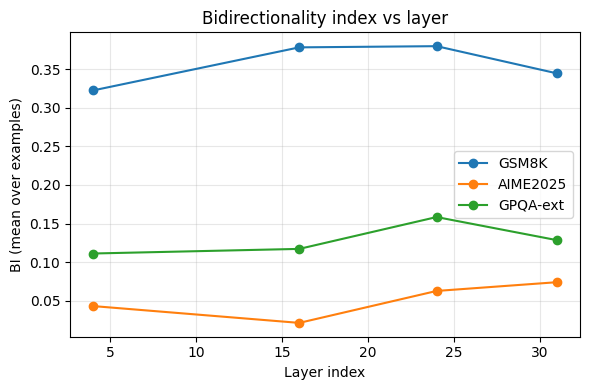

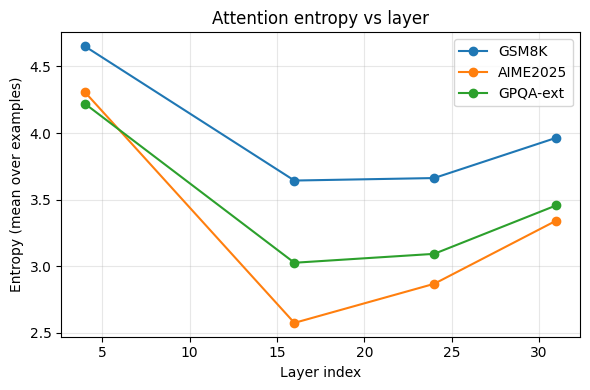

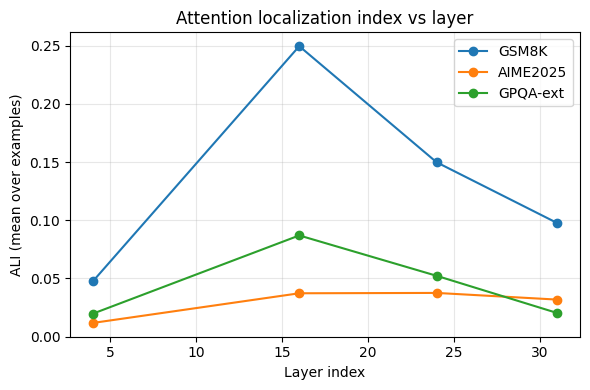

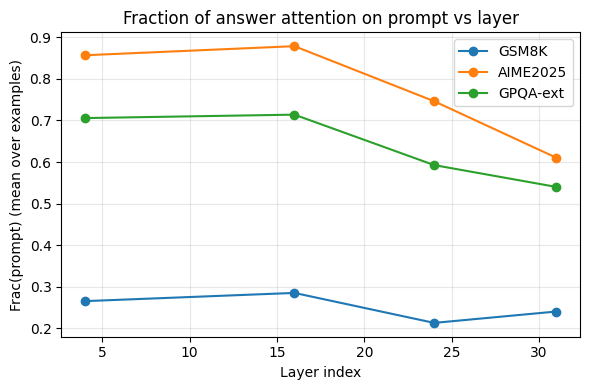

In [ ]:
# 1) Bidirectionality index (BI)
plot_metric_across_datasets(
    all_stats,
    layers_to_probe,
    metric_key="bi_mean",
    title="Bidirectionality index vs layer",
    ylabel="BI (mean over examples)",
)

# 2) Attention entropy
plot_metric_across_datasets(
    all_stats,
    layers_to_probe,
    metric_key="ent_mean",
    title="Attention entropy vs layer",
    ylabel="Entropy (mean over examples)",
)

# 3) Localization index (ALI)
plot_metric_across_datasets(
    all_stats,
    layers_to_probe,
    metric_key="ali_mean",
    title="Attention localization index vs layer",
    ylabel="ALI (mean over examples)",
)

# 4) New metric: fraction of answer attention landing on prompt tokens
plot_metric_across_datasets(
    all_stats,
    layers_to_probe,
    metric_key="frac_prompt_mean",
    title="Fraction of answer attention on prompt vs layer",
    ylabel="Frac(prompt) (mean over examples)",
)

## Unified per-example metric + attention extractor

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def llada_attention_metrics_for_example(
    model,
    tokenizer,
    question_str: str,
    answer_str: str,
    layers_to_probe,
    device="cuda",
):
    """
    Compute the 4 metrics for a single (question, answer) pair
    at multiple decoder layers for LLaDA.

    Returns:
      metrics_per_layer: dict[layer] -> {
          "bi": float,
          "entropy": float,
          "ali": float,
          "frac_prompt": float,
      }
      full_ids: 1D LongTensor of [prompt | answer] token ids
      prompt_len: int
      gen_len: int
      tokens: list[str] token strings for the full sequence
    """
    # 1) Build [prompt | answer] ids
    prompt_ids, answer_s = tokenize_prompt_then_attach_answer(
        question_str, answer_str, tokenizer, device
    )
    ans_ids = tokenizer(answer_s, add_special_tokens=False)["input_ids"]
    if len(ans_ids) == 0:
        raise ValueError("Empty answer tokenization; cannot probe.")

    full_ids_list = prompt_ids.tolist() + ans_ids
    full_ids = torch.tensor([full_ids_list], dtype=torch.long, device=device)  # [1, T]
    prompt_len = len(prompt_ids)
    gen_len = len(ans_ids)

    # 2) Per-layer metrics
    metrics_per_layer = {}
    for layer_idx in layers_to_probe:
        attn_layer = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)  # [1,H,T,T]

        bi_val = compute_bidirectionality_index(
            attn_layer, prompt_len, gen_len
        ).mean().item()
        ent_val = compute_attention_entropy(
            attn_layer, prompt_len, gen_len
        ).mean().item()
        ali_val = compute_attention_localization_index(
            attn_layer, prompt_len, gen_len
        ).mean().item()
        fp_val = compute_frac_prompt(
            attn_layer, prompt_len, gen_len
        ).mean().item()

        metrics_per_layer[layer_idx] = {
            "bi": bi_val,
            "entropy": ent_val,
            "ali": ali_val,
            "frac_prompt": fp_val,
        }

    tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())
    return metrics_per_layer, full_ids[0], prompt_len, gen_len, tokens

2. Word-level attention + generation-only submatrix (clean version)

In [ ]:
import re

def tokens_to_words(tokens):
    """
    Merge subword tokens into words using leading-space markers.
    Returns:
      words: list[str]
      spans: list[list[int]] of token indices per word
    """
    words = []
    spans = []
    current = ""
    current_idxs = []

    for i, tok in enumerate(tokens):
        new_word = False
        clean = tok

        # handle typical BPE/BBPE leading-space markers
        if tok.startswith("Ġ") or tok.startswith("▁"):
            new_word = True
            clean = tok[1:]
        elif tok.startswith("G") and len(tok) > 1 and tok[1].isalpha():
            # crude heuristic for certain vocabs
            new_word = True
            clean = tok[1:]

        if new_word or i == 0:
            if current_idxs:
                words.append(current)
                spans.append(current_idxs)
            current = clean
            current_idxs = [i]
        else:
            current += tok
            current_idxs.append(i)

    if current_idxs:
        words.append(current)
        spans.append(current_idxs)

    return words, spans

def word_level_attention(attn_mean, spans):
    """
    attn_mean: [T, T] tensor or np.array
    spans: list[list[int]] token indices per word
    Returns:
      W_attn: [W, W] word-level matrix
    """
    if isinstance(attn_mean, torch.Tensor):
        A = attn_mean.to(torch.float32).cpu().numpy()
    else:
        A = np.asarray(attn_mean)

    W = len(spans)
    W_attn = np.zeros((W, W), dtype=float)
    for i, idx_i in enumerate(spans):
        for j, idx_j in enumerate(spans):
            W_attn[i, j] = A[np.ix_(idx_i, idx_j)].mean()
    return W_attn

def get_generated_word_indices(tokens, prompt_len, gen_len):
    """
    Given full tokens and prompt/gen split, figure out
    which word indices correspond to generated tokens.
    """
    words, spans = tokens_to_words(tokens)

    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    ans_start = prompt_len
    ans_end   = prompt_len + gen_len

    gen_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(ans_start, ans_end)
        if ti in token_to_word
    })

    return words, spans, gen_word_idxs

3. Clean 4-metric per-layer plot (per example)

In [ ]:
import matplotlib.pyplot as plt

def plot_four_metrics_for_example(metrics_per_layer, layers_to_probe, title_prefix=""):
    """
    metrics_per_layer: dict[layer] -> {'bi', 'entropy', 'ali', 'frac_prompt'}
    layers_to_probe: list[int]
    """
    bi_vals   = [metrics_per_layer[l]["bi"]           for l in layers_to_probe]
    ent_vals  = [metrics_per_layer[l]["entropy"]      for l in layers_to_probe]
    ali_vals  = [metrics_per_layer[l]["ali"]          for l in layers_to_probe]
    fp_vals   = [metrics_per_layer[l]["frac_prompt"]  for l in layers_to_probe]

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()

    axes[0].plot(layers_to_probe, bi_vals, marker="o")
    axes[0].set_title("Bidirectionality index (BI)")
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("BI")

    axes[1].plot(layers_to_probe, ent_vals, marker="o")
    axes[1].set_title("Attention entropy")
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Entropy")

    axes[2].plot(layers_to_probe, ali_vals, marker="o")
    axes[2].set_title("Attention localization index (ALI)")
    axes[2].set_xlabel("Layer")
    axes[2].set_ylabel("ALI")

    axes[3].plot(layers_to_probe, fp_vals, marker="o")
    axes[3].set_title("Frac. answer-attn → prompt (new metric)")
    axes[3].set_xlabel("Layer")
    axes[3].set_ylabel("Frac(prompt)")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    if title_prefix:
        fig.suptitle(title_prefix, fontsize=12, y=0.99)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

4. Clean multi-panel attention heatmap (generation-only, one layer)

In [ ]:
def _clean_label(w: str, max_len: int = 10) -> str:
    """Shorten / clean token strings for axis labels."""
    w = re.sub(r"<\|.*?\|>", "", w)  # strip HF special tokens
    for tag in ["<reasoning>", "</reasoning>", "<answer>", "</answer>"]:
        w = w.replace(tag, "")
    w = w.strip()
    if not w:
        return "·"
    if len(w) > max_len:
        return w[: max_len - 1] + "…"
    return w

def plot_generation_self_attention_for_layer(
    attn_layer, tokens, prompt_len, gen_len,
    layer_idx,
    max_gen_words_to_show=20,
    annotate_values=True,
    annotate_max_size=20,
    figsize=(6, 5),
):
    """
    attn_layer: [1, H, T, T] tensor (already for desired layer)
    tokens: list[str] of length T
    prompt_len, gen_len: ints
    """
    # average over heads
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]

    words, spans, gen_word_idxs = get_generated_word_indices(tokens, prompt_len, gen_len)
    if not gen_word_idxs:
        print("No generated words; nothing to plot.")
        return

    W_attn = word_level_attention(attn_mean, spans)

    idx = np.array(gen_word_idxs)
    sub = W_attn[np.ix_(idx, idx)]
    gen_words = [words[i] for i in idx]

    if len(gen_words) > max_gen_words_to_show:
        start = len(gen_words) - max_gen_words_to_show
        gen_words_plot = gen_words[start:]
        sub_plot = sub[start:, start:]
    else:
        gen_words_plot = gen_words
        sub_plot = sub

    n_words = len(gen_words_plot)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(sub_plot, aspect="auto")

    ax.set_title(f"Gen self-attention (words), layer {layer_idx}")
    ax.set_xticks(range(n_words))
    ax.set_yticks(range(n_words))
    ax.set_xticklabels([_clean_label(w) for w in gen_words_plot], rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels([_clean_label(w) for w in gen_words_plot], fontsize=7)

    if annotate_values and n_words <= annotate_max_size:
        vmin, vmax = sub_plot.min(), sub_plot.max()
        for r in range(n_words):
            for c in range(n_words):
                val = float(sub_plot[r, c])
                txt = f"{val:.2f}"
                color = "black" if val > 0.5 * vmax else "white"
                ax.text(c, r, txt, ha="center", va="center", fontsize=5, color=color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Attention weight", fontsize=9)
    plt.tight_layout()
    plt.show()

5. How to call this in your notebook (end-to-end example)

[GSM8K] example index = 0


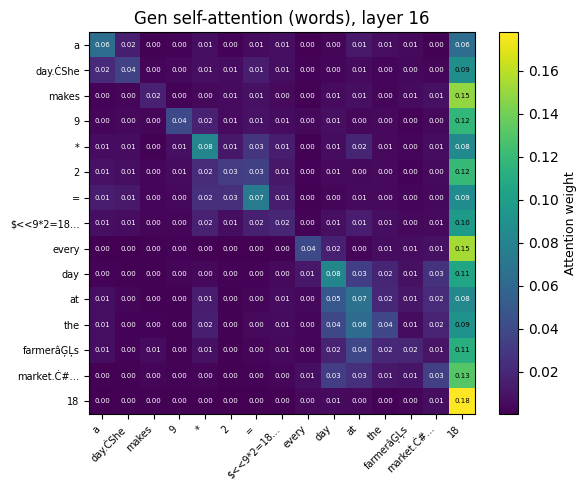

[AIME2025] example index = 0


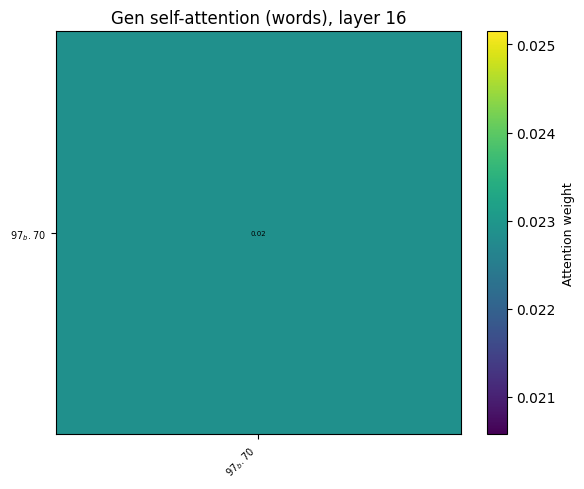

[GPQA-ext] example index = 0


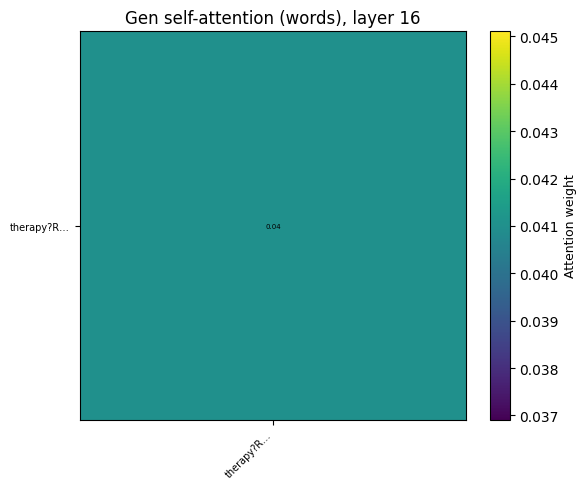

In [ ]:
layers_to_probe = [4, 16, 24, 31]   # you can tweak this
layer_for_heatmap = 16              # which layer to show the attention map for

# (dataset_label, ds_name_key_for_extractor, dataset_obj, example_index)
datasets_for_examples = [
    ("GSM8K",      "gsm8k_test",   ds_gsm,  0),
    ("AIME2025",   "aime2025",     ds_aime, 0),
    ("GPQA-ext",   "gpqa_extended", ds_gpqa, 0),
]

for label, ds_name, ds, ex_idx in datasets_for_examples:
    print("=" * 80)
    print(f"[{label}] example index = {ex_idx}")
    print("=" * 80)

    # 1) Grab raw HF example and extract (question, answer)
    ex = ds[ex_idx]
    q_str, a_str = extract_qa_from_example(ds_name, ex)

    # print("Question:")
    # print(q_str)
    # print("\nGold answer (raw):")
    # print(a_str)
    # print()

    # 2) Compute per-layer metrics + tokenization details
    metrics_per_layer, full_ids, prompt_len, gen_len, tokens = \
        llada_attention_metrics_for_example(
            mdl_llada,
            tok_llada,
            q_str,
            a_str,
            layers_to_probe=layers_to_probe,
            device=device,
        )

    # 4) Plot the generation-only word-level attention heatmap
    #    for one chosen layer (e.g., 16)
    # print(f"\nWord-level generation self-attention heatmap for {label}, layer {layer_for_heatmap}")
    # attn_layer = get_llada_layer_attn(
    #     mdl_llada,
    #     full_ids.unsqueeze(0),   # [1, T]
    #     layer_idx=layer_for_heatmap,
    # )

    plot_generation_self_attention_for_layer(
        attn_layer,
        tokens,
        prompt_len,
        gen_len,
        layer_idx=layer_for_heatmap,
        max_gen_words_to_show=15,   # keep small so readable
        annotate_values=True,
        annotate_max_size=20,
        figsize=(6, 5),
    )

Helper: aggregate stats over selected examples (4 metrics)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------- small helpers ----------

def tokens_to_words(tokens):
    """
    Merge subword tokens into 'words' based on leading space markers
    like 'Ġ' (GPT-style) or '▁' (SentencePiece).
    Returns:
      words: list[str]
      spans: list[list[int]]  token indices belonging to each word
    """
    words = []
    spans = []

    current_word = ""
    current_span = []

    for i, tok in enumerate(tokens):
        # normalize token string
        t = tok

        # New word if this token begins with a space marker
        is_new = (t.startswith("Ġ") or t.startswith("▁") or i == 0)

        if is_new and current_span:
            words.append(current_word)
            spans.append(current_span)
            current_word = ""
            current_span = []

        # strip leading markers for the "word" surface form
        t_clean = t.lstrip("Ġ▁")
        current_word += ("" if current_word == "" else "") + t_clean
        current_span.append(i)

    if current_span:
        words.append(current_word)
        spans.append(current_span)

    return words, spans


def _clean_label(w, max_len=10):
    w = str(w)
    if len(w) > max_len:
        return w[:max_len - 1] + "…"
    return w


def word_level_attention(attn_tok, spans):
    """
    attn_tok: [T, T] numpy (token-level attention)
    spans: list of lists of token indices for each word
    Returns:
      W_attn: [W, W] word-level attention matrix
    """
    W = len(spans)
    W_attn = np.zeros((W, W), dtype=np.float32)

    for i, span_i in enumerate(spans):
        for j, span_j in enumerate(spans):
            block = attn_tok[np.ix_(span_i, span_j)]
            if block.size > 0:
                W_attn[i, j] = block.mean()
    return W_attn


# ---------- main plotting function ----------

def plot_answer_to_prompt_attention_for_layer(
    attn_layer,
    tokens,
    prompt_len,
    gen_len,
    layer_idx,
    k_prompt_tail=12,
    annotate_values=False,
    annotate_max_size=20,
    figsize=(6, 4),
):
    """
    Plot word-level attention:
      rows  = answer words
      cols  = last k_prompt_tail prompt words + all answer words
    attn_layer: [1, H, T, T] torch tensor
    tokens: list[str] length T
    """
    # 1) average over heads → [T, T]
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]
    A = attn_mean.detach().cpu().numpy()

    # 2) word grouping
    words, spans = tokens_to_words(tokens)

    # token index -> word index
    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    T = len(tokens)
    ans_start = prompt_len
    ans_end   = min(prompt_len + gen_len, T)

    # answer words
    ans_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(ans_start, ans_end)
        if ti in token_to_word
    })

    if not ans_word_idxs:
        print("No answer words detected; skipping heatmap.")
        return

    # prompt words
    prompt_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(0, prompt_len)
        if ti in token_to_word
    })
    if len(prompt_word_idxs) > k_prompt_tail:
        prompt_word_idxs = prompt_word_idxs[-k_prompt_tail:]

    # 3) word-level attention
    W_attn = word_level_attention(A, spans)  # [W, W]

    row_idxs = np.array(ans_word_idxs)
    col_idxs = np.array(prompt_word_idxs + ans_word_idxs)

    sub = W_attn[np.ix_(row_idxs, col_idxs)]
    row_labels = [words[i] for i in row_idxs]
    col_labels = [words[i] for i in col_idxs]

    n_rows, n_cols = sub.shape

    # 4) plotting
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(sub, aspect="auto")

    ax.set_title(f"Answer → (prompt tail + answer) attention, layer {layer_idx}")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([_clean_label(w) for w in col_labels],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([_clean_label(w) for w in row_labels], fontsize=7)

    if annotate_values and (n_rows * n_cols) <= annotate_max_size * annotate_max_size:
        vmax = sub.max() if sub.size > 0 else 0.0
        for r in range(n_rows):
            for c in range(n_cols):
                val = float(sub[r, c])
                txt = f"{val:.2f}"
                color = "black" if vmax > 0 and val > 0.6 * vmax else "white"
                ax.text(c, r, txt, ha="center", va="center", fontsize=5, color=color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Attention weight", fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_answer_to_prompt_attention_for_layer(
    attn_layer,
    tokens,
    prompt_len,
    gen_len,
    layer_idx,
    k_prompt_tail=12,
    annotate_values=False,
    annotate_max_size=20,
    figsize=(6, 4),
):
    """
    Plot word-level attention:
      rows  = answer words
      cols  = last k_prompt_tail prompt words + all answer words
    attn_layer: [1, H, T, T] torch tensor
    tokens: list[str] length T
    """
    # 1) average over heads → [T, T]
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]
    # 🔧 Cast bfloat16 → float32 before converting to numpy
    A = attn_mean.detach().to(torch.float32).cpu().numpy()

    # 2) word grouping
    words, spans = tokens_to_words(tokens)

    # token index -> word index
    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    T = len(tokens)
    ans_start = prompt_len
    ans_end   = min(prompt_len + gen_len, T)

    # answer words
    ans_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(ans_start, ans_end)
        if ti in token_to_word
    })

    if not ans_word_idxs:
        print("No answer words detected; skipping heatmap.")
        return

    # prompt words
    prompt_word_idxs = sorted({
        token_to_word[ti]
        for ti in range(0, prompt_len)
        if ti in token_to_word
    })
    if len(prompt_word_idxs) > k_prompt_tail:
        prompt_word_idxs = prompt_word_idxs[-k_prompt_tail:]

    # 3) word-level attention
    W_attn = word_level_attention(A, spans)  # [W, W]

    row_idxs = np.array(ans_word_idxs)
    col_idxs = np.array(prompt_word_idxs + ans_word_idxs)

    sub = W_attn[np.ix_(row_idxs, col_idxs)]
    row_labels = [words[i] for i in row_idxs]
    col_labels = [words[i] for i in col_idxs]

    n_rows, n_cols = sub.shape

    # 4) plotting
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(sub, aspect="auto")

    ax.set_title(f"Answer → (prompt tail + answer) attention, layer {layer_idx}")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([_clean_label(w) for w in col_labels],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([_clean_label(w) for w in row_labels], fontsize=7)

    if annotate_values and (n_rows * n_cols) <= annotate_max_size * annotate_max_size:
        vmax = sub.max() if sub.size > 0 else 0.0
        for r in range(n_rows):
            for c in range(n_cols):
                val = float(sub[r, c])
                txt = f"{val:.2f}"
                color = "black" if vmax > 0 and val > 0.6 * vmax else "white"
                ax.text(c, r, txt, ha="center", va="center", fontsize=5, color=color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Attention weight", fontsize=9)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np

# You already defined this:
qualitative_indices = {
    "gsm8k":   [10, 200, 500],
    "logiqa":  [5, 100, 300],
    "aime2025":[0, 10, 20],
    "gpqa":    [0, 50, 100],
}

layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]

# Map dataset short key -> (name used in extract_qa_from_example, variable name of dataset object)
datasets_for_heatmaps = {
    "gsm8k":   ("gsm8k_test",    "ds_gsm"),
    "logiqa":  ("logiqa",        "ds_logiqa"),     # will be skipped if ds_logiqa doesn't exist
    "aime2025":("aime2025",      "ds_aime"),
    "gpqa":    ("gpqa_extended", "ds_gpqa"),
}

for ds_key, (extract_name, obj_name) in datasets_for_heatmaps.items():
    if obj_name not in globals():
        print(f"[WARN] Dataset object '{obj_name}' for {ds_key} not found; skipping.")
        continue

    ds = globals()[obj_name]
    idx_list = qualitative_indices.get(ds_key, [])
    if not idx_list:
        print(f"[WARN] No qualitative indices for {ds_key}; skipping.")
        continue

    print("\n" + "=" * 100)
    print(f"DATASET: {ds_key}  |  indices: {idx_list}")
    print("=" * 100)

    for ex_idx in idx_list:
        ex = ds[ex_idx]
        q_str, a_str = extract_qa_from_example(extract_name, ex)

        print("\n" + "-" * 80)
        print(f"[{ds_key}] example idx = {ex_idx}")
        print("-" * 80)
        print("Question (truncated):")
        print(q_str[:220].replace("\n", " ") + ("..." if len(q_str) > 220 else ""))
        print("\nAnswer (raw, truncated):")
        a_str_s = str(a_str)
        print(a_str_s[:220] + ("..." if len(a_str_s) > 220 else ""))

        # Get full tokenization + prompt/gen split
        metrics_per_layer, full_ids, prompt_len, gen_len, tokens = \
            llada_attention_metrics_for_example(
                mdl_llada,
                tok_llada,
                q_str,
                a_str,
                layers_to_probe=layers_to_probe,
                device=device,
            )

        # Now: for each layer, plot the heatmap
        for l in layers_to_probe:
            print(f"\n[heatmap] {ds_key}  example={ex_idx}  layer={l}")
            attn_layer = get_llada_layer_attn(
                mdl_llada,
                full_ids.unsqueeze(0),    # [1, T]
                layer_idx=l,
            )

            # Answer → (prompt tail + answer) attention
            plot_answer_to_prompt_attention_for_layer(
                attn_layer,
                tokens,
                prompt_len,
                gen_len,
                layer_idx=l,
                k_prompt_tail=12,      # how many prompt words to show
                annotate_values=False, # set True only if matrices are small
                annotate_max_size=20,
                figsize=(6, 4),
            )

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_answer_to_prompt_attention_compact(
    attn_layer,
    tokens,
    prompt_len,
    gen_len,
    layer_idx,
    max_answer_words=10,
    max_prompt_words=10,
    figsize=(7, 5),
):
    """
    Compact word-level heatmap:

      rows  = top-K answer words (by total outgoing attention)
      cols  = top-K prompt words (by incoming mass from those answer words)
              + all selected answer words

    attn_layer: [1, H, T, T] torch tensor
    tokens: list[str] length T
    """

    # --- 1) average over heads → [T, T] float32 ---
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]
    A = attn_mean.detach().to(torch.float32).cpu().numpy()

    # --- 2) word grouping ---
    words, spans = tokens_to_words(tokens)

    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    T = len(tokens)
    ans_start = prompt_len
    ans_end   = min(prompt_len + gen_len, T)

    # all answer words (indices in [0, W))
    ans_word_idxs_full = sorted({
        token_to_word[ti]
        for ti in range(ans_start, ans_end)
        if ti in token_to_word
    })

    if not ans_word_idxs_full:
        print("No answer words detected; skipping compact heatmap.")
        return

    # all prompt words
    prompt_word_idxs_full = sorted({
        token_to_word[ti]
        for ti in range(0, prompt_len)
        if ti in token_to_word
    })

    # --- 3) word-level attention matrix W_attn[W,W] ---
    W_attn = word_level_attention(A, spans)

    # --- 4) select "most relevant" answer words (rows) ---
    # score = total outgoing attention to all words
    ans_scores = W_attn[ans_word_idxs_full, :].sum(axis=1)  # [n_ans]
    order = np.argsort(-ans_scores)  # descending
    k_ans = min(max_answer_words, len(ans_word_idxs_full))
    top_ans_idxs = [ans_word_idxs_full[i] for i in order[:k_ans]]
    # keep original order along the sequence
    top_ans_idxs = sorted(top_ans_idxs)

    # --- 5) select most attended prompt words (cols) ---
    if prompt_word_idxs_full:
        # restrict to prompt columns only for scoring
        sub_for_prompt = W_attn[np.ix_(top_ans_idxs, prompt_word_idxs_full)]  # [k_ans, n_prompt]
        prompt_scores = sub_for_prompt.sum(axis=0)  # [n_prompt]
        order_p = np.argsort(-prompt_scores)
        k_pr = min(max_prompt_words, len(prompt_word_idxs_full))
        top_prompt_idxs = [prompt_word_idxs_full[i] for i in order_p[:k_pr]]
        top_prompt_idxs = sorted(top_prompt_idxs)
    else:
        top_prompt_idxs = []

    # final row/col sets
    row_idxs = np.array(top_ans_idxs)
    col_idxs = np.array(top_prompt_idxs + top_ans_idxs)

    sub = W_attn[np.ix_(row_idxs, col_idxs)]
    row_labels = [words[i] for i in row_idxs]
    col_labels = [words[i] for i in col_idxs]

    n_rows, n_cols = sub.shape

    # --- 6) plot with annotations ---
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(sub, aspect="auto")

    ax.set_title(f"GSM8K answer → prompt+answer (compact), layer {layer_idx}")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([_clean_label(w, max_len=12) for w in col_labels],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([_clean_label(w, max_len=12) for w in row_labels],
                       fontsize=8)

    vmax = sub.max() if sub.size > 0 else 0.0
    for r in range(n_rows):
        for c in range(n_cols):
            val = float(sub[r, c])
            txt = f"{val:.2f}"
            color = "black" if vmax > 0 and val > 0.6 * vmax else "white"
            ax.text(c, r, txt, ha="center", va="center", fontsize=7, color=color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Attention weight", fontsize=10)

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---- helpers for word grouping ----

def tokens_to_words(tokens):
    """
    Merge subword tokens into 'words' based on leading space markers
    like 'Ġ' (GPT-style) or '▁' (SentencePiece).
    Returns:
      words: list[str]
      spans: list[list[int]]  token indices belonging to each word
    """
    words = []
    spans = []

    current_word = ""
    current_span = []

    for i, tok in enumerate(tokens):
        t = tok

        is_new = (t.startswith("Ġ") or t.startswith("▁") or i == 0)

        if is_new and current_span:
            words.append(current_word)
            spans.append(current_span)
            current_word = ""
            current_span = []

        t_clean = t.lstrip("Ġ▁")
        current_word += ("" if current_word == "" else "") + t_clean
        current_span.append(i)

    if current_span:
        words.append(current_word)
        spans.append(current_span)

    return words, spans


def _clean_label(w, max_len=12):
    w = str(w)
    if len(w) > max_len:
        return w[: max_len - 1] + "…"
    return w


def word_level_attention(attn_tok, spans):
    """
    attn_tok: [T, T] numpy (token-level attention)
    spans: list of lists of token indices for each word
    Returns:
      W_attn: [W, W] word-level attention matrix
    """
    W = len(spans)
    W_attn = np.zeros((W, W), dtype=np.float32)

    for i, span_i in enumerate(spans):
        for j, span_j in enumerate(spans):
            block = attn_tok[np.ix_(span_i, span_j)]
            if block.size > 0:
                W_attn[i, j] = block.mean()
    return W_attn


# ---- compact GSM8K heatmap ----

def plot_gsm8k_answer_attention_compact(
    attn_layer,
    tokens,
    prompt_len,
    gen_len,
    layer_idx,
    max_answer_words=10,
    max_prompt_words=10,
    figsize=(7, 5),
):
    """
    GSM8K-only compact word-level heatmap:

      rows  = top-K answer words (by outgoing attention mass)
      cols  = top-K prompt words (by incoming mass from those answer words)
              + all selected answer words

    attn_layer: [1, H, T, T] torch tensor
    tokens: list[str] length T
    """

    # 1) average over heads -> [T, T] float32
    attn_mean = attn_layer.mean(dim=1)[0]  # [T, T]
    A = attn_mean.detach().to(torch.float32).cpu().numpy()

    # 2) word grouping
    words, spans = tokens_to_words(tokens)

    token_to_word = {}
    for wi, span in enumerate(spans):
        for ti in span:
            token_to_word[ti] = wi

    T = len(tokens)
    ans_start = prompt_len
    ans_end   = min(prompt_len + gen_len, T)

    # answer words (by word index)
    ans_word_idxs_full = sorted({
        token_to_word[ti]
        for ti in range(ans_start, ans_end)
        if ti in token_to_word
    })
    if not ans_word_idxs_full:
        print("No answer words detected; skipping heatmap.")
        return

    # prompt words (by word index)
    prompt_word_idxs_full = sorted({
        token_to_word[ti]
        for ti in range(0, prompt_len)
        if ti in token_to_word
    })

    # 3) word-level attention matrix [W, W]
    W_attn = word_level_attention(A, spans)

    # 4) pick top answer words by outgoing attention
    ans_scores = W_attn[ans_word_idxs_full, :].sum(axis=1)  # [n_ans]
    order = np.argsort(-ans_scores)
    k_ans = min(max_answer_words, len(ans_word_idxs_full))
    top_ans_idxs = [ans_word_idxs_full[i] for i in order[:k_ans]]
    top_ans_idxs = sorted(top_ans_idxs)  # keep sequence order

    # 5) pick top prompt words by incoming mass from selected answers
    if prompt_word_idxs_full:
        sub_for_prompt = W_attn[np.ix_(top_ans_idxs, prompt_word_idxs_full)]  # [k_ans, n_prompt]
        prompt_scores = sub_for_prompt.sum(axis=0)
        order_p = np.argsort(-prompt_scores)
        k_pr = min(max_prompt_words, len(prompt_word_idxs_full))
        top_prompt_idxs = [prompt_word_idxs_full[i] for i in order_p[:k_pr]]
        top_prompt_idxs = sorted(top_prompt_idxs)
    else:
        top_prompt_idxs = []

    row_idxs = np.array(top_ans_idxs)
    col_idxs = np.array(top_prompt_idxs + top_ans_idxs)

    sub = W_attn[np.ix_(row_idxs, col_idxs)]
    row_labels = [words[i] for i in row_idxs]
    col_labels = [words[i] for i in col_idxs]

    n_rows, n_cols = sub.shape

    # 6) plot with annotations
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(sub, aspect="auto")

    ax.set_title(f"GSM8K answer → prompt+answer (compact), layer {layer_idx}")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([_clean_label(w) for w in col_labels],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([_clean_label(w) for w in row_labels], fontsize=8)

    vmax = sub.max() if sub.size > 0 else 0.0
    for r in range(n_rows):
        for c in range(n_cols):
            val = float(sub[r, c])
            txt = f"{val:.2f}"
            color = "black" if vmax > 0 and val > 0.6 * vmax else "white"
            ax.text(c, r, txt, ha="center", va="center", fontsize=7, color=color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Attention weight", fontsize=10)

    plt.tight_layout()
    plt.show()

In [ ]:
# which examples & layers to visualize
gsm_indices = [10, 200, 500]
layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]

for ex_idx in gsm_indices:
    ex = ds_gsm[ex_idx]
    q_str = ex["question"]
    a_str = ex["answer"]

    print("\n" + "=" * 80)
    print(f"GSM8K example idx = {ex_idx}")
    print("=" * 80)
    print("Question (truncated):")
    print(q_str[:220].replace("\n", " ") + ("..." if len(q_str) > 220 else ""))
    print("\nAnswer (raw, truncated):")
    print(a_str[:220] + ("..." if len(a_str) > 220 else ""))

    # get full ids, prompt/gen split, tokens using your existing helper
    metrics_per_layer, full_ids, prompt_len, gen_len, tokens = \
        llada_attention_metrics_for_example(
            mdl_llada,
            tok_llada,
            q_str,
            a_str,
            layers_to_probe=layers_to_probe,
            device=device,
        )

    for l in layers_to_probe:
        print(f"\n[heatmap] gsm8k  example={ex_idx}  layer={l}")
        attn_layer = get_llada_layer_attn(
            mdl_llada,
            full_ids.unsqueeze(0),   # [1, T]
            layer_idx=l,
        )

        plot_gsm8k_answer_attention_compact(
            attn_layer,
            tokens,
            prompt_len,
            gen_len,
            layer_idx=l,
            max_answer_words=10,
            max_prompt_words=10,
            figsize=(7, 5),
        )

Output hidden; open in https://colab.research.google.com to view.

## Further analysis

### 1. Quadrant + numeric helpers (per layer, per example)

In [ ]:
import torch
import numpy as np
import re
from tqdm import tqdm

# ─────────────────────────────
#  Token classification helper
# ─────────────────────────────

_digit_re = re.compile(r"\d")

def is_numeric_token(tok: str) -> bool:
    """Token is numeric if it contains any digit."""
    return bool(_digit_re.search(tok))


# ─────────────────────────────
# 1) Quadrant metrics for one layer
# ─────────────────────────────

def quadrant_metrics_for_layer(attn_layer: torch.Tensor,
                               prompt_len: int,
                               gen_len: int):
    """
    attn_layer : [1, H, T, T]
    prompt_len : # prompt tokens
    gen_len    : # answer tokens

    Returns dict: p2p, p2a, a2p, a2a, a2p_cond, a2a_cond
    """
    # avg heads → [T, T]
    A = attn_layer.mean(dim=1)[0].to(torch.float32)
    T = A.size(0)

    P = min(prompt_len, T)
    G = min(gen_len, max(0, T - P))
    A_start = P
    A_end   = min(P + G, T)

    if P == 0 or A_end <= A_start:
        return {k: float("nan") for k in ["p2p","p2a","a2p","a2a","a2p_cond","a2a_cond"]}

    S_p2p = A[0:P, 0:P].sum().item()
    S_p2a = A[0:P, A_start:A_end].sum().item()
    S_a2p = A[A_start:A_end, 0:P].sum().item()
    S_a2a = A[A_start:A_end, A_start:A_end].sum().item()

    S_total = S_p2p + S_p2a + S_a2p + S_a2a
    if S_total <= 0:
        S_total = 1.0

    p2p = S_p2p / S_total
    p2a = S_p2a / S_total
    a2p = S_a2p / S_total
    a2a = S_a2a / S_total

    S_ans = S_a2p + S_a2a
    if S_ans > 0:
        a2p_cond = S_a2p / S_ans
        a2a_cond = S_a2a / S_ans
    else:
        a2p_cond = float("nan")
        a2a_cond = float("nan")

    return {
        "p2p": p2p,
        "p2a": p2a,
        "a2p": a2p,
        "a2a": a2a,
        "a2p_cond": a2p_cond,
        "a2a_cond": a2a_cond,
    }


# ─────────────────────────────
# 2) Numeric vs non-numeric metrics for one layer
# ─────────────────────────────

def numeric_metrics_for_layer(attn_layer: torch.Tensor,
                              tokens: list,
                              prompt_len: int,
                              gen_len: int):
    """
    attn_layer : [1, H, T, T]
    tokens     : list[str] length T
    prompt_len, gen_len as above

    Returns dict with:
      ans_to_numeric_frac
      num2num_frac, num2non_frac
      non2num_frac, non2non_frac
    """
    A = attn_layer.mean(dim=1)[0].to(torch.float32)
    T = A.size(0)

    P = min(prompt_len, T)
    G = min(gen_len, max(0, T - P))
    A_start = P
    A_end   = min(P + G, T)

    if A_end <= A_start:
        return {
            "ans_to_numeric_frac": float("nan"),
            "num2num_frac": float("nan"),
            "num2non_frac": float("nan"),
            "non2num_frac": float("nan"),
            "non2non_frac": float("nan"),
        }

    is_num = [is_numeric_token(tok) for tok in tokens]
    idx_all = np.arange(T)
    idx_num = idx_all[[i for i, b in enumerate(is_num) if b]]
    idx_non = idx_all[[i for i, b in enumerate(is_num) if not b]]

    ans_rows = np.arange(A_start, A_end)
    ans_num_rows = [i for i in ans_rows if i < len(is_num) and is_num[i]]
    ans_non_rows = [i for i in ans_rows if i < len(is_num) and not is_num[i]]

    idx_num_t = torch.as_tensor(idx_num, device=A.device, dtype=torch.long) if len(idx_num) else torch.empty(0, dtype=torch.long, device=A.device)
    idx_non_t = torch.as_tensor(idx_non, device=A.device, dtype=torch.long) if len(idx_non) else torch.empty(0, dtype=torch.long, device=A.device)

    # Answer → numeric / non-numeric
    ans_rows_t = torch.as_tensor(ans_rows, device=A.device, dtype=torch.long)
    if idx_num_t.numel() == 0 or idx_non_t.numel() == 0:
        ans_to_numeric_frac = float("nan")
    else:
        S_ans_num = A[ans_rows_t][:, idx_num_t].sum().item()
        S_ans_non = A[ans_rows_t][:, idx_non_t].sum().item()
        denom = S_ans_num + S_ans_non
        ans_to_numeric_frac = S_ans_num / denom if denom > 0 else float("nan")

    def _group_fracs(row_idxs):
        if len(row_idxs) == 0 or idx_num_t.numel() == 0 or idx_non_t.numel() == 0:
            return float("nan"), float("nan")
        rows_t = torch.as_tensor(row_idxs, device=A.device, dtype=torch.long)
        S_num = A[rows_t][:, idx_num_t].sum().item()
        S_non = A[rows_t][:, idx_non_t].sum().item()
        denom = S_num + S_non
        if denom <= 0:
            return float("nan"), float("nan")
        return S_num / denom, S_non / denom

    num2num_frac, num2non_frac = _group_fracs(ans_num_rows)
    non2num_frac, non2non_frac = _group_fracs(ans_non_rows)

    return {
        "ans_to_numeric_frac": ans_to_numeric_frac,
        "num2num_frac": num2num_frac,
        "num2non_frac": num2non_frac,
        "non2num_frac": non2num_frac,
        "non2non_frac": non2non_frac,
    }


# ─────────────────────────────
# 3) Example-level wrapper
#    (needs: llada_attention_metrics_for_example, get_llada_layer_attn)
# ─────────────────────────────

def llada_quadrant_and_numeric_for_example(
    model,
    tokenizer,
    question_str: str,
    answer_str: str,
    layers_to_probe,
    device="cuda",
):
    """
    Returns:
      quadrants[layer] -> dict
      numeric  [layer] -> dict
    """
    metrics_per_layer, full_ids, prompt_len, gen_len, tokens = \
        llada_attention_metrics_for_example(
            model,
            tokenizer,
            question_str,
            answer_str,
            layers_to_probe=layers_to_probe,
            device=device,
        )

    quadrants = {}
    numeric   = {}
    input_ids = full_ids.unsqueeze(0).to(device)

    for L in layers_to_probe:
        attn_layer = get_llada_layer_attn(model, input_ids, layer_idx=L)
        quadrants[L] = quadrant_metrics_for_layer(attn_layer, prompt_len, gen_len)
        numeric[L]   = numeric_metrics_for_layer(attn_layer, tokens, prompt_len, gen_len)

    return quadrants, numeric


# ─────────────────────────────
# 4) Dataset-level aggregation
#    (needs: extract_qa_from_example)
# ─────────────────────────────

def aggregate_quadrant_and_numeric_over_dataset(
    model,
    tokenizer,
    ds,
    ds_key: str,
    layers_to_probe,
    max_examples=None,
    device="cuda",
):
    quad_vals = {
        L: {k: [] for k in ["p2p", "p2a", "a2p", "a2a", "a2p_cond", "a2a_cond"]}
        for L in layers_to_probe
    }
    num_vals = {
        L: {k: [] for k in [
            "ans_to_numeric_frac",
            "num2num_frac", "num2non_frac",
            "non2num_frac", "non2non_frac",
        ]}
        for L in layers_to_probe
    }

    for i, ex in enumerate(tqdm(ds, desc=f"{ds_key} quadrants+numeric")):
        if max_examples is not None and i >= max_examples:
            break

        q, a = extract_qa_from_example(ds_key, ex)

        try:
            quadrants, numeric = llada_quadrant_and_numeric_for_example(
                model, tokenizer, q, a,
                layers_to_probe=layers_to_probe,
                device=device,
            )
        except RuntimeError as e:
            print(f"[warn] skipping example {i} due to error: {e}")
            torch.cuda.empty_cache()
            continue

        for L in layers_to_probe:
            for k in quad_vals[L]:
                v = quadrants[L][k]
                if np.isfinite(v):
                    quad_vals[L][k].append(v)

            for k in num_vals[L]:
                v = numeric[L][k]
                if np.isfinite(v):
                    num_vals[L][k].append(v)

        torch.cuda.empty_cache()

    quad_stats = {k: {"layer": [], "mean": [], "std": []} for k in quad_vals[layers_to_probe[0]]}
    num_stats  = {k: {"layer": [], "mean": [], "std": []} for k in num_vals[layers_to_probe[0]]}

    for L in layers_to_probe:
        for k in quad_vals[L]:
            arr = np.array(quad_vals[L][k], dtype=np.float32)
            quad_stats[k]["layer"].append(L)
            quad_stats[k]["mean"].append(float(arr.mean()) if arr.size else float("nan"))
            quad_stats[k]["std"].append(float(arr.std(ddof=0)) if arr.size else float("nan"))

        for k in num_vals[L]:
            arr = np.array(num_vals[L][k], dtype=np.float32)
            num_stats[k]["layer"].append(L)
            num_stats[k]["mean"].append(float(arr.mean()) if arr.size else float("nan"))
            num_stats[k]["std"].append(float(arr.std(ddof=0)) if arr.size else float("nan"))

    return quad_stats, num_stats

### 2. Wrapper: compute these per layer for one QA example

In [ ]:
import gc, torch

# Kill any big models you might still have around
for name in ["mdl_llada", "mdl_llama", "model", "llama_model", "llada_model"]:
    if name in globals():
        print(f"Deleting {name}")
        try:
            del globals()[name]
        except Exception:
            pass

# If you stored activations/attn tensors globally, clear those too
for name in list(globals().keys()):
    if name.startswith("attn_") or name.startswith("hidden_"):
        print(f"Deleting {name}")
        try:
            del globals()[name]
        except Exception:
            pass

gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    print("GPU allocated (GB):", torch.cuda.memory_allocated() / 2**30)
    print("GPU reserved  (GB):", torch.cuda.memory_reserved()  / 2**30)

GPU allocated (GB): 0.007949352264404297
GPU reserved  (GB): 0.021484375


In [ ]:
# 1) wipe Python namespace
%reset -f

# 2) re-import GC / torch in the now-clean namespace
import gc, torch

# 3) force garbage collection and free CUDA cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("GPU allocated (GB):", torch.cuda.memory_allocated() / 2**30)
    print("GPU reserved  (GB):", torch.cuda.memory_reserved()  / 2**30)


GPU allocated (GB): 0.0079345703125
GPU reserved  (GB): 0.01953125


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda"

tok_llada = AutoTokenizer.from_pretrained(
    "GSAI-ML/LLaDA-8B-Instruct",
    trust_remote_code=True,
)

mdl_llada = AutoModelForCausalLM.from_pretrained(
    "GSAI-ML/LLaDA-8B-Instruct",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,   # keep it bfloat16
).to(device)

mdl_llada.eval()

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

LLaDAModelLM(
  (model): LLaDAModel(
    (transformer): ModuleDict(
      (wte): Embedding(126464, 4096)
      (emb_drop): Dropout(p=0.0, inplace=False)
      (ln_f): RMSLayerNorm()
      (blocks): ModuleList(
        (0-31): 32 x LLaDALlamaBlock(
          (dropout): Dropout(p=0.0, inplace=False)
          (act): SiLU()
          (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
          (rotary_emb): RotaryEmbedding()
          (attn_norm): RMSLayerNorm()
          (ff_norm): RMSLayerNorm()
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (ff_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
        )
      )
    

In [ ]:
def llada_quadrant_and_numeric_for_example(
    model,
    tokenizer,
    question_str: str,
    answer_str: str,
    layers_to_probe,
    device="cuda",
):
    """
    Returns:
      quadrants[layer] -> metric dict
      numeric  [layer] -> metric dict
    """
    # This function is assumed to already exist in your notebook
    # and to return: (metrics_per_layer, full_ids, prompt_len, gen_len, tokens)
    _, full_ids, prompt_len, gen_len, tokens = llada_attention_metrics_for_example(
        model,
        tokenizer,
        question_str,
        answer_str,
        layers_to_probe=layers_to_probe,
        device=device,
    )

    quadrants = {}
    numeric   = {}

    input_ids = full_ids.unsqueeze(0).to(device)  # [1, T]

    for L in layers_to_probe:
        attn_layer = get_llada_layer_attn(model, input_ids, layer_idx=L)  # [1, H, T, T]

        quadrants[L] = quadrant_metrics_for_layer(
            attn_layer, prompt_len=prompt_len, gen_len=gen_len
        )
        numeric[L] = numeric_metrics_for_layer(
            attn_layer, tokens=tokens, prompt_len=prompt_len, gen_len=gen_len
        )

    return quadrants, numeric

In [ ]:
import torch

def compute_frac_prompt(attn: torch.Tensor,
                        prompt_len: int,
                        gen_len: int) -> torch.Tensor:
    """
    attn: [B, H, T, T] attention tensor for one layer (LLaDA),
          bfloat16 / float16 / float32 is fine.
    prompt_len: number of prompt tokens at the left of the sequence.
    gen_len:    number of answer tokens after the prompt.

    Returns:
      frac_prompt: [B] tensor, where each entry is

          (sum of attention mass from answer rows to *prompt* columns)
        / (sum of attention mass from answer rows to *all* columns)

      If there is no answer segment or denominator==0, returns NaN.
    """
    # 1) average heads and go to float32: [B, T, T]
    A = attn.to(torch.float32).mean(dim=1)
    B, T, _ = A.shape

    # 2) Clamp prompt / answer spans to sequence length
    P = min(prompt_len, T)
    G = min(gen_len, max(0, T - P))
    A_start = P
    A_end   = min(P + G, T)

    # No answer segment or no prompt → nan
    if P == 0 or A_end <= A_start:
        return torch.full((B,), float("nan"), device=A.device)

    # 3) Grab answer rows
    ans_block = A[:, A_start:A_end, :]       # [B, G, T]

    #   numerator: answer rows → prompt columns
    num = ans_block[:, :, :P].sum(dim=(1, 2))     # [B]
    #   denominator: answer rows → everything
    den = ans_block.sum(dim=(1, 2))               # [B]

    # 4) Safe division, keep NaN where den=0
    frac = num / torch.clamp(den, min=1e-9)
    frac = torch.where(
        den > 0,
        frac,
        torch.full_like(frac, float("nan")),
    )
    return frac

In [ ]:
layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]

ex = ds_gsm[0]
q_gsm, a_gsm = extract_qa_from_example("gsm8k_test", ex)

quad_gsm_0, num_gsm_0 = llada_quadrant_and_numeric_for_example(
    mdl_llada, tok_llada, q_gsm, a_gsm,
    layers_to_probe=layers_to_probe,
    device=device,
)

quad_gsm_0[16], num_gsm_0[16]  # inspect layer 16

({'p2p': 0.29051718781254326,
  'p2a': 0.2217032884512378,
  'a2p': 0.14814946626225686,
  'a2a': 0.3396300574739621,
  'a2p_cond': 0.30372219220578234,
  'a2a_cond': 0.6962778077942177},
 {'ans_to_numeric_frac': 0.11297040295979781,
  'num2num_frac': 0.19465119958782603,
  'num2non_frac': 0.8053488004121739,
  'non2num_frac': 0.0721306035187683,
  'non2non_frac': 0.9278693964812317})

## Aggregate over datasets

In [ ]:
from tqdm import tqdm
import numpy as np

def aggregate_quadrant_and_numeric_over_dataset(
    model,
    tokenizer,
    ds,
    ds_key: str,         # 'gsm8k_test', 'aime2025', 'gpqa_extended'
    layers_to_probe,
    max_examples=None,
    device="cuda",
):
    # per-layer lists of metrics
    quad_vals = {
        L: {k: [] for k in ["p2p", "p2a", "a2p", "a2a", "a2p_cond", "a2a_cond"]}
        for L in layers_to_probe
    }
    num_vals = {
        L: {k: [] for k in [
            "ans_to_numeric_frac",
            "num2num_frac", "num2non_frac",
            "non2num_frac", "non2non_frac",
        ]}
        for L in layers_to_probe
    }

    for i, ex in enumerate(tqdm(ds, desc=f"{ds_key} quadrants+numeric")):
        if max_examples is not None and i >= max_examples:
            break

        q, a = extract_qa_from_example(ds_key, ex)

        try:
            quadrants, numeric = llada_quadrant_and_numeric_for_example(
                model, tokenizer, q, a,
                layers_to_probe=layers_to_probe,
                device=device,
            )
        except RuntimeError as e:
            print(f"[warn] skipping example {i} due to error: {e}")
            continue

        for L in layers_to_probe:
            for k in quad_vals[L]:
                v = quadrants[L][k]
                if np.isfinite(v):
                    quad_vals[L][k].append(v)

            for k in num_vals[L]:
                v = numeric[L][k]
                if np.isfinite(v):
                    num_vals[L][k].append(v)

    # turn into per-layer means
    quad_stats = {k: {"layer": [], "mean": [], "std": []} for k in quad_vals[layers_to_probe[0]]}
    num_stats  = {k: {"layer": [], "mean": [], "std": []} for k in num_vals[layers_to_probe[0]]}

    for L in layers_to_probe:
        for k in quad_vals[L]:
            arr = np.array(quad_vals[L][k], dtype=np.float32)
            quad_stats[k]["layer"].append(L)
            quad_stats[k]["mean"].append(float(arr.mean()) if arr.size else float("nan"))
            quad_stats[k]["std"].append(float(arr.std(ddof=0)) if arr.size else float("nan"))

        for k in num_vals[L]:
            arr = np.array(num_vals[L][k], dtype=np.float32)
            num_stats[k]["layer"].append(L)
            num_stats[k]["mean"].append(float(arr.mean()) if arr.size else float("nan"))
            num_stats[k]["std"].append(float(arr.std(ddof=0)) if arr.size else float("nan"))

    return quad_stats, num_stats

In [ ]:
layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]

# quad_gsm, num_gsm = aggregate_quadrant_and_numeric_over_dataset(
#     mdl_llada, tok_llada, ds_gsm, "gsm8k_test",
#     layers_to_probe=layers_to_probe,
#     max_examples=512,
#     device=device,
# )

# quad_aime, num_aime = aggregate_quadrant_and_numeric_over_dataset(
#     mdl_llada, tok_llada, ds_aime, "aime2025",
#     layers_to_probe=layers_to_probe,
#     max_examples=None,
#     device=device,
# )

# quad_gpqa, num_gpqa = aggregate_quadrant_and_numeric_over_dataset(
#     mdl_llada, tok_llada, ds_gpqa_ext, "gpqa_extended",
#     layers_to_probe=layers_to_probe,
#     max_examples=None,
#     device=device,
# )

aime2025 quadrants+numeric: 100%|██████████| 30/30 [00:21<00:00,  1.41it/s]


NameError: name 'ds_gpqa_ext' is not defined

In [ ]:
quad_gsm, num_gsm = aggregate_quadrant_and_numeric_over_dataset(
    mdl_llada, tok_llada, ds_gsm, "gsm8k_test",
    layers_to_probe=layers_to_probe,
    max_examples=512,
    device=device,
)

In [ ]:
quad_aime, num_aime = aggregate_quadrant_and_numeric_over_dataset(
    mdl_llada, tok_llada, ds_aime, "aime2025",
    layers_to_probe=layers_to_probe,
    max_examples=None,
    device=device,
)

aime2025 quadrants+numeric: 100%|██████████| 30/30 [00:10<00:00,  2.79it/s]


In [ ]:
quad_gpqa, num_gpqa = aggregate_quadrant_and_numeric_over_dataset(
    mdl_llada, tok_llada, ds_gpqa, "gpqa_extended",
    layers_to_probe=layers_to_probe,
    max_examples=None,
    device=device,
)

gpqa_extended quadrants+numeric: 100%|██████████| 546/546 [03:05<00:00,  2.95it/s]


In [ ]:
quad_gpqa

{'p2p': {'layer': [4, 16, 24, 31],
  'mean': [0.7888705134391785,
   0.780905544757843,
   0.7937561869621277,
   0.7967346906661987],
  'std': [0.18863603472709656,
   0.20028294622898102,
   0.1892954260110855,
   0.17855259776115417]},
 'p2a': {'layer': [4, 16, 24, 31],
  'mean': [0.0629255548119545,
   0.07089097052812576,
   0.05803956836462021,
   0.05506101995706558],
  'std': [0.04411131888628006,
   0.0888572484254837,
   0.07168654352426529,
   0.045151323080062866]},
 'a2p': {'layer': [4, 16, 24, 31],
  'mean': [0.08267589658498764,
   0.08583442121744156,
   0.06600853055715561,
   0.059848617762327194],
  'std': [0.061619166284799576,
   0.07282259315252304,
   0.05208388715982437,
   0.04398788511753082]},
 'a2a': {'layer': [4, 16, 24, 31],
  'mean': [0.0655280351638794,
   0.06236909702420235,
   0.0821957215666771,
   0.0883556678891182],
  'std': [0.10222730040550232,
   0.10290814936161041,
   0.11626218259334564,
   0.12024760991334915]},
 'a2p_cond': {'layer': [4, 1

In [ ]:
quad_gsm

{'p2p': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.19380885362625122,
   0.18241599202156067,
   0.22554832696914673,
   0.196553573012352,
   0.2463327944278717,
   0.23918503522872925,
   0.21377131342887878,
   0.21375706791877747],
  'std': [0.07054320722818375,
   0.06891652941703796,
   0.07538703829050064,
   0.07725056260824203,
   0.0761268213391304,
   0.07652407884597778,
   0.08149446547031403,
   0.07351639866828918]},
 'p2a': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.14830294251441956,
   0.15969596803188324,
   0.11656288802623749,
   0.1455574780702591,
   0.09577859938144684,
   0.10292796790599823,
   0.12834066152572632,
   0.12835583090782166],
  'std': [0.02132416144013405,
   0.04471438005566597,
   0.03460264950990677,
   0.0479048527777195,
   0.027606146410107613,
   0.0339103601872921,
   0.05399775505065918,
   0.035662613809108734]},
 'a2p': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.16687624156475067,
   0.14453275501728

In [ ]:
num_gsm

{'ans_to_numeric_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.21777167916297913,
   0.1226499006152153,
   0.1428736448287964,
   0.14000901579856873,
   0.1910409778356552,
   0.17552179098129272,
   0.14851632714271545,
   0.20676207542419434],
  'std': [0.048237401992082596,
   0.026579486206173897,
   0.030764643102884293,
   0.027913333848118782,
   0.03529481589794159,
   0.03501544147729874,
   0.03130460903048515,
   0.040422115474939346]},
 'num2num_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.2676282525062561,
   0.16131895780563354,
   0.21404287219047546,
   0.2231132686138153,
   0.2875896394252777,
   0.2921609878540039,
   0.2518252432346344,
   0.35088086128234863],
  'std': [0.04734085872769356,
   0.026514029130339622,
   0.028584472835063934,
   0.02509951777756214,
   0.027502326294779778,
   0.02715633250772953,
   0.02895309031009674,
   0.03218410164117813]},
 'num2non_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0

In [ ]:
quad_aime

{'p2p': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.9520879983901978,
   0.9578980803489685,
   0.9574030637741089,
   0.9666157960891724,
   0.9571031928062439,
   0.9620952010154724,
   0.9641222357749939,
   0.9521551132202148],
  'std': [0.029504768550395966,
   0.026999402791261673,
   0.028569772839546204,
   0.02077641896903515,
   0.024422677233815193,
   0.02397146448493004,
   0.021738113835453987,
   0.02908920682966709]},
 'p2a': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.021151848137378693,
   0.015341555699706078,
   0.015833910554647446,
   0.006620493251830339,
   0.016138022765517235,
   0.011142156086862087,
   0.009111830033361912,
   0.02108573168516159],
  'std': [0.012891292572021484,
   0.010188505053520203,
   0.01217418909072876,
   0.004425018094480038,
   0.007969715632498264,
   0.007185773458331823,
   0.004856934770941734,
   0.01275560725480318]},
 'a2p': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
  'mean': [0.022461941465735435,
   

In [ ]:
num_aime

{'ans_to_numeric_frac': {'layer': [4, 16, 24, 31],
  'mean': [0.24034281075000763,
   0.15124697983264923,
   0.289181649684906,
   0.43960151076316833],
  'std': [0.05761183425784111,
   0.027714993804693222,
   0.05631649121642113,
   0.07857561111450195]},
 'num2num_frac': {'layer': [4, 16, 24, 31],
  'mean': [0.24034281075000763,
   0.15124697983264923,
   0.289181649684906,
   0.43960151076316833],
  'std': [0.05761183425784111,
   0.027714993804693222,
   0.05631649121642113,
   0.07857561111450195]},
 'num2non_frac': {'layer': [4, 16, 24, 31],
  'mean': [0.7596571445465088,
   0.848753035068512,
   0.710818350315094,
   0.5603984594345093],
  'std': [0.05761183425784111,
   0.02771499752998352,
   0.056316494941711426,
   0.07857561111450195]},
 'non2num_frac': {'layer': [4, 16, 24, 31],
  'mean': [nan, nan, nan, nan],
  'std': [nan, nan, nan, nan]},
 'non2non_frac': {'layer': [4, 16, 24, 31],
  'mean': [nan, nan, nan, nan],
  'std': [nan, nan, nan, nan]}}

#### 1. Helpers: layer alignment and curve plotting

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger / cleaner
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11

def _stat_to_layer_map(stat_dict):
    """
    stat_dict: e.g. quad_stats["a2p_cond"] =
       { "layer": [4,8,...], "mean": [...], "std": [...] }
    Returns: {layer: (mean, std)}
    """
    layers = stat_dict.get("layer", [])
    means  = stat_dict.get("mean", [])
    stds   = stat_dict.get("std",  [])
    out = {}
    for L, m, s in zip(layers, means, stds):
        if m is None or np.isnan(m):
            continue
        out[int(L)] = (float(m), float(s) if s is not None and not np.isnan(s) else 0.0)
    return out

def _prepare_overlay_series(stat_llada, stat_llama, metric_key):
    """
    Take quad/num stats for LLaDA + LLaMA, return aligned layer, mean arrays.
    """
    m_llada = _stat_to_layer_map(stat_llada[metric_key])
    m_llama = _stat_to_layer_map(stat_llama[metric_key])

    common_layers = sorted(set(m_llada.keys()) & set(m_llama.keys()))
    if not common_layers:
        return [], [], [], []

    layers = common_layers
    llada_means = [m_llada[L][0] for L in layers]
    llama_means = [m_llama[L][0] for L in layers]

    return layers, llada_means, llama_means, common_layers

#### 2. Quadrant flows per layer (LLaDA vs LLaMA)

In [ ]:
def plot_quadrant_flows_dataset(quad_llada, quad_llama, dataset_name="GSM8K"):
    """
    quad_llada / quad_llama: dict returned by aggregate_quadrant_and_numeric_over_dataset(...)
      e.g. quad_llada["a2p_cond"] = {layer, mean, std}
    """
    quadrant_keys = ["p2p", "p2a", "a2p", "a2a"]
    labels = {
        "p2p": "Prompt → Prompt",
        "p2a": "Prompt → Answer",
        "a2p": "Answer → Prompt",
        "a2a": "Answer → Answer",
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    axes = axes.ravel()

    for ax, key in zip(axes, quadrant_keys):
        layers, llada_means, llama_means, _ = _prepare_overlay_series(
            quad_llada, quad_llama, key
        )
        if not layers:
            ax.set_title(f"{labels[key]} (no data)")
            continue

        ax.plot(layers, llada_means, marker="o", label="LLaDA", linewidth=2)
        ax.plot(layers, llama_means, marker="s", linestyle="--", label="LLaMA", linewidth=2)

        ax.set_title(labels[key])
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.3)

    # shared x-label & legend
    fig.suptitle(f"Quadrant flows vs decoder layer ({dataset_name})", fontsize=14)
    for ax in axes:
        ax.set_xlabel("Layer index")

    # single legend for all subplots
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="upper center", ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # Answer-conditioned flows in a separate, simpler plot
    fig, ax = plt.subplots(figsize=(7, 4))
    for key, label in [("a2p_cond", "Answer → Prompt (cond)"),
                       ("a2a_cond", "Answer → Answer (cond)")]:
        layers, llada_means, llama_means, _ = _prepare_overlay_series(
            quad_llada, quad_llama, key
        )
        if not layers:
            continue
        ax.plot(layers, llada_means, marker="o", linewidth=2,
                label=f"LLaDA {label}")
        ax.plot(layers, llama_means, marker="s", linestyle="--", linewidth=2,
                label=f"LLaMA {label}")

    ax.set_title(f"Answer-conditioned quadrant flows ({dataset_name})")
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Fraction (0–1)")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

#### 3. Numeric attention metrics per layer

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _get_layers_and_means_single(num_stats, key):
    """
    num_stats[key] is like:
      { "layer": [...], "mean": [...], "std": [...] }
    Returns (layers, means) with NaNs filtered out.
    """
    stat = num_stats[key]
    layers_raw = stat.get("layer", [])
    means_raw  = stat.get("mean", [])
    layers, means = [], []
    for L, m in zip(layers_raw, means_raw):
        if m is None:
            continue
        m_val = float(m)
        if np.isnan(m_val):
            continue
        layers.append(int(L))
        means.append(m_val)
    return layers, means


def plot_numeric_attention_dataset(num_llada, dataset_name="GSM8K"):
    """
    LLaDA-only numeric attention plots.
    num_llada: dict from aggregate_quadrant_and_numeric_over_dataset(...)
      e.g. num_llada["ans_to_numeric_frac"] = {layer, mean, std}
    """

    # 1) Answer → numeric fraction
    fig, ax = plt.subplots(figsize=(7, 4))
    layers, llada_means = _get_layers_and_means_single(num_llada, "ans_to_numeric_frac")

    if layers:
        ax.plot(layers, llada_means, marker="o", linewidth=2, label="LLaDA")

    ax.set_title(f"Answer → numeric tokens ({dataset_name})")
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Fraction of attention")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # 2) Numeric vs non-numeric in numeric / non-numeric answer rows
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Numeric answer rows
    for key, label, ax_ in [
        ("num2num_frac", "Numeric answer rows → numeric", axes[0]),
        ("num2non_frac", "Numeric answer rows → non-numeric", axes[0]),
    ]:
        layers, means = _get_layers_and_means_single(num_llada, key)
        if not layers:
            continue
        style = "-" if "num2num" in key else "--"
        ax_.plot(layers, means, marker="o", linestyle=style, linewidth=2,
                 label=label)

    axes[0].set_title("Numeric-answer rows")
    axes[0].set_xlabel("Layer index")
    axes[0].set_ylabel("Fraction (row-normalized)")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(frameon=False)

    # Non-numeric answer rows
    for key, label, ax_ in [
        ("non2num_frac", "Non-numeric answer rows → numeric", axes[1]),
        ("non2non_frac", "Non-numeric answer rows → non-numeric", axes[1]),
    ]:
        layers, means = _get_layers_and_means_single(num_llada, key)
        if not layers:
            continue
        style = "-" if "non2num" in key else "--"
        ax_.plot(layers, means, marker="o", linestyle=style, linewidth=2,
                 label=label)

    axes[1].set_title("Non-numeric-answer rows")
    axes[1].set_xlabel("Layer index")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(frameon=False)

    fig.suptitle(f"Numeric vs non-numeric attention (LLaDA, {dataset_name})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

#### 4. Example: GSM8K / AIME2025 / GPQA overlays

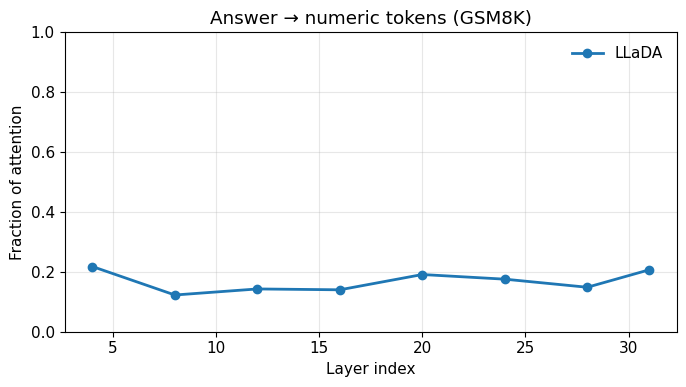

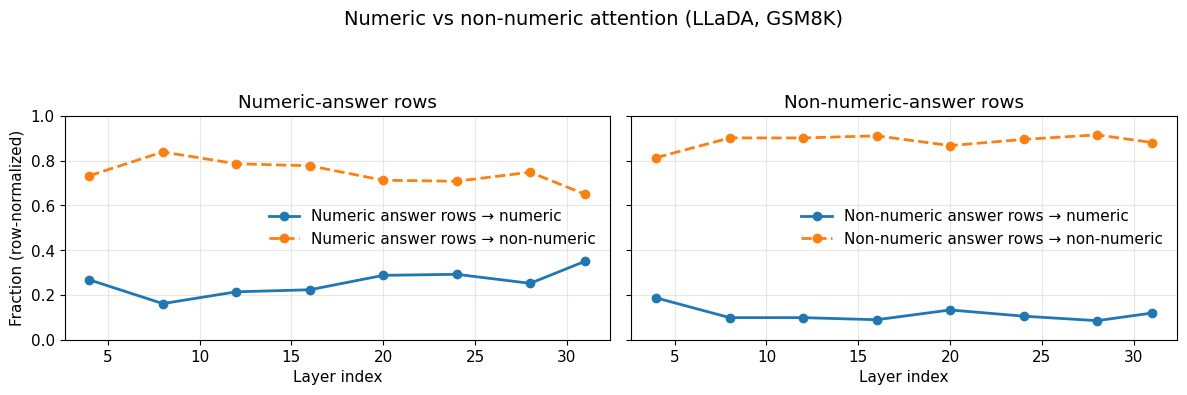

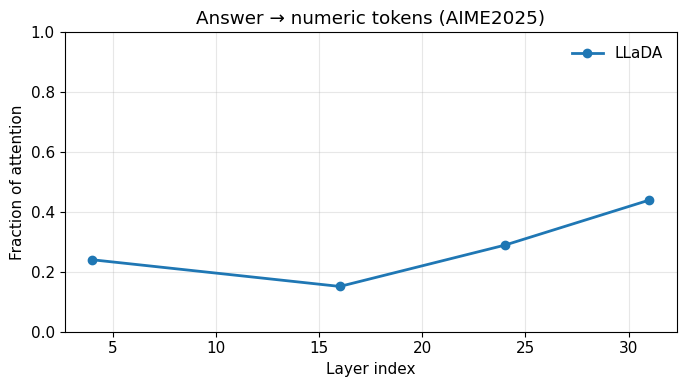

/tmp/ipython-input-1530712432.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(frameon=False)


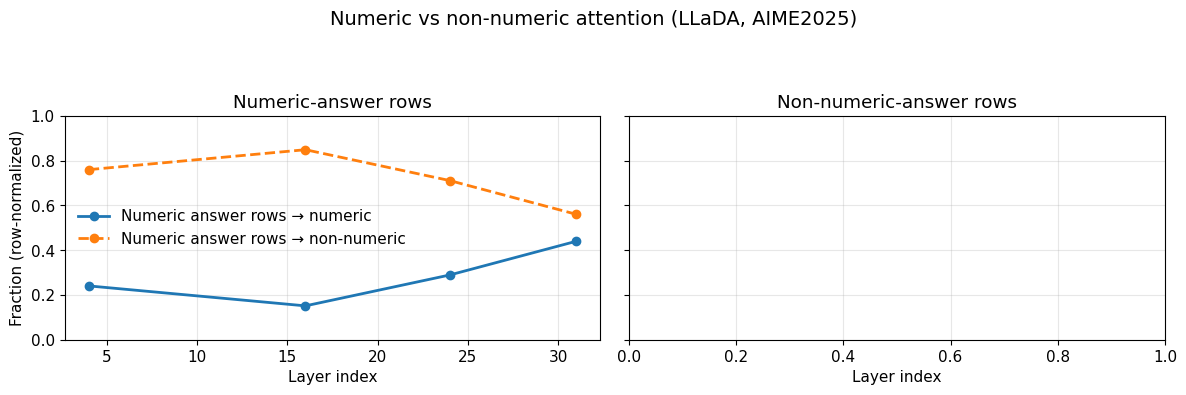

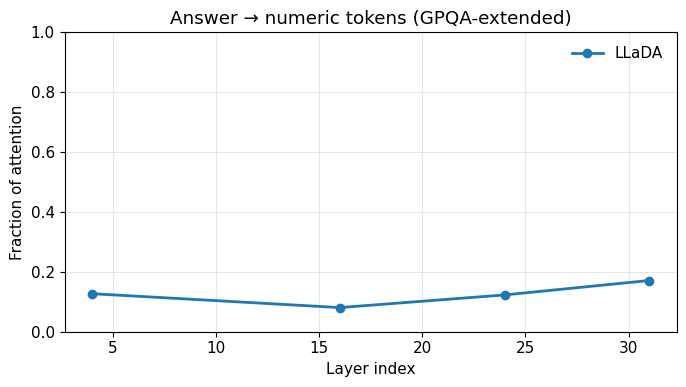

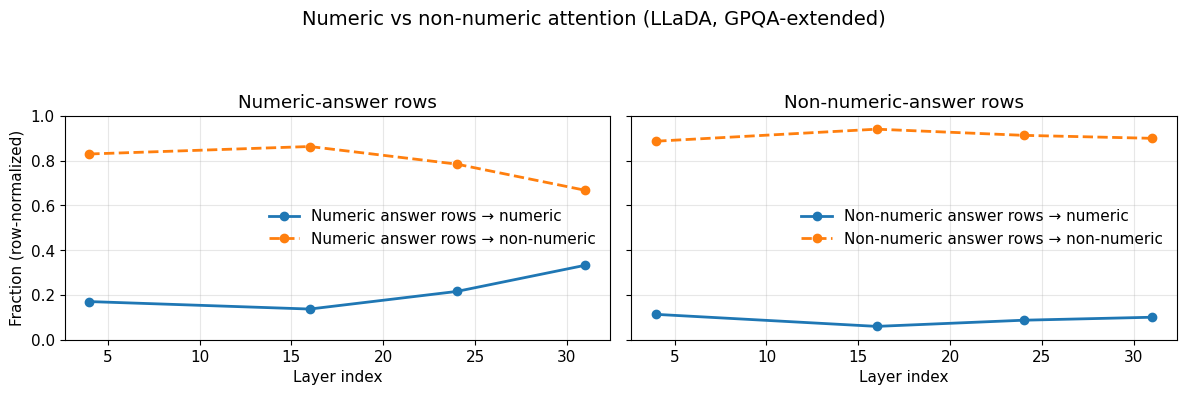

In [ ]:
plot_numeric_attention_dataset(num_gsm,  dataset_name="GSM8K")
plot_numeric_attention_dataset(num_aime, dataset_name="AIME2025")
plot_numeric_attention_dataset(num_gpqa, dataset_name="GPQA-extended")

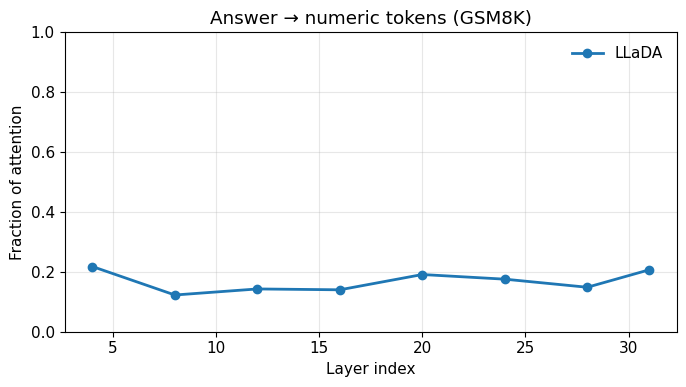

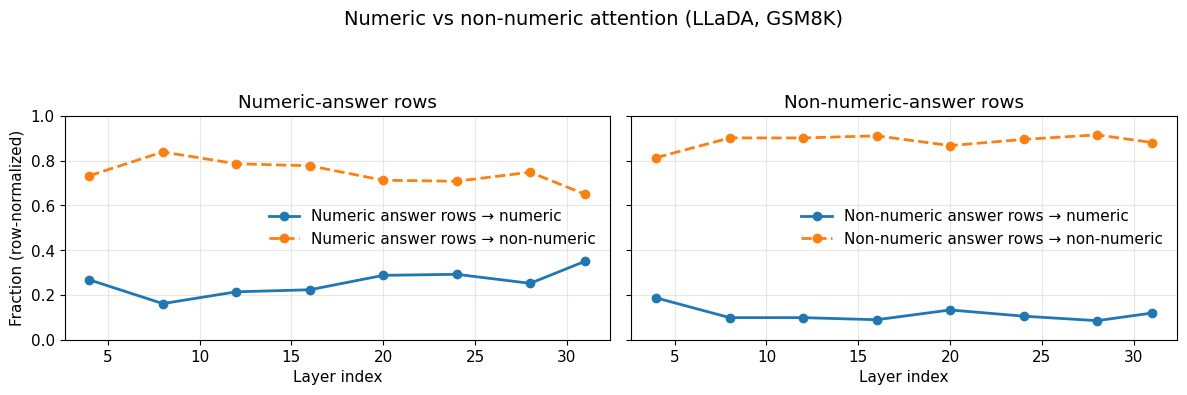

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==== paste your dict here ====
num_example_stats = {
    'ans_to_numeric_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
      'mean': [0.21777167916297913,
       0.1226499006152153,
       0.1428736448287964,
       0.14000901579856873,
       0.1910409778356552,
       0.17552179098129272,
       0.14851632714271545,
       0.20676207542419434],
      'std': [0.048237401992082596,
       0.026579486206173897,
       0.030764643102884293,
       0.027913333848118782,
       0.03529481589794159,
       0.03501544147729874,
       0.03130460903048515,
       0.040422115474939346]},
    'num2num_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
      'mean': [0.2676282525062561,
       0.16131895780563354,
       0.21404287219047546,
       0.2231132686138153,
       0.2875896394252777,
       0.2921609878540039,
       0.2518252432346344,
       0.35088086128234863],
      'std': [0.04734085872769356,
       0.026514029130339622,
       0.028584472835063934,
       0.02509951777756214,
       0.027502326294779778,
       0.02715633250772953,
       0.02895309031009674,
       0.03218410164117813]},
    'num2non_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
      'mean': [0.7323716878890991,
       0.8386809825897217,
       0.7859571576118469,
       0.7768867015838623,
       0.7124103903770447,
       0.7078390121459961,
       0.748174786567688,
       0.6491190791130066],
      'std': [0.04734085872769356,
       0.026514029130339622,
       0.028584470972418785,
       0.02509951964020729,
       0.027502328157424927,
       0.02715633250772953,
       0.02895309031009674,
       0.03218410164117813]},
    'non2num_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
      'mean': [0.18676775693893433,
       0.09856735914945602,
       0.09866639226675034,
       0.0893283486366272,
       0.13289141654968262,
       0.10523904860019684,
       0.08509747684001923,
       0.11929553747177124],
      'std': [0.03922870755195618,
       0.019360912963747978,
       0.019036319106817245,
       0.01632888801395893,
       0.024416839703917503,
       0.02160457707941532,
       0.01661229506134987,
       0.021158134564757347]},
    'non2non_frac': {'layer': [4, 8, 12, 16, 20, 24, 28, 31],
      'mean': [0.8132322430610657,
       0.9014326333999634,
       0.9013335704803467,
       0.9106716513633728,
       0.8671085834503174,
       0.8947609663009644,
       0.9149025082588196,
       0.8807044625282288],
      'std': [0.03922870755195618,
       0.01936091110110283,
       0.019036319106817245,
       0.01632888801395893,
       0.024416839703917503,
       0.02160457707941532,
       0.016612296923995018,
       0.021158132702112198]}
}

# ── small helper ──
def _get_layers_and_means_single(num_stats, key):
    stat = num_stats[key]
    layers_raw = stat.get("layer", [])
    means_raw  = stat.get("mean", [])
    layers, means = [], []
    for L, m in zip(layers_raw, means_raw):
        if m is None:
            continue
        m_val = float(m)
        if np.isnan(m_val):
            continue
        layers.append(int(L))
        means.append(m_val)
    return layers, means

# ── LLaDA-only numeric attention plots ──
def plot_numeric_attention_llada(num_llada, dataset_name="GSM8K"):
    # 1) Answer → numeric fraction
    fig, ax = plt.subplots(figsize=(7, 4))
    layers, llada_means = _get_layers_and_means_single(num_llada, "ans_to_numeric_frac")

    if layers:
        ax.plot(layers, llada_means, marker="o", linewidth=2, label="LLaDA")

    ax.set_title(f"Answer → numeric tokens ({dataset_name})")
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Fraction of attention")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # 2) Numeric vs non-numeric in numeric / non-numeric answer rows
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    # Numeric answer rows
    for key, label, ax_ in [
        ("num2num_frac", "Numeric answer rows → numeric", axes[0]),
        ("num2non_frac", "Numeric answer rows → non-numeric", axes[0]),
    ]:
        layers, means = _get_layers_and_means_single(num_llada, key)
        if not layers:
            continue
        style = "-" if "num2num" in key else "--"
        ax_.plot(layers, means, marker="o", linestyle=style, linewidth=2,
                 label=label)

    axes[0].set_title("Numeric-answer rows")
    axes[0].set_xlabel("Layer index")
    axes[0].set_ylabel("Fraction (row-normalized)")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(frameon=False)

    # Non-numeric answer rows
    for key, label, ax_ in [
        ("non2num_frac", "Non-numeric answer rows → numeric", axes[1]),
        ("non2non_frac", "Non-numeric answer rows → non-numeric", axes[1]),
    ]:
        layers, means = _get_layers_and_means_single(num_llada, key)
        if not layers:
            continue
        style = "-" if "non2num" in key else "--"
        ax_.plot(layers, means, marker="o", linestyle=style, linewidth=2,
                 label=label)

    axes[1].set_title("Non-numeric-answer rows")
    axes[1].set_xlabel("Layer index")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(frameon=False)

    fig.suptitle(f"Numeric vs non-numeric attention (LLaDA, {dataset_name})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

# actually plot it:
plot_numeric_attention_llada(num_example_stats, dataset_name="GSM8K")

### Helper to extract layer/mean for a single metric

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _get_layers_and_means_single_stat(stat_dict, key):
    """
    stat_dict[key] is like:
      { "layer": [...], "mean": [...], "std": [...] }
    Returns (layers, means) with NaNs filtered out.
    """
    entry = stat_dict[key]
    layers_raw = entry.get("layer", [])
    means_raw  = entry.get("mean", [])
    layers, means = [], []
    for L, m in zip(layers_raw, means_raw):
        if m is None:
            continue
        m_val = float(m)
        if np.isnan(m_val):
            continue
        layers.append(int(L))
        means.append(m_val)
    return layers, means

2. LLaDA-only quadrant flow plots

In [ ]:
def plot_quadrant_flows_llada(quad_llada, dataset_name="GSM8K"):
    """
    quad_llada: dict from aggregate_quadrant_and_numeric_over_dataset(...)
      e.g. quad_llada["p2p"] = {layer, mean, std}, etc.

    Produces:
      - 2x2 grid for P→P, P→A, A→P, A→A
      - 1 plot for answer-conditioned A→P / A→A
    """

    quadrant_keys = ["p2p", "p2a", "a2p", "a2a"]
    labels = {
        "p2p": "Prompt → Prompt",
        "p2a": "Prompt → Answer",
        "a2p": "Answer → Prompt",
        "a2a": "Answer → Answer",
    }

    # ---- 2x2 grid: global quadrant fractions ----
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
    axes = axes.ravel()

    for ax, key in zip(axes, quadrant_keys):
        layers, means = _get_layers_and_means_single_stat(quad_llada, key)
        if not layers:
            ax.set_title(f"{labels[key]} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        ax.plot(layers, means, marker="o", linewidth=2, label="LLaDA")

        ax.set_title(labels[key])
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Quadrant flows vs decoder layer (LLaDA, {dataset_name})", fontsize=14)
    for ax in axes:
        ax.set_xlabel("Layer index")
        ax.set_ylabel("Fraction")

    # One legend for all subplots
    handles, labels_ = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="upper center", ncol=1, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    # ---- Answer-conditioned A→P / A→A ----
    fig, ax = plt.subplots(figsize=(7, 4))

    for key, label in [("a2p_cond", "Answer → Prompt (cond)"),
                       ("a2a_cond", "Answer → Answer (cond)")]:
        if key not in quad_llada:
            continue
        layers, means = _get_layers_and_means_single_stat(quad_llada, key)
        if not layers:
            continue
        style = "-" if "a2p" in key else "--"
        ax.plot(layers, means, marker="o", linestyle=style, linewidth=2, label=label)

    ax.set_title(f"Answer-conditioned quadrant flows (LLaDA, {dataset_name})")
    ax.set_xlabel("Layer index")
    ax.set_ylabel("Fraction (0–1)")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

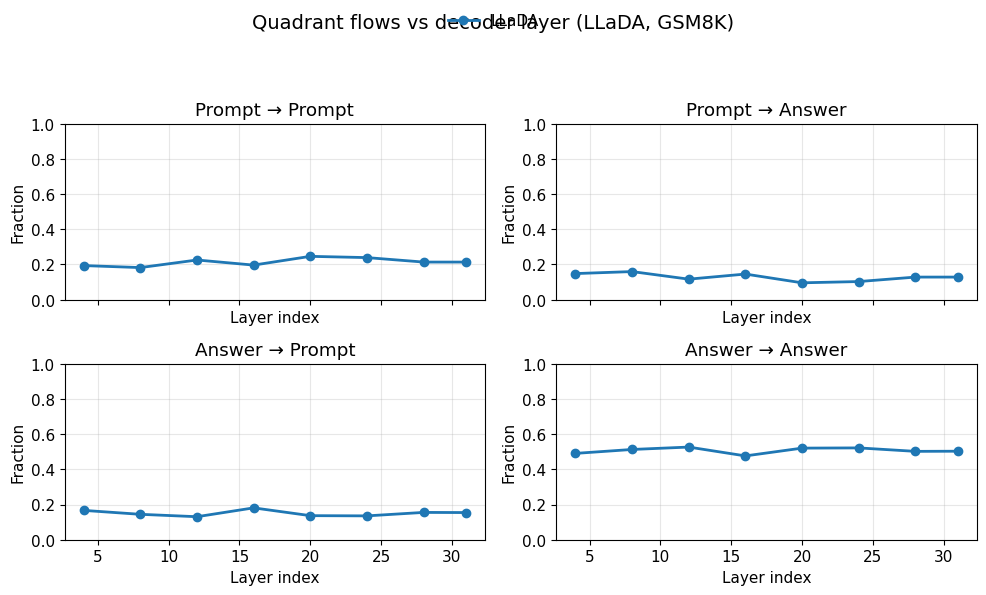

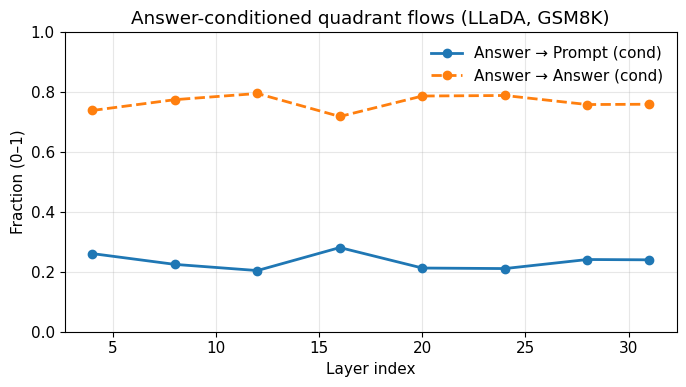

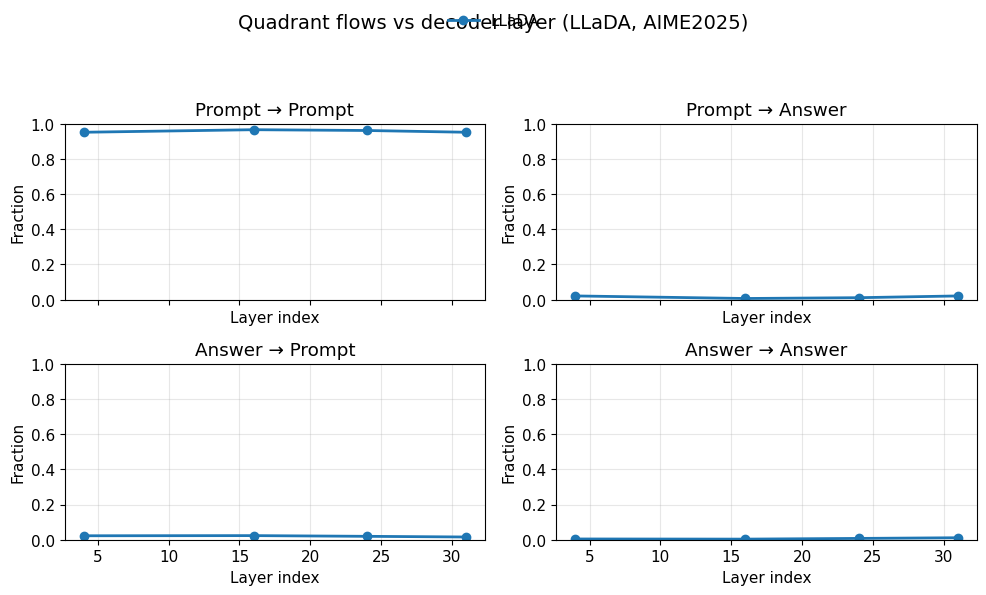

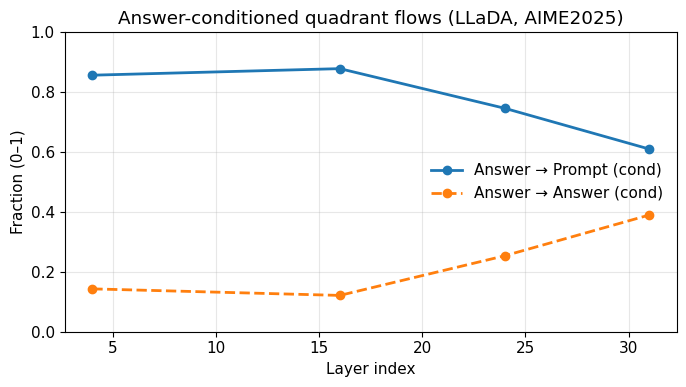

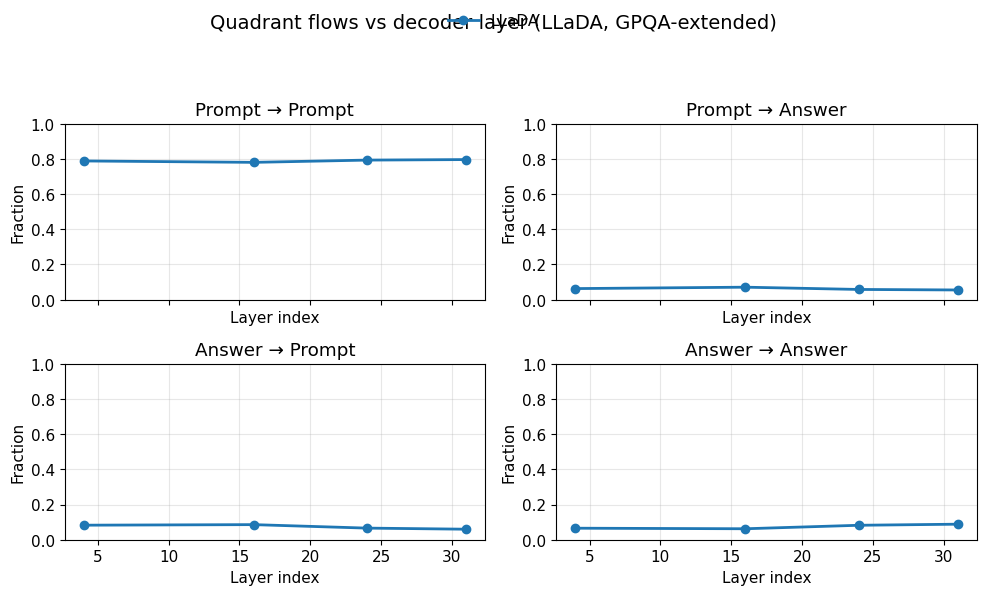

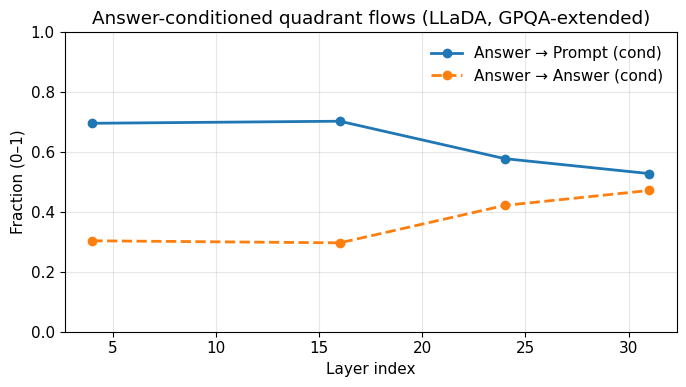

In [ ]:
# Example: GSM8K
plot_quadrant_flows_llada(quad_gsm, dataset_name="GSM8K")

# Example: AIME2025
plot_quadrant_flows_llada(quad_aime, dataset_name="AIME2025")

# Example: GPQA-extended
plot_quadrant_flows_llada(quad_gpqa, dataset_name="GPQA-extended")

## Correct vs. incorrect analysis

### Simple Correctness check

In [ ]:
import torch

@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 256,
    temperature: float = 0.0,
    top_p: float = 1.0,
    top_k: int = 0,
    do_sample: bool | None = None,
    stop_strings: list[str] | None = None,
    device: str | None = None,
):
    """
    Simple text generation helper.

    Returns:
      completion_text: decoded new tokens (without the prompt)
      full_text:       prompt + completion
      full_ids:        tensor of token ids (prompt+completion) on CPU
    """
    if device is None:
        device = next(model.parameters()).device

    enc = tokenizer(prompt, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attn_mask = enc.get("attention_mask", torch.ones_like(input_ids)).to(device)

    if do_sample is None:
        do_sample = temperature > 0.0

    gen_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attn_mask,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        do_sample=do_sample,
        top_p=top_p,
        top_k=top_k,
        pad_token_id=tokenizer.eos_token_id,
    )

    # Split prompt vs completion
    prompt_len = input_ids.shape[1]
    completion_ids = gen_ids[0, prompt_len:]

    completion_text = tokenizer.decode(completion_ids, skip_special_tokens=True)
    full_text = tokenizer.decode(gen_ids[0], skip_special_tokens=True)

    # Optional stopping on custom strings
    if stop_strings:
        for s in stop_strings:
            idx = completion_text.find(s)
            if idx != -1:
                completion_text = completion_text[:idx]
                break

    return completion_text, full_text, gen_ids.cpu()

In [ ]:
import re
import numpy as np
import torch

# --- numeric extraction for GSM8K / AIME / LLaDA generations ---

def extract_final_int_from_text(s: str):
    """
    Try to pull the final integer answer from a solution string.
    1) Prefer GSM8K-style '#### 18'
    2) Otherwise take the last integer in the text.
    Returns int or None.
    """
    if s is None:
        return None
    # GSM8K style
    m = re.search(r'####\s*(-?\d+)', s)
    if m:
        return int(m.group(1))
    # fallback: last integer anywhere
    nums = re.findall(r'-?\d+', s)
    if not nums:
        return None
    return int(nums[-1])


def is_prediction_correct(ds_name: str, ex, gold_answer_str: str, pred_str: str) -> bool:
    """
    Very lightweight correctness check.
    - gsm8k_test: compare final integers (#### 18 style)
    - aime2025: HF 'answer' field is already numeric
    - gpqa_extended: check if gold answer string appears in prediction
    You can replace these rules with your Parser / is_equiv logic.
    """
    if ds_name == "gsm8k_test":
        gold = extract_final_int_from_text(gold_answer_str)
        pred = extract_final_int_from_text(pred_str)
        return (gold is not None) and (pred == gold)

    elif ds_name == "aime2025":
        # HF MathArena/aime_2025: ex["answer"] is numeric
        try:
            gold = int(ex["answer"])
        except Exception:
            gold = extract_final_int_from_text(gold_answer_str)
        pred = extract_final_int_from_text(pred_str)
        return (gold is not None) and (pred == gold)

    elif ds_name == "gpqa_extended":
        # Idavidrein/gpqa: we treat 'Correct Answer' string as label
        gold = str(ex["Correct Answer"]).strip().lower()
        return gold != "" and gold in pred_str.lower()

    else:
        # default: string containment
        return gold_answer_str.strip().lower() in pred_str.lower()

## Llada generate for a single question

In [ ]:
def llada_generate_answer_once(
    model,
    tokenizer,
    question_str: str,
    gen_length: int = 128,
    steps: int = 64,
    block_length: int = 32,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    device=None,
):
    """
    Build a simple chat-style prompt from question_str, run LLaDA diffusion generation,
    and return (prompt_str, generation_str).
    """
    if device is None:
        device = next(model.parameters()).device

    # Minimal system prompt – you can swap to your GSM_SYSTEM_PROMPT etc.
    messages = [
        {"role": "user", "content": question_str}
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    )

    with torch.no_grad():
        enc = tokenizer(prompt_str, return_tensors="pt").to(device)
        input_ids = enc["input_ids"]  # [1, T_prompt]

        full_ids = generate(
            model,
            input_ids,
            tokenizer,
            steps=steps,
            gen_length=gen_length,
            block_length=block_length,
            temperature=temperature,
            cfg_scale=cfg_scale,
            remasking="low_confidence",
        )

        # keep only the generated suffix
        gen_ids = full_ids[:, input_ids.size(1):]
        gen_text = tokenizer.batch_decode(
            gen_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True,
        )[0]

    return prompt_str, gen_text


4. Per‑example attention metrics (reuse your probe)

In [ ]:
# If you already defined this earlier, just reuse it.
def llada_attention_probes_for_qa(
    model,
    tokenizer,
    question_str: str,
    answer_str: str,
    layers_to_probe,
    device=None,
):
    """
    Returns: dict[layer_idx] -> {
        "bi": float,
        "entropy": float,
        "ali": float,
        "frac_prompt": float,
    }
    using the same definitions as in attention_map_study.ipynb.
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    with torch.no_grad():
        # tokenize question and answer separately (no special tokens)
        q_enc = tokenizer(question_str, add_special_tokens=False, return_tensors="pt")
        a_enc = tokenizer(" " + answer_str, add_special_tokens=False, return_tensors="pt")

        q_ids = q_enc["input_ids"].to(device)  # [1, T_q]
        a_ids = a_enc["input_ids"].to(device)  # [1, T_a]

        full_ids = torch.cat([q_ids, a_ids], dim=1)  # [1, T]
        prompt_len = q_ids.size(1)
        gen_len = a_ids.size(1)

        metrics = {}
        for layer_idx in layers_to_probe:
            attn = get_llada_layer_attn(model, full_ids, layer_idx=layer_idx)  # [1, H, T, T]

            bi = compute_bidirectionality_index(attn, prompt_len, gen_len).mean().item()
            ent = compute_attention_entropy(attn, prompt_len, gen_len).mean().item()
            ali = compute_attention_localization_index(attn, prompt_len, gen_len).mean().item()
            frac_p = compute_frac_prompt(attn, prompt_len, gen_len).mean().item()

            metrics[layer_idx] = {
                "bi": bi,
                "entropy": ent,
                "ali": ali,
                "frac_prompt": frac_p,
            }

    return metrics

5. Main loop: metrics split by correct vs incorrect

In [ ]:
from collections import defaultdict
from tqdm import tqdm

def run_llada_correct_vs_incorrect_on_dataset(
    model,
    tokenizer,
    ds,
    ds_name: str,
    layers_to_probe,
    max_examples: int = 256,
    gen_length: int = 128,
    steps: int = 64,
    block_length: int = 32,
    device=None,
):
    """
    For each example:
      - generate with LLaDA
      - check correctness
      - compute attention metrics on (question, GOLD answer)
      - bucket metrics by correct / incorrect

    Returns:
      stats_ci: {
        "correct": {
           "frac_prompt": {"layer": [...], "mean": [...], "std": [...]},
           "entropy":    { ... },
        },
        "incorrect": { ... },
      }
      correct_idxs:   list[int]
      incorrect_idxs: list[int]
    """
    if device is None:
        device = next(model.parameters()).device

    # raw accumulators: stats[bucket][layer][metric] -> list[float]
    buckets = ["correct", "incorrect"]
    metrics_names = ["frac_prompt", "entropy"]

    stats_raw = {
        b: {layer: {m: [] for m in metrics_names} for layer in layers_to_probe}
        for b in buckets
    }
    correct_idxs, incorrect_idxs = [], []

    model.eval()

    for i, ex in enumerate(tqdm(ds, desc=f"{ds_name} correct vs incorrect")):
        if i >= max_examples:
            break

        # 1) extract (question, gold answer) from HF row
        q_str, a_str = extract_qa_from_example(ds_name, ex)
        if not q_str or not a_str:
            continue

        # 2) generate once with LLaDA
        _, gen_str = llada_generate_answer_once(
            model,
            tokenizer,
            q_str,
            gen_length=gen_length,
            steps=steps,
            block_length=block_length,
            device=device,
        )

        # 3) correctness
        is_corr = is_prediction_correct(ds_name, ex, a_str, gen_str)
        bucket = "correct" if is_corr else "incorrect"
        (correct_idxs if is_corr else incorrect_idxs).append(i)

        # 4) attention metrics on (q, GOLD answer)
        metrics = llada_attention_probes_for_qa(
            model,
            tokenizer,
            q_str,
            a_str,
            layers_to_probe=layers_to_probe,
            device=device,
        )

        for layer_idx in layers_to_probe:
            stats_raw[bucket][layer_idx]["frac_prompt"].append(
                metrics[layer_idx]["frac_prompt"]
            )
            stats_raw[bucket][layer_idx]["entropy"].append(
                metrics[layer_idx]["entropy"]
            )

    # 5) aggregate -> layerwise mean/std for each bucket + metric
    stats_ci = {
        b: {
            m: {"layer": [], "mean": [], "std": []}
            for m in metrics_names
        }
        for b in buckets
    }

    for b in buckets:
        for layer_idx in layers_to_probe:
            for m in metrics_names:
                arr = np.array(stats_raw[b][layer_idx][m], dtype=float)
                if arr.size == 0:
                    mean = float("nan")
                    std = float("nan")
                else:
                    mean = float(arr.mean())
                    std = float(arr.std(ddof=0))

                stats_ci[b][m]["layer"].append(layer_idx)
                stats_ci[b][m]["mean"].append(mean)
                stats_ci[b][m]["std"].append(std)

    return stats_ci, correct_idxs, incorrect_idxs

In [ ]:
# Quick sanity check on GSM8K
ds_gsm = load_hf_dataset("gsm8k_test")

[load] gsm8k_test <- openai/gsm8k (config=main, split=test)
  -> 1319 examples, fields: ['question', 'answer']


In [ ]:
DATASETS_INFO = {
    # GSM8K test split, "main" config
    "gsm8k_test": {
        "hf": "openai/gsm8k",
        "config": "main",
        "split": "test",
    },
    # AIME2025 – MathArena version
    "aime2025": {
        "hf": "MathArena/aime_2025",
        "config": None,
        "split": "train",
    },
    # GPQA extended (uses 'gpqa_extended' config, split is *train*)
    "gpqa_extended": {
        "hf": "Idavidrein/gpqa",
        "config": "gpqa_extended",
        "split": "train",   # correct: GPQA only has 'train' split
    },
}

In [ ]:
# ds_gpqa = load_hf_dataset("gpqa_extended")
ds_aime = load_hf_dataset("aime2025")

[load] aime2025 <- MathArena/aime_2025 (config=None, split=train)
  -> 30 examples, fields: ['problem_idx', 'problem', 'answer', 'problem_type']


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import torch.distributed as dist

# ------------------ helpers ------------------ #

def gumbel_max_sample(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    Gumbel-Max sampling:
      argmax( (logits / T) + Gumbel(0,1) )
    If temperature <= 0, falls back to greedy argmax(logits).
    """
    if temperature is None or temperature <= 0.0:
        return logits.argmax(dim=-1)

    logits = logits.float() / max(1e-6, float(temperature))
    u = torch.rand_like(logits, dtype=torch.float32).clamp_(1e-6, 1.0 - 1e-6)
    g = -torch.log(-torch.log(u))
    return (logits + g).argmax(dim=-1)


def apply_top_k_top_p(logits: torch.Tensor, top_k: int = 0, top_p: float = 0.0) -> torch.Tensor:
    """
    Filter logits with top-k and/or top-p. Returns filtered logits (float32).
    """
    logits = logits.float()

    # top-k
    if top_k and top_k > 0:
        v, _ = torch.topk(logits, top_k, dim=-1)
        cut = v[..., -1, None]
        logits = torch.where(logits < cut, torch.full_like(logits, -float("inf")), logits)

    # top-p
    if top_p and top_p > 0.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
        probs = torch.softmax(sorted_logits, dim=-1)
        cumprobs = probs.cumsum(dim=-1)
        cutoff = cumprobs > top_p
        cutoff[..., 0] = False
        sorted_logits[cutoff] = -float("inf")

        # scatter back
        logits = torch.full_like(logits, -float("inf"))
        logits.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)

    return logits


def repetition_penalize_logits(
    logits: torch.Tensor,
    seq: torch.Tensor,
    penalty: float = 1.0,
) -> torch.Tensor:
    """
    Lightweight repetition penalty: >1.0 discourages re-using tokens already in seq.
    Implemented by dividing logits of seen tokens by `penalty`.
    """
    if penalty is None or penalty <= 1.0:
        return logits

    logits = logits.float()
    B, T = seq.shape
    V = logits.size(-1)

    # mask of tokens present in each sequence (approx; O(B*T))
    seen = torch.zeros((B, V), device=seq.device, dtype=torch.bool)
    seen.scatter_(1, seq, True)                   # [B, V]
    seen = seen.unsqueeze(1).expand(-1, logits.size(1), -1)  # [B, T, V]

    logits = torch.where(seen, logits / penalty, logits)
    return logits


# ------------------ diffusion-style generate ------------------ #

@torch.no_grad()
def generate(
    model,
    prompt: torch.Tensor,       # [B, T_prompt] int64 ids
    tokenizer,                  # kept for API symmetry, not used here
    steps: int = 64,
    gen_length: int = 128,
    block_length: int = 32,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    remasking: str = "low_confidence",   # or "random"
    mask_id: int = 126336,
    top_k: int = 0,
    top_p: float = 0.0,
    rep_penalty: float = 1.0,
):
    """
    Masked diffusion-style generation (block-wise) for LLaDA:

      - Start with the prompt, then a window of `gen_length` masked with mask_id.
      - Split the generation window into `gen_length / block_length` blocks.
      - For each block, run `steps_per_block = steps / num_blocks` diffusion updates:
          * run the model on the current masked sequence
          * choose tokens via Gumbel-Max sampling
          * compute confidences
          * reveal the top-k masked positions according to confidence

    Returns:
      x: [B, T_prompt + gen_length] int64 token ids.
    """
    device = next(model.parameters()).device
    prompt = prompt.to(device)

    B, T_prompt = prompt.shape

    # Full sequence buffer: prompt + generation window (all masked initially)
    x = torch.full(
        (B, T_prompt + gen_length),
        mask_id,
        dtype=torch.long,
        device=device,
    )
    x[:, :T_prompt] = prompt.clone()

    # boolean index of prompt (non-masked) positions
    prompt_index = x != mask_id

    assert gen_length % block_length == 0, "gen_length must be divisible by block_length"
    num_blocks = gen_length // block_length
    steps_per_block = max(1, steps // num_blocks)

    # loop over generation blocks
    for b in tqdm(
        range(num_blocks),
        disable=(dist.is_available() and dist.is_initialized() and dist.get_rank() != 0),
        desc=f"Eval (len={gen_length}, steps={steps})",
    ):
        start_idx = T_prompt + b * block_length
        end_idx   = T_prompt + (b + 1) * block_length

        # positions of masks in current block [B, block_length]
        block_mask_index = x[:, start_idx:end_idx] == mask_id
        mask_num = block_mask_index.sum(dim=1, keepdim=True)  # [B, 1]

        # how many tokens to "reveal" per inner step for each sequence
        steps_per_block = max(1, steps_per_block)
        base = mask_num // steps_per_block
        rem  = mask_num %  steps_per_block       # remainder

        num_transfer_tokens = base.expand(-1, steps_per_block).clone()
        if (rem > 0).any():
            idx = torch.arange(steps_per_block, device=device).unsqueeze(0)
            add = (idx < rem).to(num_transfer_tokens.dtype)
            num_transfer_tokens += add

        # diffusion inner loop for this block
        for i in range(steps_per_block):
            mask_index = x == mask_id  # [B, T_prompt + gen_length]

            # ---- classifier-free guidance ----
            if cfg_scale and cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_cat = torch.cat([x, un_x], dim=0)     # [2B, T]
                outputs = model(x_cat)
                logits, un_logits = torch.chunk(outputs.logits, 2, dim=0)
                logits = (un_logits + (cfg_scale + 1.0) * (logits - un_logits)).float()
            else:
                outputs = model(x)
                logits = outputs.logits.float()         # [B, T, V]

            # repetition penalty
            logits = repetition_penalize_logits(logits, x, penalty=rep_penalty)

            # top-k / top-p filtering
            logits = apply_top_k_top_p(logits, top_k=top_k, top_p=top_p)

            # sample token ids
            x0 = gumbel_max_sample(logits, temperature=temperature)  # [B, T]

            # confidence scores
            if remasking == "low_confidence":
                smx = torch.softmax(logits, dim=-1)
                x0_p = torch.gather(smx, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)  # [B, T]
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float32)
            else:
                raise NotImplementedError(f"Unknown remasking mode: {remasking}")

            # don't transfer outside this block
            x0_p[:, end_idx:] = -float("inf")

            # only update masked positions
            x0   = torch.where(mask_index, x0, x)
            conf = torch.where(mask_index, x0_p, torch.full_like(x0_p, -float("inf")))

            # pick top-k positions per sequence to reveal
            for j in range(B):
                k = int(num_transfer_tokens[j, i].item())
                if k <= 0:
                    continue
                vals, idxs = torch.topk(conf[j], k=k, dim=-1)
                x[j, idxs] = x0[j, idxs]

    return x

In [ ]:
import math

In [ ]:
## Generate latest
import torch
import torch.nn.functional as F
from tqdm import tqdm
import torch.distributed as dist

# ------------------ helpers ------------------ #

def gumbel_max_sample(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    """
    Gumbel-Max sampling:
      argmax( (logits / T) + Gumbel(0,1) )
    If temperature <= 0, falls back to greedy argmax(logits).
    """
    if temperature is None or temperature <= 0.0:
        return logits.argmax(dim=-1)

    logits = logits.float() / max(1e-6, float(temperature))
    u = torch.rand_like(logits, dtype=torch.float32).clamp_(1e-6, 1.0 - 1e-6)
    g = -torch.log(-torch.log(u))
    return (logits + g).argmax(dim=-1)


def apply_top_k_top_p(logits: torch.Tensor, top_k: int = 0, top_p: float = 0.0) -> torch.Tensor:
    """
    Filter logits with top-k and/or top-p. Returns filtered logits (float32).
    """
    logits = logits.float()

    # top-k
    if top_k and top_k > 0:
        v, _ = torch.topk(logits, top_k, dim=-1)
        cut = v[..., -1, None]
        logits = torch.where(logits < cut, torch.full_like(logits, -float("inf")), logits)

    # top-p
    if top_p and top_p > 0.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
        probs = torch.softmax(sorted_logits, dim=-1)
        cumprobs = probs.cumsum(dim=-1)
        cutoff = cumprobs > top_p
        cutoff[..., 0] = False
        sorted_logits[cutoff] = -float("inf")

        # scatter back
        logits = torch.full_like(logits, -float("inf"))
        logits.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)

    return logits


def repetition_penalize_logits(
    logits: torch.Tensor,
    seq: torch.Tensor,
    penalty: float = 1.0,
) -> torch.Tensor:
    """
    Lightweight repetition penalty: >1.0 discourages re-using tokens already in seq.
    Implemented by dividing logits of seen tokens by `penalty`.
    """
    if penalty is None or penalty <= 1.0:
        return logits

    logits = logits.float()
    B, T = seq.shape
    V = logits.size(-1)

    # mask of tokens present in each sequence (approx; O(B*T))
    seen = torch.zeros((B, V), device=seq.device, dtype=torch.bool)
    seen.scatter_(1, seq, True)                   # [B, V]
    seen = seen.unsqueeze(1).expand(-1, logits.size(1), -1)  # [B, T, V]

    logits = torch.where(seen, logits / penalty, logits)
    return logits


# ------------------ diffusion-style generate ------------------ #
@torch.no_grad()
def generate(
    model,
    prompt: torch.Tensor,       # [B, T_prompt] int64 ids
    tokenizer,                  # kept for API symmetry, not used here
    steps: int = 64,
    gen_length: int = 128,
    block_length: int = 32,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    remasking: str = "low_confidence",   # or "random"
    mask_id: int = 126336,
    top_k: int = 0,
    top_p: float = 0.0,
    rep_penalty: float = 1.0,
):
    """
    Masked diffusion-style generation (block-wise) for LLaDA:

      - Start with the prompt, then a window of `gen_length` masked with mask_id.
      - Split the generation window into `gen_length / block_length` blocks.
      - For each block, run `steps_per_block = steps / num_blocks` diffusion updates:
          * run the model on the current masked sequence
          * choose tokens via Gumbel-Max sampling
          * compute confidences
          * reveal the top-k masked positions according to confidence

    Returns:
      x: [B, T_prompt + gen_length] int64 token ids.
    """
    device = next(model.parameters()).device
    prompt = prompt.to(device)

    B, T_prompt = prompt.shape

    # Full sequence buffer: prompt + generation window (all masked initially)
    x = torch.full(
        (B, T_prompt + gen_length),
        mask_id,
        dtype=torch.long,
        device=device,
    )
    x[:, :T_prompt] = prompt.clone()

    # boolean index of prompt (non-masked) positions
    prompt_index = x != mask_id

    assert gen_length % block_length == 0, "gen_length must be divisible by block_length"
    num_blocks = gen_length // block_length
    steps_per_block = max(1, steps // num_blocks)

    # loop over generation blocks
    for b in tqdm(
        range(num_blocks),
        disable=(dist.is_available() and dist.is_initialized() and dist.get_rank() != 0),
        desc=f"Eval (len={gen_length}, steps={steps})",
    ):
        start_idx = T_prompt + b * block_length
        end_idx   = T_prompt + (b + 1) * block_length

        # positions of masks in current block [B, block_length]
        block_mask_index = x[:, start_idx:end_idx] == mask_id
        mask_num = block_mask_index.sum(dim=1, keepdim=True)  # [B, 1]

        # how many tokens to "reveal" per inner step for each sequence
        steps_per_block = max(1, steps_per_block)
        base = mask_num // steps_per_block
        rem  = mask_num %  steps_per_block       # remainder

        num_transfer_tokens = base.expand(-1, steps_per_block).clone()
        if (rem > 0).any():
            idx = torch.arange(steps_per_block, device=device).unsqueeze(0)
            add = (idx < rem).to(num_transfer_tokens.dtype)
            num_transfer_tokens += add

        # diffusion inner loop for this block
        for i in range(steps_per_block):
            mask_index = x == mask_id  # [B, T_prompt + gen_length]

            # ---- classifier-free guidance ----
            if cfg_scale and cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_cat = torch.cat([x, un_x], dim=0)     # [2B, T]
                outputs = model(x_cat)
                logits, un_logits = torch.chunk(outputs.logits, 2, dim=0)
                logits = (un_logits + (cfg_scale + 1.0) * (logits - un_logits)).float()
            else:
                outputs = model(x)
                logits = outputs.logits.float()         # [B, T, V]

            # repetition penalty
            logits = repetition_penalize_logits(logits, x, penalty=rep_penalty)

            # top-k / top-p filtering
            logits = apply_top_k_top_p(logits, top_k=top_k, top_p=top_p)

            # sample token ids
            x0 = gumbel_max_sample(logits, temperature=temperature)  # [B, T]

            # confidence scores
            if remasking == "low_confidence":
                smx = torch.softmax(logits, dim=-1)
                x0_p = torch.gather(smx, dim=-1, index=x0.unsqueeze(-1)).squeeze(-1)  # [B, T]
            elif remasking == "random":
                x0_p = torch.rand_like(x0, dtype=torch.float32)
            else:
                raise NotImplementedError(f"Unknown remasking mode: {remasking}")

            # don't transfer outside this block
            x0_p[:, end_idx:] = -float("inf")

            # only update masked positions
            x0   = torch.where(mask_index, x0, x)
            conf = torch.where(mask_index, x0_p, torch.full_like(x0_p, -float("inf")))

            # pick top-k positions per sequence to reveal
            for j in range(B):
                k = int(num_transfer_tokens[j, i].item())
                if k <= 0:
                    continue
                vals, idxs = torch.topk(conf[j], k=k, dim=-1)
                x[j, idxs] = x0[j, idxs]

    return x

In [ ]:
# Hyper-params
steps_list      = [16, 32, 64, 256]
gen_length      = 256          # constant across all runs
block_length    = 32
layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]
device          = mdl_llada.device

# Containers to store results
gsm_stats_by_steps   = {}
gsm_correct_by_steps = {}
gsm_incorrect_by_steps = {}

aime_stats_by_steps   = {}
aime_correct_by_steps = {}
aime_incorrect_by_steps = {}

gpqa_stats_by_steps   = {}
gpqa_correct_by_steps = {}
gpqa_incorrect_by_steps = {}

# ===================== GSM8K =====================
for steps in steps_list:
    print(f"\n================ GSM8K: steps = {steps}, gen_length = {gen_length} ================")
    stats_ci, correct_idxs, incorrect_idxs = run_llada_correct_vs_incorrect_on_dataset(
        mdl_llada,
        tok_llada,
        ds_gsm,
        ds_name="gsm8k_test",
        layers_to_probe=layers_to_probe,
        max_examples=100,        # you can lower to 256 if needed
        gen_length=gen_length,
        steps=steps,
        block_length=block_length,
        device=device,
    )
    gsm_stats_by_steps[steps]     = stats_ci
    gsm_correct_by_steps[steps]   = correct_idxs
    gsm_incorrect_by_steps[steps] = incorrect_idxs


================ GSM8K: steps = 16, gen_length = 256 ================


gsm8k_test correct vs incorrect:   8%|▊         | 100/1319 [01:47<21:55,  1.08s/it]



================ GSM8K: steps = 32, gen_length = 256 ================


gsm8k_test correct vs incorrect:   8%|▊         | 100/1319 [02:55<35:34,  1.75s/it]



================ GSM8K: steps = 64, gen_length = 256 ================


gsm8k_test correct vs incorrect:   8%|▊         | 100/1319 [05:07<1:02:32,  3.08s/it]



================ GSM8K: steps = 256, gen_length = 256 ================


gsm8k_test correct vs incorrect:   8%|▊         | 100/1319 [18:19<3:43:16, 10.99s/it]


In [ ]:
gsm_incorrect_by_steps

{16: [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  20,
  21,
  22,
  23,
  24,
  25,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  68,
  70,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  89,
  90,
  91,
  92,
  93,
  95,
  97,
  98,
  99],
 32: [2,
  5,
  7,
  8,
  9,
  12,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  23,
  24,
  28,
  30,
  32,
  34,
  35,
  38,
  39,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  50,
  51,
  53,
  60,
  61,
  62,
  63,
  64,
  68,
  70,
  72,
  73,
  74,
  75,
  76,
  78,
  79,
  83,
  84,
  85,
  86,
  87,
  89,
  90,
  95,
  97],
 64: [2,
  5,
  7,
  8,
  12,
  13,
  15,
  17,
  20,
  21,
  23,
  28,
  36,
  37,
  41,
  43,
  44,
  46,
  53,
  58,
  61,
  63,
  7

### Plot correct vs. incorrect

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_llada_gsm_metric_by_steps_clean(gsm_stats_by_steps, metric="frac_prompt",
                                         dataset_name="gsm8k"):
    """
    Clean plot: Correct vs Incorrect across layers and diffusion steps.
    metric: "frac_prompt", "entropy", etc. (must exist under stats["correct"][metric]).
    """
    steps_list = sorted(gsm_stats_by_steps.keys())
    n_steps = len(steps_list)

    ncols = 2
    nrows = int(np.ceil(n_steps / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(9, 5.5),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(nrows, ncols)

    pretty_metric = {
        "frac_prompt": "Answer→Prompt Fraction",
        "entropy": "Attention Entropy",
    }.get(metric, metric.replace("_", " ").title())

    for ax, steps in zip(axes.flat, steps_list):
        stats = gsm_stats_by_steps[steps]

        layers = stats["correct"][metric]["layer"]
        corr_mean = stats["correct"][metric]["mean"]
        inc_mean  = stats["incorrect"][metric]["mean"]

        ax.plot(layers, corr_mean, marker="o", linewidth=2, label="Correct")
        ax.plot(layers, inc_mean,  marker="o", linestyle="--", linewidth=2,
                label="Incorrect")

        ax.set_title(f"steps = {steps}", fontsize=11)
        ax.grid(True, alpha=0.3)

    # Only left column gets y-label
    for r in range(nrows):
        axes[r, 0].set_ylabel(pretty_metric, fontsize=11)

    # Only bottom row gets x-label
    for c in range(ncols):
        axes[-1, c].set_xlabel("Layer", fontsize=11)

    # Global legend at the bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="lower center",
               bbox_to_anchor=(0.5, 0.01),
               ncol=2,
               frameon=False)

    fig.suptitle(f"{dataset_name} (LLaDA): {pretty_metric} – Correct vs Incorrect",
                 fontsize=14, y=0.98)

    # Leave room at top for title and bottom for legend
    plt.tight_layout(rect=[0.03, 0.06, 1.0, 0.93])
    plt.show()

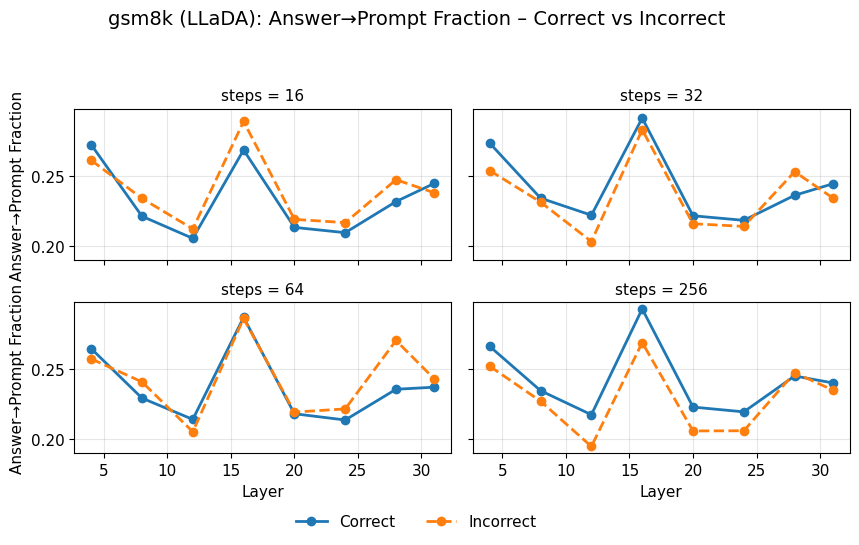

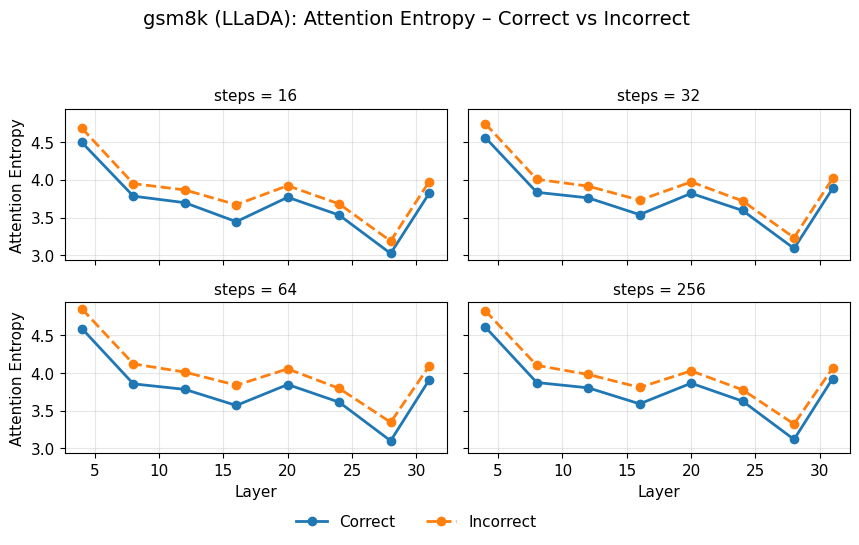

In [ ]:
plot_llada_gsm_metric_by_steps_clean(gsm_stats_by_steps, metric="frac_prompt",
                               dataset_name="gsm8k")
plot_llada_gsm_metric_by_steps_clean(gsm_stats_by_steps, metric="entropy",
                               dataset_name="gsm8k")

In [ ]:
# ===================== AIME2025 =====================
for steps in steps_list:
    print(f"\n================ AIME2025: steps = {steps}, gen_length = {gen_length} ================")
    stats_ci, correct_idxs, incorrect_idxs = run_llada_correct_vs_incorrect_on_dataset(
        mdl_llada,
        tok_llada,
        ds_aime,
        ds_name="aime2025",
        layers_to_probe=layers_to_probe,
        max_examples=30,
        gen_length=gen_length,
        steps=steps,
        block_length=block_length,
        device=device,
    )
    aime_stats_by_steps[steps]     = stats_ci
    aime_correct_by_steps[steps]   = correct_idxs
    aime_incorrect_by_steps[steps] = incorrect_idxs


================ AIME2025: steps = 16, gen_length = 256 ================


aime2025 correct vs incorrect:  13%|█▎        | 4/30 [00:05<00:37,  1.44s/it]


KeyboardInterrupt: 

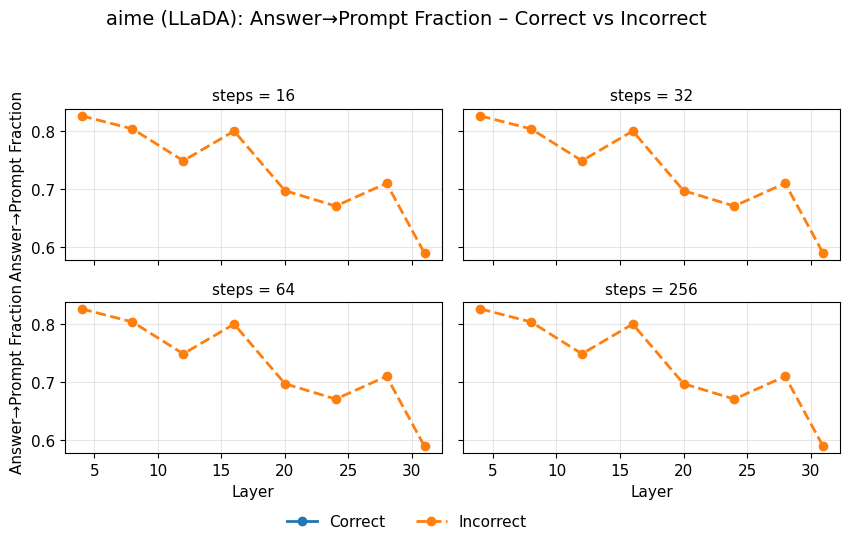

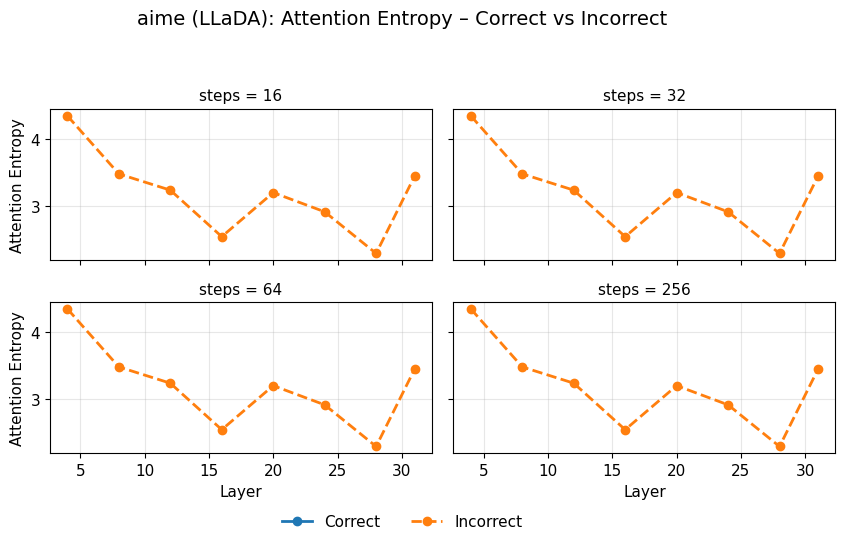

In [ ]:
plot_llada_gsm_metric_by_steps_clean(aime_stats_by_steps, metric="frac_prompt",
                               dataset_name="aime")
plot_llada_gsm_metric_by_steps_clean(aime_stats_by_steps, metric="entropy",
                               dataset_name="aime")

In [ ]:
steps_list      = [16, 32, 64, 256]
gen_length      = 256          # constant across all runs
block_length    = 32
layers_to_probe = [4, 8, 12, 16, 20, 24, 28, 31]

In [105]:
# ===================== GPQA extended =====================
for steps in steps_list:
    print(f"\n================ GPQA-extended: steps = {steps}, gen_length = {gen_length} ================")
    stats_ci, correct_idxs, incorrect_idxs = run_llada_correct_vs_incorrect_on_dataset(
        mdl_llada,
        tok_llada,
        ds_gpqa,
        ds_name="gpqa_extended",
        layers_to_probe=layers_to_probe,
        max_examples=10,        # or your chosen cap
        gen_length=gen_length,
        steps=steps,
        block_length=block_length,
        device=device,
    )
    gpqa_stats_by_steps[steps]     = stats_ci
    gpqa_correct_by_steps[steps]   = correct_idxs
    gpqa_incorrect_by_steps[steps] = incorrect_idxs


================ GPQA-extended: steps = 16, gen_length = 256 ================


gpqa_extended correct vs incorrect:   2%|▏         | 10/546 [00:11<09:56,  1.11s/it]



================ GPQA-extended: steps = 32, gen_length = 256 ================


gpqa_extended correct vs incorrect:   2%|▏         | 10/546 [00:18<16:15,  1.82s/it]



================ GPQA-extended: steps = 64, gen_length = 256 ================


gpqa_extended correct vs incorrect:   2%|▏         | 10/546 [00:32<29:10,  3.27s/it]



================ GPQA-extended: steps = 256, gen_length = 256 ================


gpqa_extended correct vs incorrect:   2%|▏         | 10/546 [01:59<1:46:37, 11.94s/it]


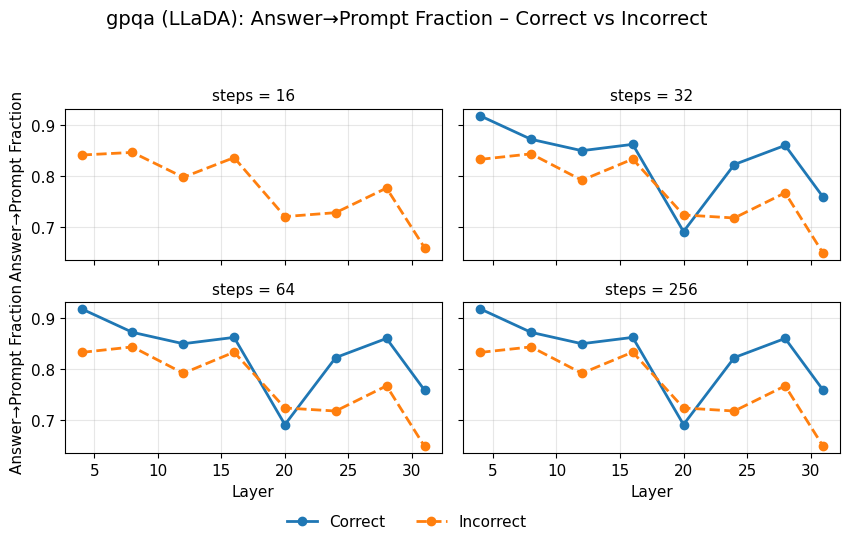

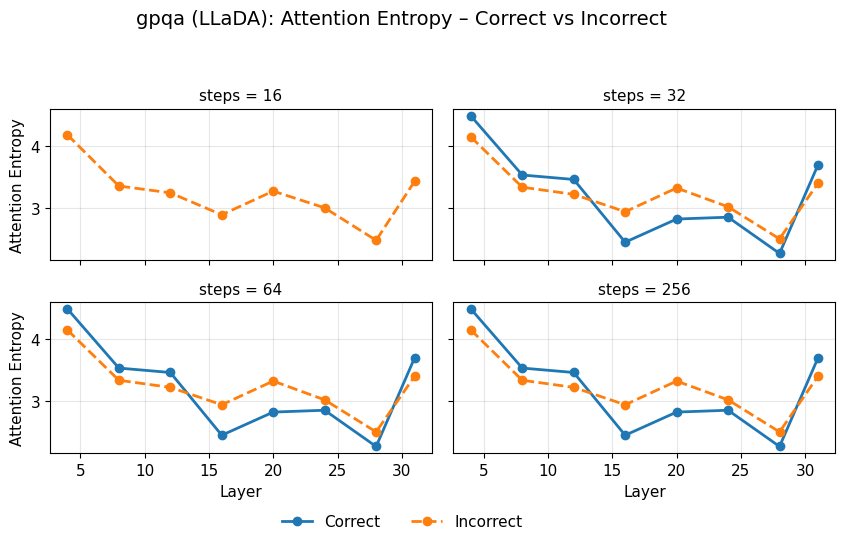

In [106]:
plot_llada_gsm_metric_by_steps_clean(gpqa_stats_by_steps, metric="frac_prompt",
                               dataset_name="gpqa")
plot_llada_gsm_metric_by_steps_clean(gpqa_stats_by_steps, metric="entropy",
                               dataset_name="gpqa")

### Correct vs. Incorrect Plots

In [ ]:
from collections import defaultdict
import numpy as np

# Containers
gsm_stats_by_steps   = defaultdict(lambda: defaultdict(list))
gsm_correct_by_steps = defaultdict(list)
gsm_incorrect_by_steps = defaultdict(list)

# inside your main evaluation loop
for ex in dataset:  # however you iterate
    steps      = ex["steps"]      # or whatever index you’re bucketing by
    quadrants  = ex["quadrants"]  # dict with "pp","pa","ap","aa": np.array[n_layers]
    entropy    = ex["entropy"]    # np.array[n_layers]
    is_correct = ex["is_correct"]

    # store all four quadrant flows and entropy
    for name in ["pp", "pa", "ap", "aa"]:
        gsm_stats_by_steps[steps][name].append(quadrants[name])

    gsm_stats_by_steps[steps]["entropy"].append(entropy)

    # track IDs by correctness if you need them
    if is_correct:
        gsm_correct_by_steps[steps].append(ex["id"])
    else:
        gsm_incorrect_by_steps[steps].append(ex["id"])


NameError: name 'dataset' is not defined